# Предсказание сердечных заболеваний

## Описание проекта

**О проекте.** Цель проекта — разработать демонстрационный, а в перспективе и полностью готовый к использованию модуль, который на основе клинических и демографических данных предсказывает вероятность сердечных заболеваний.

**Данный ноутбук** охватывает этапы анализа данных и построения модели. Используемый датасет: [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data).

**План этого этапа:**

- Изучение данных — анализ распределений, поиск пропусков и взаимосвязей между признаками;
- Подготовка данных — приведение их к виду, пригодному для обучения;
- Обучение модели — сравнение классических алгоритмов машинного обучения и эксперименты с нейронной сетью;
- Оценка качества — проверка точности предсказаний и надежности модели.

**Результат:** сохраненная обученная модель для последующей интеграции в итоговый функциональный модуль.

## Описание данных

- `Age`: возраст пациента [в годах]

- `Sex`: пол пациента [M: мужской, F: женский]

- `ChestPainType`: тип боли в грудной клетке  
  [TA: типичная стенокардия,  
  ATA: атипичная стенокардия,  
  NAP: боль несердечного происхождения,  
  ASY: бессимптомное течение]

- `RestingBP`: артериальное давление в состоянии покоя [мм рт. ст.]

- `Cholesterol`: уровень холестерина в крови [мг/дл]

- `FastingBS`: уровень глюкозы натощак  
  [1: > 120 мг/дл (повышенный), 0: нормальный]

- `RestingECG`: результаты ЭКГ в состоянии покоя  
  [Normal: норма,  
  ST: отклонения сегмента ST-T (ишемические изменения),  
  LVH: гипертрофия левого желудочка]

- `MaxHR`: максимальная частота сердечных сокращений [60–202]

- `ExerciseAngina`: стенокардия при физической нагрузке  
  [Y: да, N: нет]

- `Oldpeak`: депрессия сегмента ST после нагрузки [показатель ишемии]

- `ST_Slope`: наклон сегмента ST при пиковой нагрузке  
  [Up: восходящий (норма),  
  Flat: горизонтальный (подозрение на ишемию),  
  Down: нисходящий (высокий риск)]

- `HeartDisease`: наличие заболеваний сердца (целевая переменная)  
  [1: есть, 0: нет]


**Примечание:** Есть различия в единицах измерения в РФ, так например в уровень холестерина и глюкозы измеряются в миллимолях на литр, а не мг/дл, что нужно будет учесть при разработке приложения.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib
import shap
import os

D:\projects\portfolio\yandex-practicum-projects\heart-disease-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
RANDOM_STATE = 130601

In [4]:
pd.options.display.float_format = '{:.2f}'.format

## Подготовка функций

In [5]:
def plot_numerical(df, columns):
    """
    Функция рисует гистограммы для переданных числовых признаков друг под другом.

    Параметры:
        df: DataFrame с данными
        columns: список названий столбцов(например, ['a', 'b']
    """

    if len(columns) == 0:
        print('Список столбцов пуст')
        return
        
    plt.figure(figsize=(12, 4 * len(columns)))

    for i, col in enumerate(columns):

        plt.subplot(len(columns), 1, i+1)

        sns.histplot(df[col], kde=True, color=sns.color_palette('husl')[0], edgecolor='black')

        mean_val = df[col].mean()
        median_val = df[col].median()

        plt.axvline(mean_val, color='red', linestyle='--', label=f'Среднее: {mean_val:.2f}')

        plt.axvline(median_val, color='green', linestyle='-', label=f'Медиана: {median_val:.2f}')
        
        plt.title(f'Распределение признака {col}', fontsize=14)

        plt.xlabel(col, fontsize=12)

        plt.ylabel('Количество наблюдений', fontsize=12)

        plt.legend(loc='upper right')
                  
    plt.tight_layout()

    plt.show()

In [6]:
def plot_categorical(df, columns):
    """
    Функция рисует столбчатую и круговую диаграммы для каждого из переданных категориальных признаков. 
    Диаграммы относящиеся к одному и тому же признаку находятся рядом друг с другом

    Параметры:
        df: DataFrame с данными
        columns: список названий столбцов(например, ['a', 'b']
    """
    
    if len(columns) == 0:
        print('Список столбцов пуст')
        return

    num_features = len(columns)

    fig, axes = plt.subplots(num_features, 2, figsize=(12, 5*num_features))

    if num_features == 1:
        axes = [axes]
    
    for i, col in enumerate(columns):

        counts = df[col].value_counts()

        num_categories = len(counts)

        current_palette = sns.color_palette('husl', num_categories)

        axes[i][0].pie(
            counts.values,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=current_palette,
            wedgeprops={'edgecolor': 'black'}
        )
        axes[i][0].set_title(f'{col} - Доли категорий', fontsize=14)

        sns.barplot(
            x=counts.index,
            y=counts.values,
            ax=axes[i][1],
            palette=current_palette,
            edgecolor='black'
        )
        axes[i][1].set_title(f'{col} - Количество наблюдений', fontsize=14)

        for container in axes[i][1].containers:
            axes[i][1].bar_label(container)

    plt.tight_layout()
    plt.show()

In [7]:
def analyze_numerical_pair(df, col_x, col_y):
    """
    Функция анализирует взаимосвязь между двумя числовыми признаками

    Параметры:
        df: DataFrame с данными
        col_x: название первого столбца
        col_y: название второго столбца
    """

    corr, p_value = stats.pearsonr(df[col_x], df[col_y])

    plt.figure(figsize=(12,6))

    sns.regplot(
        x=col_x,
        y=col_y,
        data=df,
        scatter_kws={'alpha':0.5, 'color': sns.color_palette('husl')[0], 'edgecolor':'black'},
        line_kws={'color':'pink', 'linewidth':2}
    )

    title_text = f'Связь: {col_x} и {col_y}\nPearson r: {corr:.3f} | p-value: {p_value:.4f}'
    if p_value < 0.0001:
        title_text = f'Связь: {col_x} и {col_y}\nPearson r: {corr:.3f} | p-value: < 0.0001'
    plt.title(title_text, fontsize=14)
    plt.xlabel(col_x, fontsize=12)
    plt.ylabel(col_y, fontsize=12)
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [8]:
def analyze_categorical_pair(df, col_1, col_2):
    '''
    Функция анализирует взаимосвязь между двумя числовыми признаками

    Параметры:
        df: DataFrame с данными
        col_1: название столбца, который будет записан в строки
        col_2: название столбца, который будет записан в столбцы
    '''
    contingency_table = pd.crosstab(df[col_1], df[col_2])
    contingency_table_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    n_colors = len(df[col_2].unique())
    current_palette = sns.color_palette('husl', n_colors)

    plt.figure(figsize=(10, 6))
    
    ax = contingency_table_pct.plot(kind='bar', stacked=True, color=current_palette)

    for p in ax.patches:
        height = p.get_height()
        if height > 5:
            ax.text(
                p.get_x() + p.get_width() / 2,
                p.get_y() + height / 2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=8, 
                color='white'
            )

    title_text = f"Связь: {col_1} и {col_2}\n Chi-Square Stat: {chi2:.4f} | p-value: {p_value:.4f}"
    if p_value < 0.0001:
        title_text = f"Связь: {col_1} vs {col_2}\nChi-Square Stat: {chi2:.4f} | p-value: < 0.0001"

    plt.title(title_text, fontsize=14)
    plt.xlabel(col_1, fontsize=12)
    plt.ylabel('Доля', fontsize=12)
    ax.legend(title=col_2, bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(axis='y', linestyle='-', alpha=0.3)

    plt.tight_layout()
    plt.show()
    return #contingency_table, p_value

In [9]:
def analyze_num_cat(df, num_col, cat_col):
    """
    Анализирует связь числового и категориального признаков.

    Параметры:
        df: DataFrame с данными
        num_col: название столбца с численными данными
        cat_col: название столбца с категориальными данными
    """
    data = df[[num_col, cat_col]].dropna()
    
    categories = data[cat_col].unique()
    n_cats = len(categories)
    
    if n_cats == 2:
        group1 = data[data[cat_col] == categories[0]][num_col]
        group2 = data[data[cat_col] == categories[1]][num_col]
        stat, p_value = stats.ttest_ind(group1, group2)
        test_name = "T-test"
    else:
        groups = [data[data[cat_col] == cat][num_col] for cat in categories]
        stat, p_value = stats.f_oneway(*groups)
        test_name = "ANOVA"

    plt.figure(figsize=(10, 6))
    
    palette = sns.color_palette('husl', n_cats)
    sns.boxplot(x=cat_col, y=num_col, data=data, palette=palette, linewidth=1.5)
    
    sns.stripplot(x=cat_col, y=num_col, data=data, color='black', alpha=0.3, size=4)

    title_text = f"{num_col} by {cat_col}\n{test_name} p-value: {p_value:.4f}"
    plt.title(title_text, fontsize=14, fontweight='bold')
    plt.xlabel(cat_col, fontsize=12)
    plt.ylabel(num_col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Анализ: {num_col} vs {cat_col}")
    print(f"• Тест: {test_name}")
    print(f"• P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Значимые различия между группами!")
    else:
        print("Различий не обнаружено.")


In [10]:
def analyze_num_num_by_cat(df, num_x, num_y, cat_col):
    """
    Смотрит на связь двух численных признаков с разбивкой по категории.
    """
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        x=num_x, y=num_y, hue=cat_col, data=df,
        palette='husl', alpha=0.7, s=80, edgecolor='black'
    )
    
    plt.title(f"Связь {num_x} и {num_y} по группам {cat_col}", fontsize=14, fontweight='bold')
    plt.xlabel(num_x, fontsize=12)
    plt.ylabel(num_y, fontsize=12)
    plt.legend(title=cat_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Первичное ознакомление с данными

In [11]:
try:
    df = pd.read_csv('heart.csv')
except:
    print('Попробуйте поменять название файла')

In [12]:
df.sample(5, random_state=RANDOM_STATE)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
251,48,M,ASY,120,260,0,Normal,115,N,2.00,Flat,1
860,60,M,ASY,130,253,0,Normal,144,Y,1.40,Up,1
611,62,M,TA,135,139,0,ST,137,N,0.20,Up,0
62,45,M,ASY,140,224,0,Normal,144,N,0.00,Up,0
529,72,M,ASY,143,211,0,Normal,109,Y,1.40,Flat,1


Данные выглядят, как хорошо подготовленный датасет, изначально не видно каких-то мусорных значений.

In [13]:
df.shape

(918, 12)

У нас есть 918 наблюдений

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


Явных пропусков нет, типы данных корректны

In [15]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,0.23,136.81,0.89,0.55
std,9.43,18.51,109.38,0.42,25.46,1.07,0.50
min,28.00,0.00,0.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,173.25,0.00,120.00,0.00,0.00
50%,54.00,130.00,223.00,0.00,138.00,0.60,1.00
75%,60.00,140.00,267.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


Здесь проявляются неявные пропуски в значениях `Cholesterol`(холестирин) и `RestingBP`(давление в покое). В показателях `Cholesterol` также могут быть выбросы, судя по максимальному значению. По медиане целевого признака, можно увидеть, что классы почти идеально сбалансированы с небольшим преобладанием в данных наблюдений с наличием сердечного заболевания.

In [16]:
for col in df.select_dtypes(include='str'):
    print()
    print(df[col].value_counts())
    print('===' * 50)


Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


### Вывод по первичному ознакомлению
- Есть неявные пропуски в столбцах `Cholesterol` и `RestingBP`.
- Возможны выбросы в `Cholesterol`.
- Дисбаланс классов в целевой переменной пренебрежимо слабый.

## Предобработка данных

### Проверка дубликатов

In [17]:
df.duplicated().sum()

np.int64(0)

В данных нет явных дубликатов.

### Проверка типов данных

In [18]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

Все типы данных подобраны верно

### Проверка аномалий

In [19]:
df[df['Cholesterol'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.00,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.70,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.50,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.70,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.40,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,0,0,Normal,120,N,0.50,Up,1
515,63,M,NAP,130,0,1,ST,160,N,3.00,Flat,0
518,48,M,NAP,102,0,1,ST,110,Y,1.00,Down,1
535,56,M,ASY,130,0,0,LVH,122,Y,1.00,Flat,1


Такое количество пропусков явно указывает на пропуски в данных. Попробуем узнать, чем заполнить эти пропуски.

<Axes: >

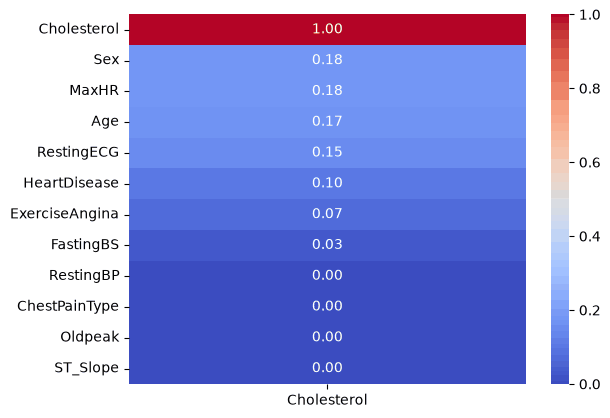

In [20]:
phik_matrix_Cholestrol = df[df['Cholesterol'] != 0].phik_matrix(interval_cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])

sns.heatmap(phik_matrix_Cholestrol[['Cholesterol']].sort_values(by='Cholesterol', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')

У холестерина нет сильных корреляций, лучшим решением будет заполнить пропуски медианным значением.

In [21]:
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan).fillna(df['Cholesterol'].median())

<Axes: >

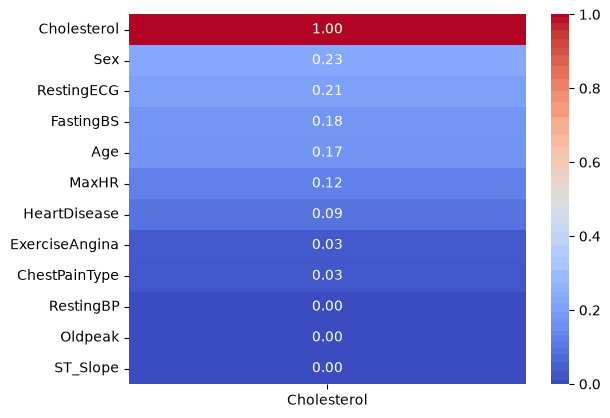

In [22]:
phik_matrix_Cholestrol = df[df['Cholesterol'] != 0].phik_matrix(interval_cols=['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])

sns.heatmap(phik_matrix_Cholestrol[['Cholesterol']].sort_values(by='Cholesterol', ascending=False), annot=True, cmap='coolwarm', fmt='.2f')

Видим, что никаких значимых изменений после нашего вмешательство не случилось.

In [23]:
df[df['RestingBP'] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,223.00,0,Normal,155,N,1.50,Flat,1


Всего одно значение оно вряд-ли сильно повлияет на исследование, заполним его медианным значением по полу.

In [24]:
df['RestingBP'] = df['RestingBP'].replace(0, np.nan).fillna(df.loc[df['Sex'] == 'M', 'RestingBP'].median())

## Исследовательский анализ данных

### Исследование признаков

#### Числовые признаки: `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`

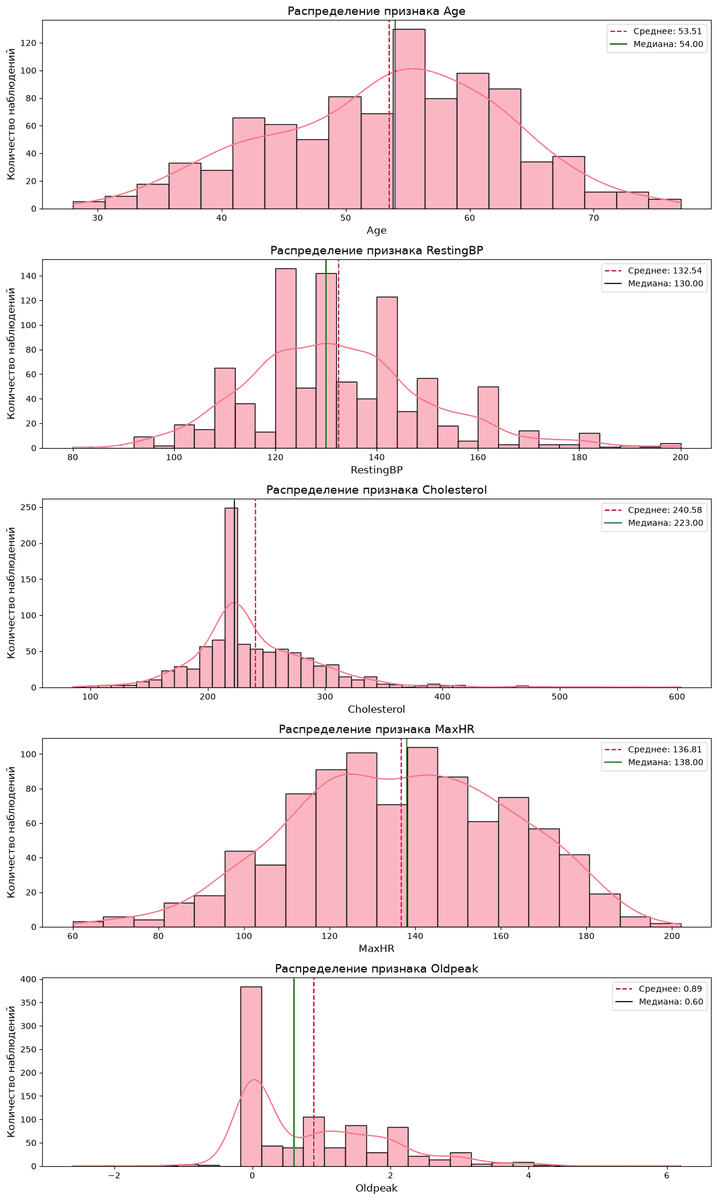

In [25]:
plot_numerical(df, ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'])

1. `Age` График имеет наибольшее количество наблюдений в районе 55 лет, справа от этого значения больше наблюдений в небольшом фрагменте до ~75 лет, а вот слева наблюдений по возрастам меньше, но хвост уходит дальше до ~30 лет.
2. `RestingBP` График имеет небольшой перекос вправо, также видно несколько пиков.
3. `Cholesterol` Здесь видно смещенное вправо распределение с несколькими аномально большими значениями, большой пик связан с тем, что мы заполнили пропуски медианным значением, здесь как раз и видна проблемность этого решения.
4. `MaxHR` График показывает почти нормальное распределение с двумя пиками, которые могут быть связаны с нормальными половозрастными показателями пульса.
5. `Oldpeak` Депрессия сегмента ST после нагрузки имеет выраженный пик на нуле, он и является нормальным значением, признаком отсутствия ишемии. Мы видим некоторые отрицательные значения, которые могут от своей малой представленности среди наблюдений показаться аномальными, но это реальные значения, которые иногда возникают при проведении ЭКГ под нагрузкой.

#### Категориальные признаки: `Sex`, `ChestPainType`, `FastingBS`, `RestingECG`, `ExerciseAngina`, `ST_Slope`

Можно заметить некоторые указания на то, что ST_Slope является порядковым признаком, например, что `Flat` хуже чем `UP` и лучше чем `Down`, однако утверждать это, без хорошего понимания медицинских показателей или консультации с медицинским специалистом нельзя. 

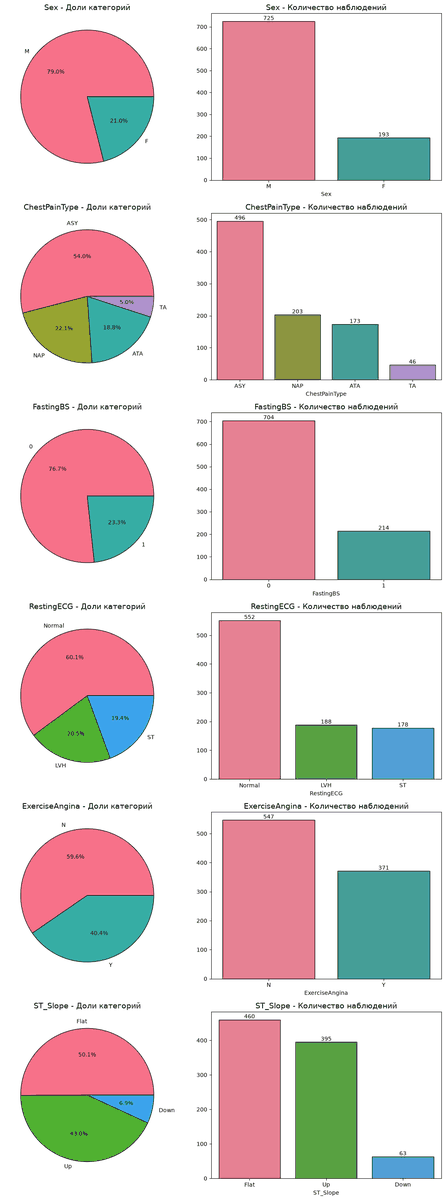

In [26]:
plot_categorical(df, ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])

1. `Sex` Сильно больше наблюдений по мужчинам.
2. `ChestPainType`
    - TA: типичная стенокардия. Боль возникает за грудиной, часто давящая или сжимающая.
    - ATA: атипичная стенокардия. Боль, похожая на типичную, но не соответствующая по всем критериям.
    - NAP: боль несердечного происхождения. Боль в области груди, которая не связана с сердцем.
    - ASY: бессимптомное течение. **Пациент не жалуется на боль в груди.** Является самой многочисленной категорией. Коварный признак, который может в данном датасете приводить к неправильной трактовке, одновременно является, как признаком болезни, так и признаком отсутствия каких-либо заболеваний, в датасете, может быть перекос по этому признаку в сторону пациентов без боли, но с заболеванием и тогда значимость этого признака может быть переоценена.

4. `FastingBS` Большая часть наблюдений с нормальным уровнем глюкозы.
5. `RestingECG` Немного больше наблюдений с нормальным ЭКГ, и поровну наблюдений указывающими на ишемические изменения и наблюдений указывающих на гипертрофию левого желудочка.
6. `ExerciseAngina` 60% наблюдений без стенокардии во время нагрузки.
7. `ST_Slope` Половина наблюдений указывают на подозрения на ишемию, а также около 7 процентов на крайне высокий риск ишемии, остальные наблюдения имеют нормальный показатель(здоровое сердце).

#### Целевой признак

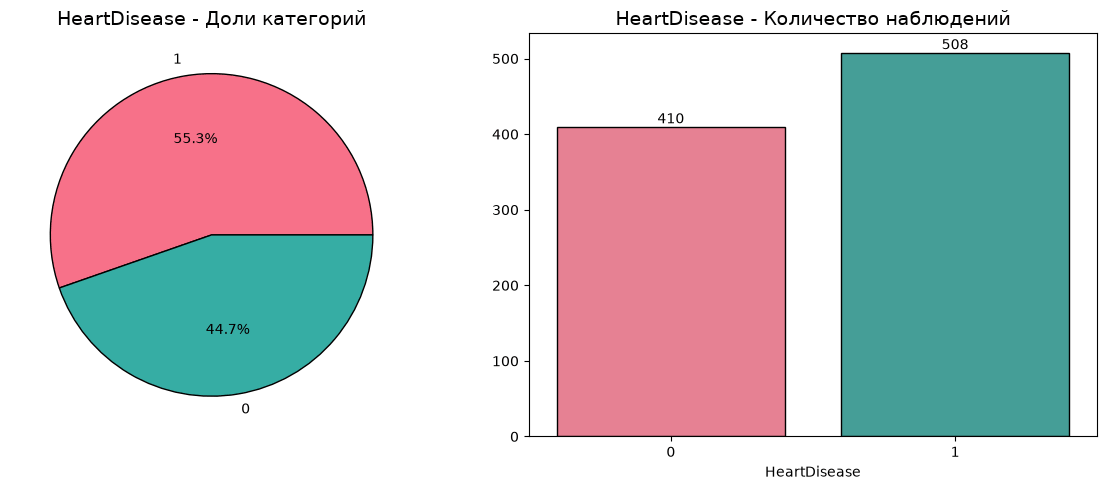

In [27]:
plot_categorical(df, ['HeartDisease'])

Как было указано ранее присутствует небольшой дисбаланс классов в целевом признаке в сторону пациентов с подтвержденными болезнями сердца.

### Взаимосвязи между признаками

#### Взаимосвязи между численными признаками

In [28]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

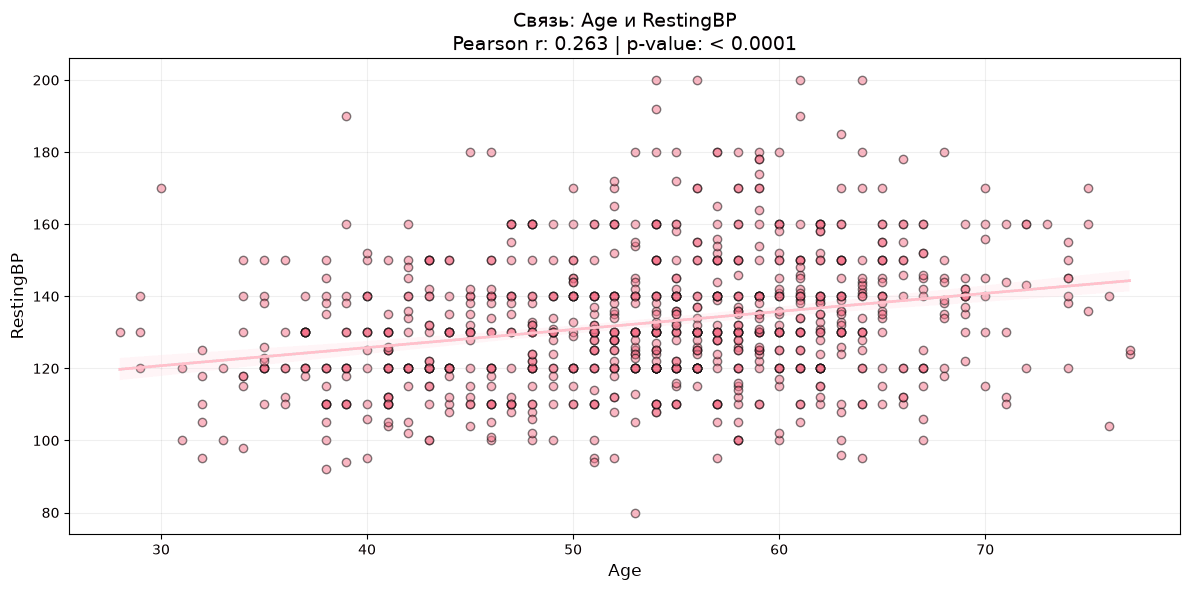

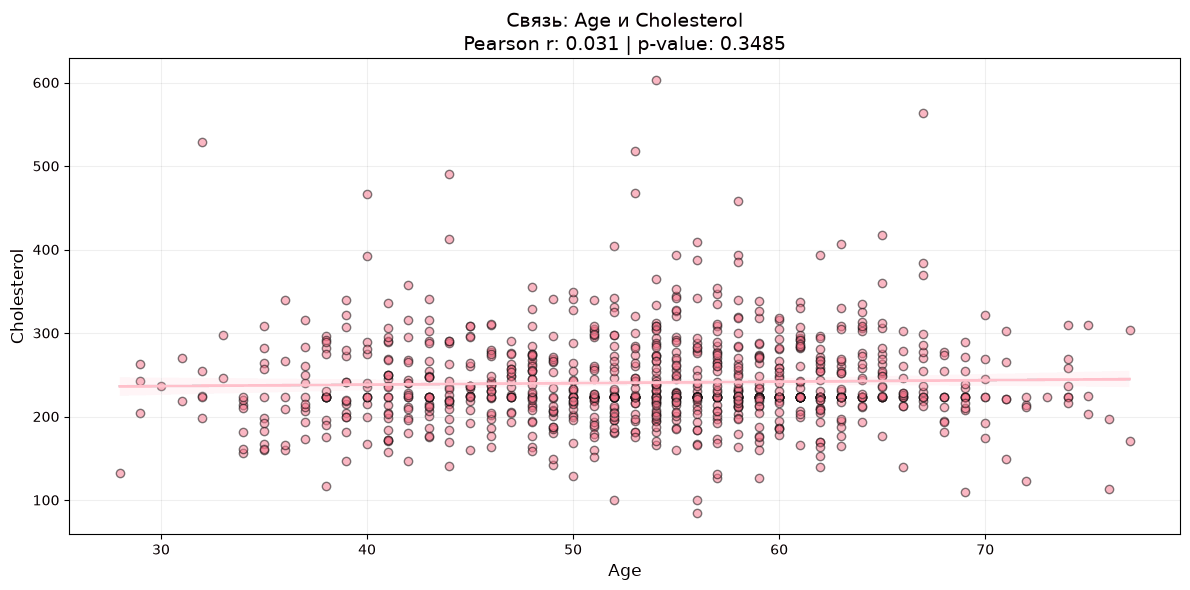

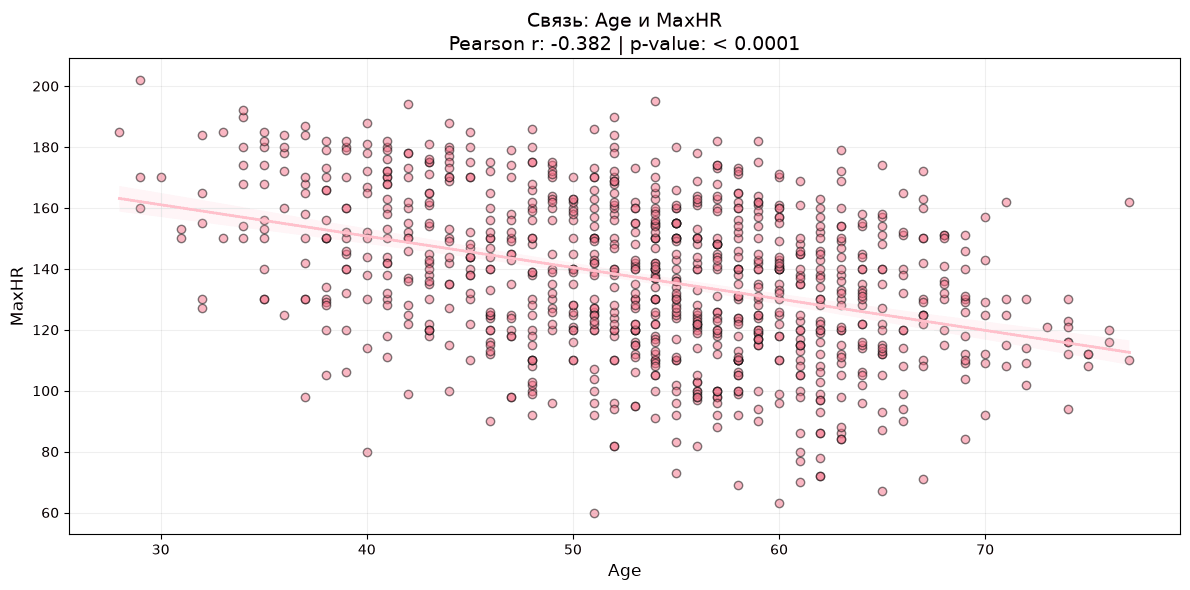

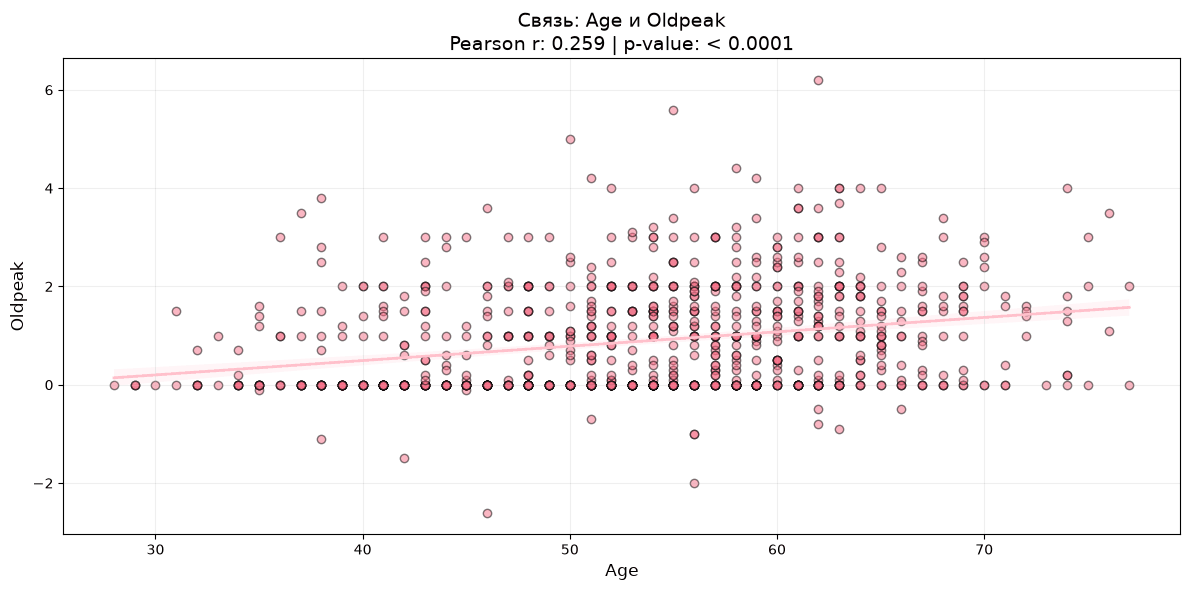

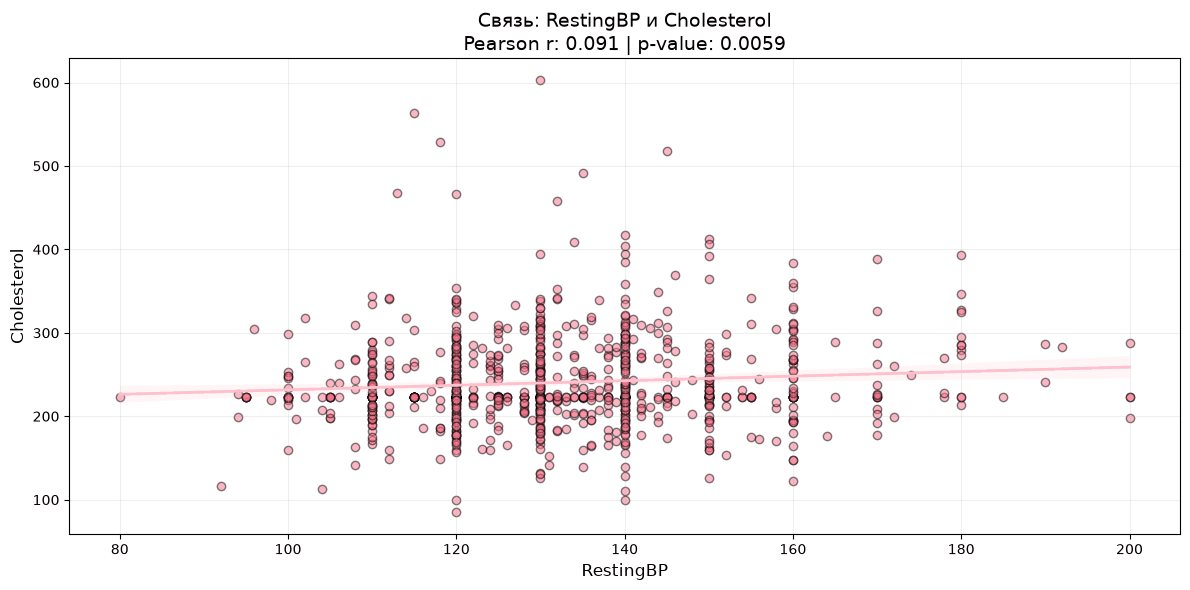

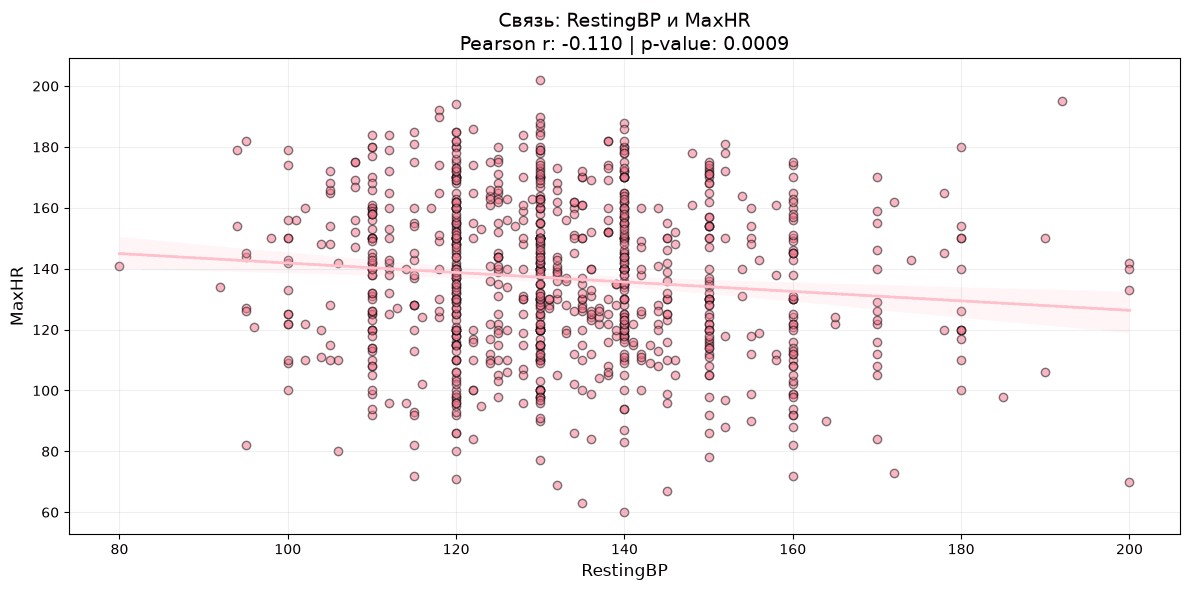

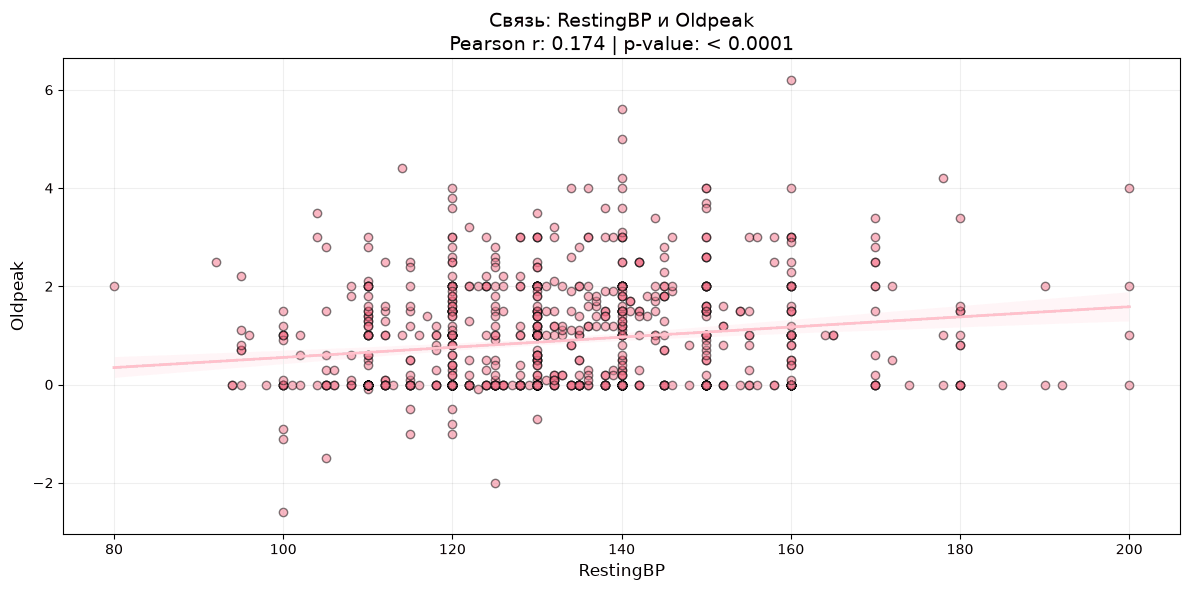

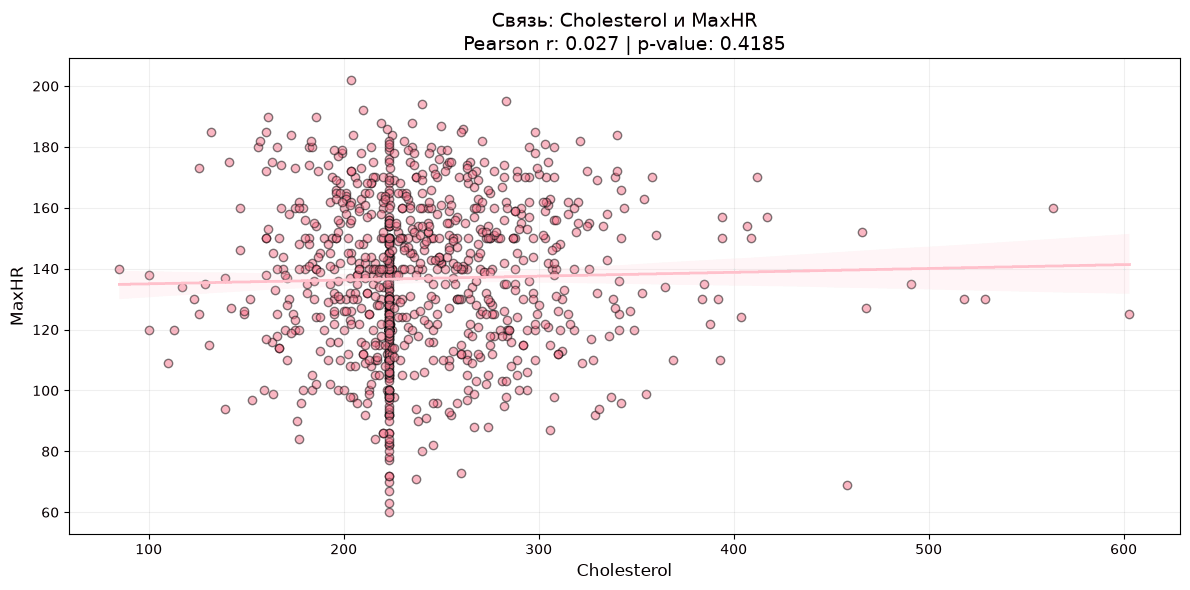

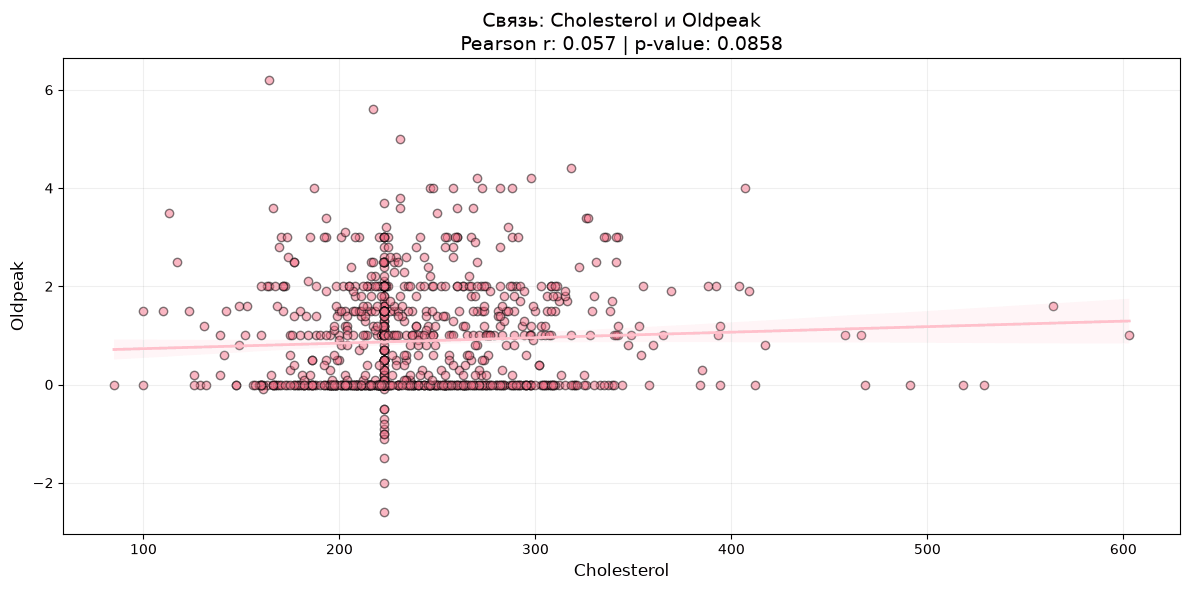

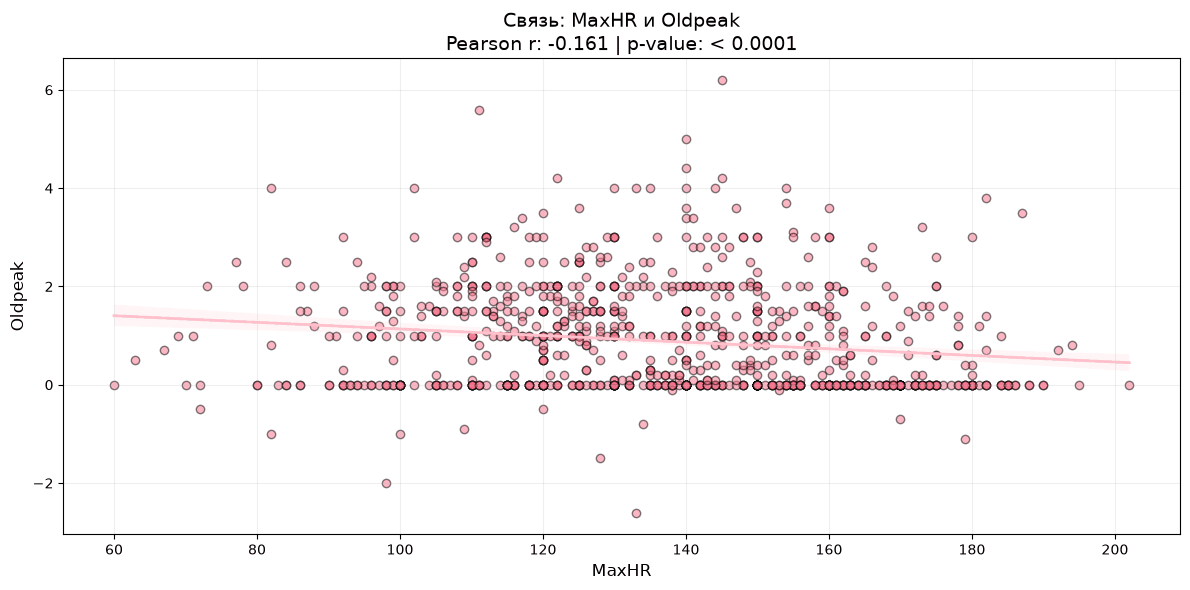

In [29]:
for i in range(len(numerical_cols)):
    col_x = numerical_cols[i]
    for j in range(i+1, len(numerical_cols)):
        col_y = numerical_cols[j]
        analyze_numerical_pair(df, col_x, col_y)

- `Связь: Age и RestingBP` Мы видим слабую положительную связь между признаками, что соответствует и медицинскому пониманию этих показателей.
- `Связь: Age и Cholesterol` Связи между признаками нет.
- `Связь: Age и MaxHR` Мы видим умеренную отрицательную свзяь между признаками.
- `Связь: Age и Oldpeak` Между признаками есть слабая положительная зависимости.

   Связи с возрастом показывают высокую значимость этого признака в данных.
- `Связь: RestingBP и Cholesterol` Связь между признаками почти нет.
- `Связь: RestingBP и MaxHR` Связь между признаками слабая отрицательная.
- `Связь: RestingBP и Oldpeak`Между признаками наблюдается слабая положительная связь.

    По графикам `RestingBP` мы видим, что данные скорее окргулены и поэтому большая часть наблюдений в значениях по типу 120, 130, 140.
- `Связь: Cholesterol и MaxHR` Связи между признаками нет, на графике хорошо видная медиана, которой мы заполнили `Cholesterol`.
- `Связь: Cholesterol и Oldpeak` Связи между признаками нет.
- `Связь: MaxHR и Oldpeak` Между признаками есть слабая отрицательная связь.

#### Взаимосвязи между категориальными признаками

In [30]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

<Figure size 1000x600 with 0 Axes>

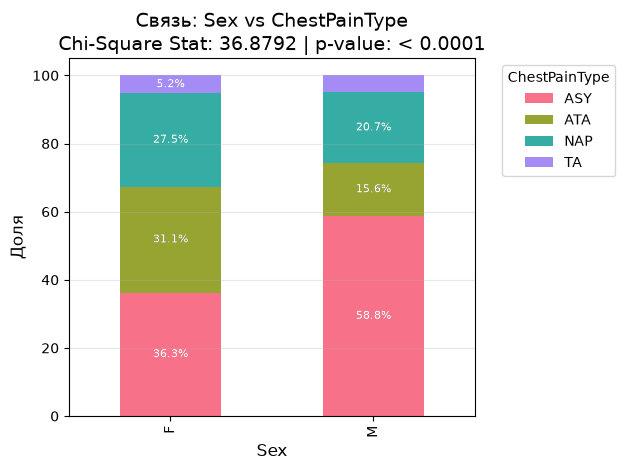

<Figure size 1000x600 with 0 Axes>

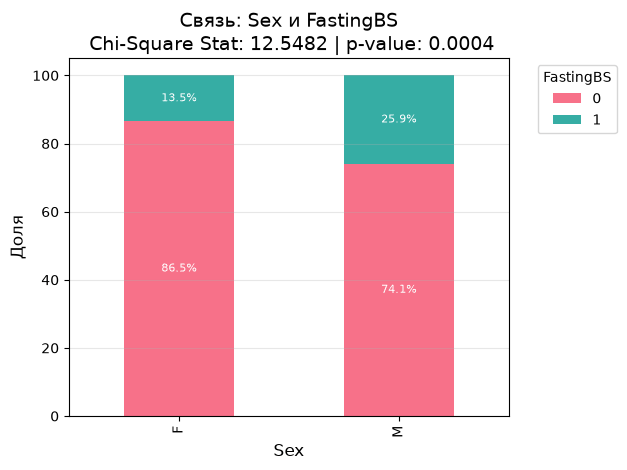

<Figure size 1000x600 with 0 Axes>

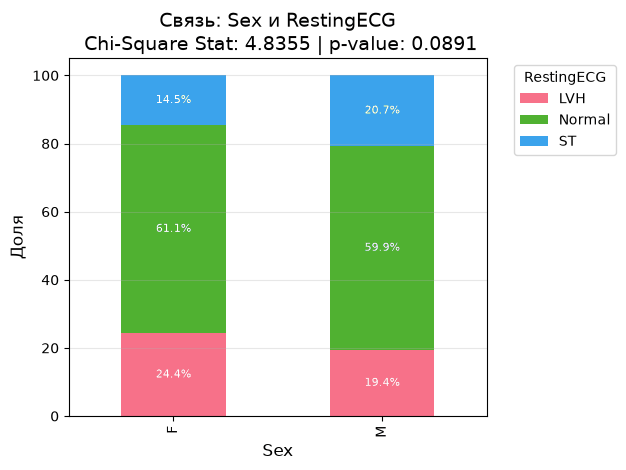

<Figure size 1000x600 with 0 Axes>

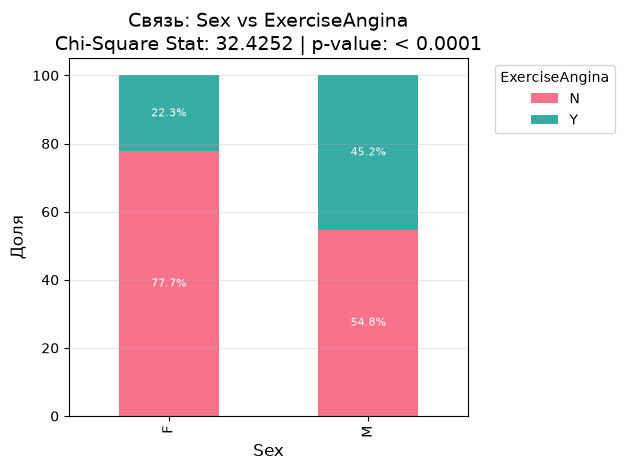

<Figure size 1000x600 with 0 Axes>

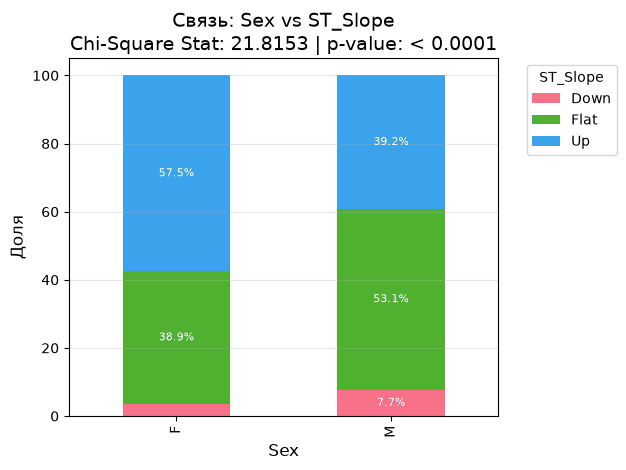

<Figure size 1000x600 with 0 Axes>

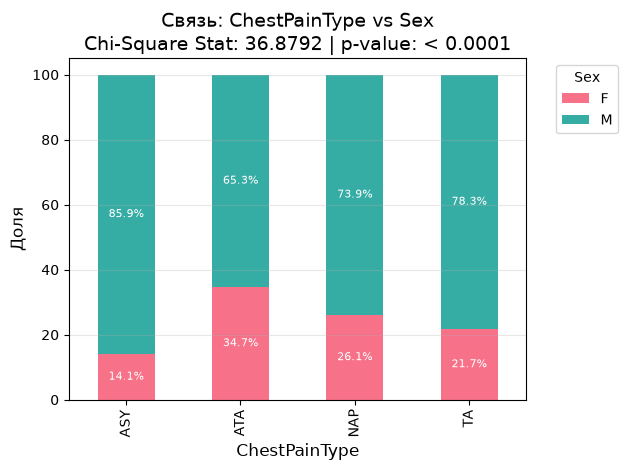

<Figure size 1000x600 with 0 Axes>

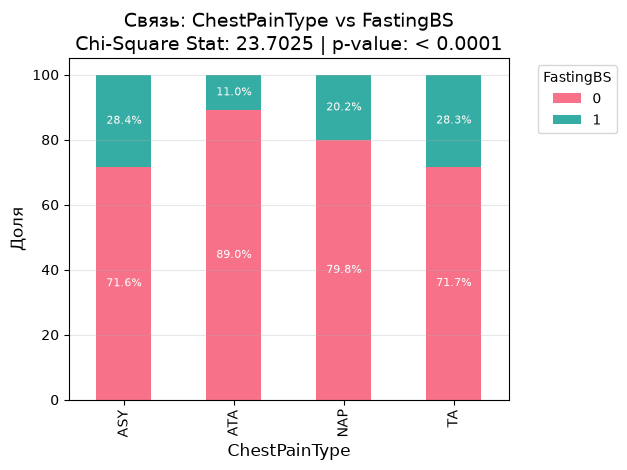

<Figure size 1000x600 with 0 Axes>

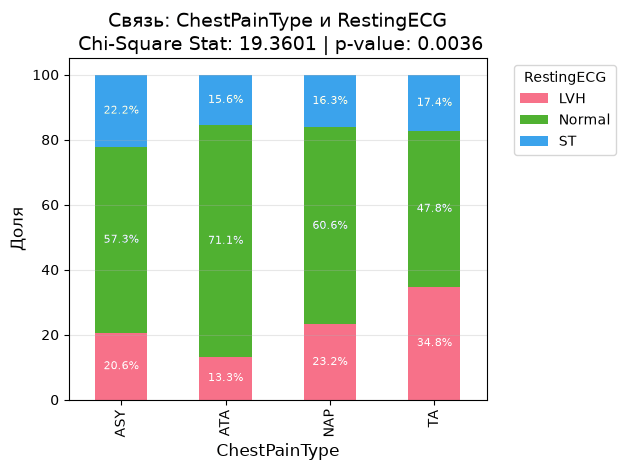

<Figure size 1000x600 with 0 Axes>

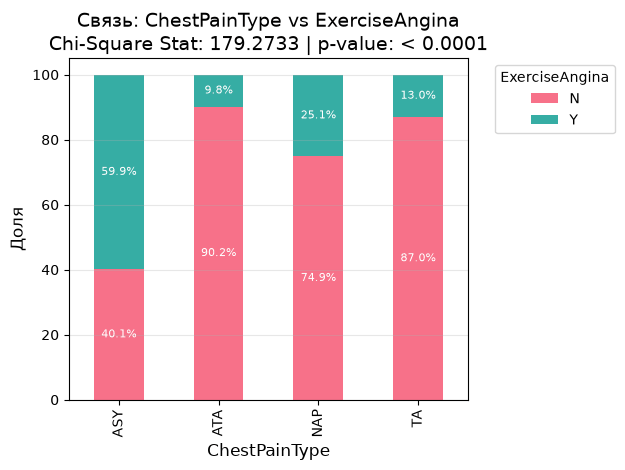

<Figure size 1000x600 with 0 Axes>

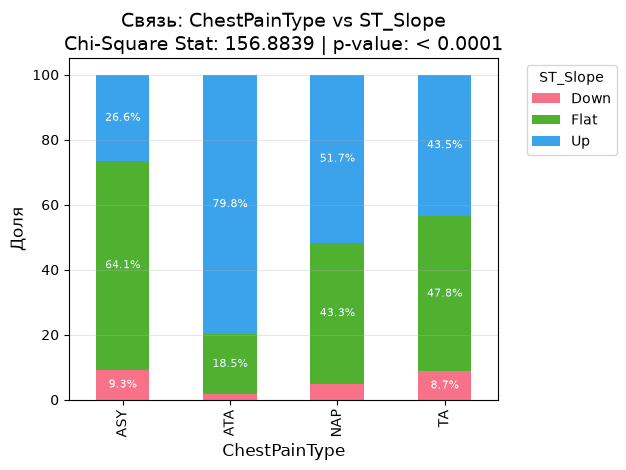

<Figure size 1000x600 with 0 Axes>

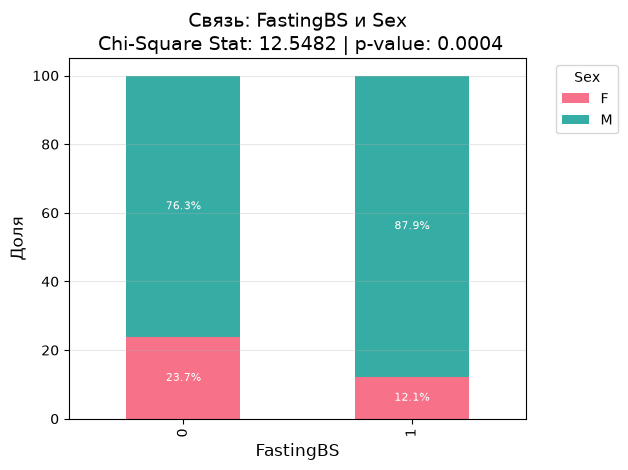

<Figure size 1000x600 with 0 Axes>

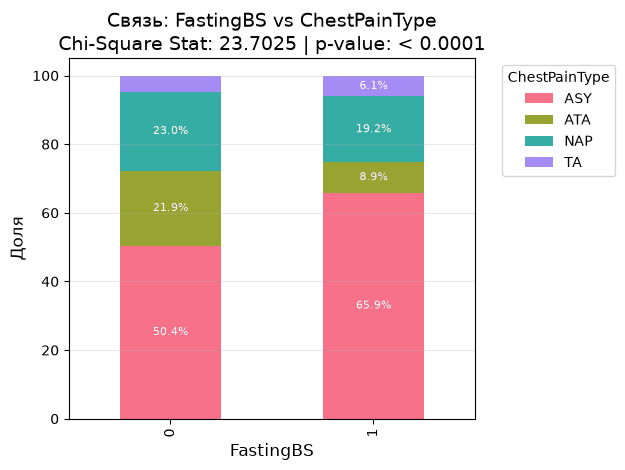

<Figure size 1000x600 with 0 Axes>

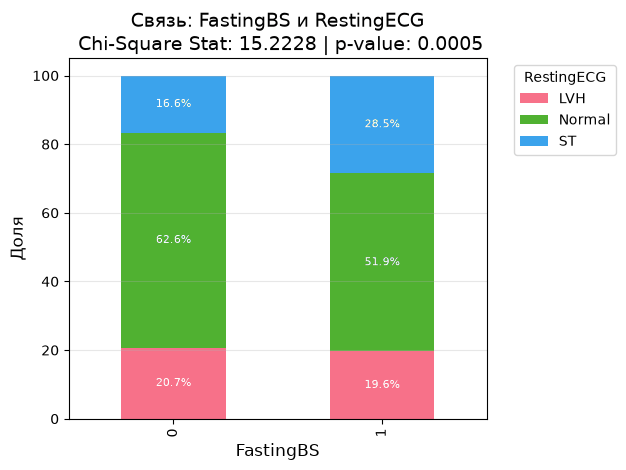

<Figure size 1000x600 with 0 Axes>

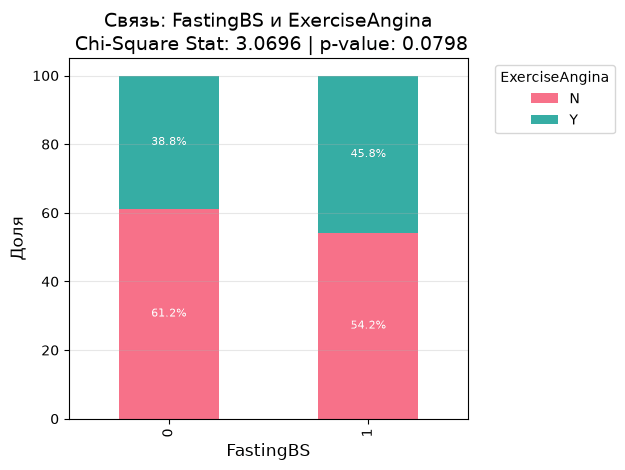

<Figure size 1000x600 with 0 Axes>

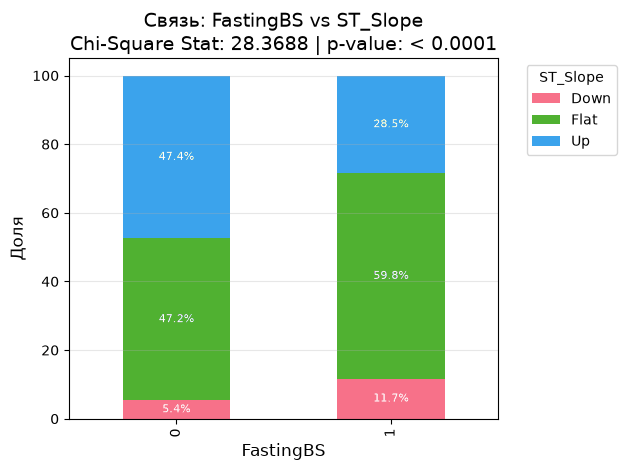

<Figure size 1000x600 with 0 Axes>

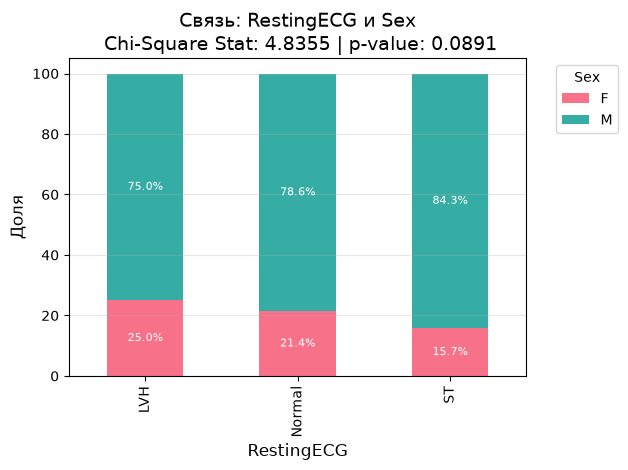

<Figure size 1000x600 with 0 Axes>

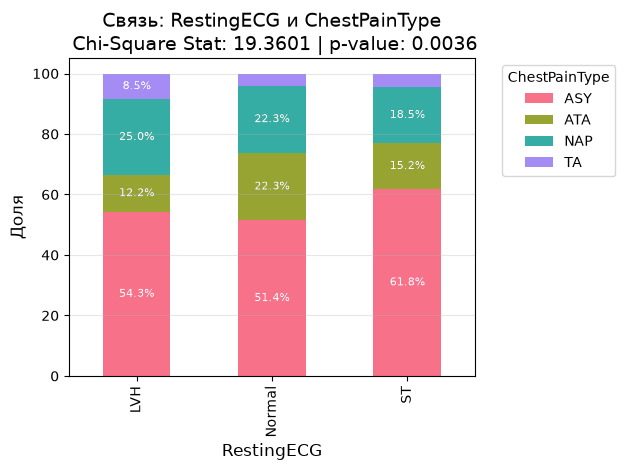

<Figure size 1000x600 with 0 Axes>

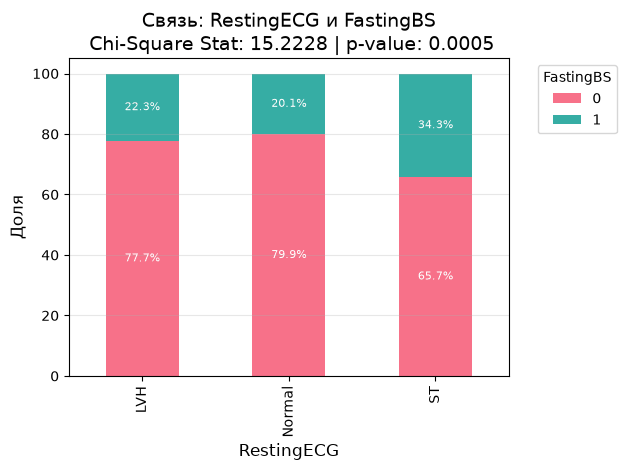

<Figure size 1000x600 with 0 Axes>

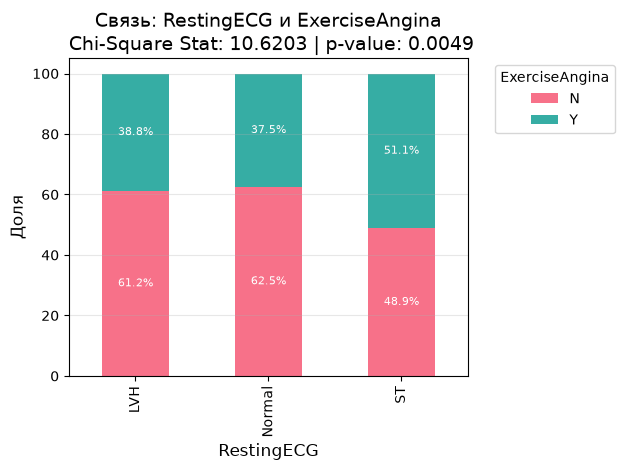

<Figure size 1000x600 with 0 Axes>

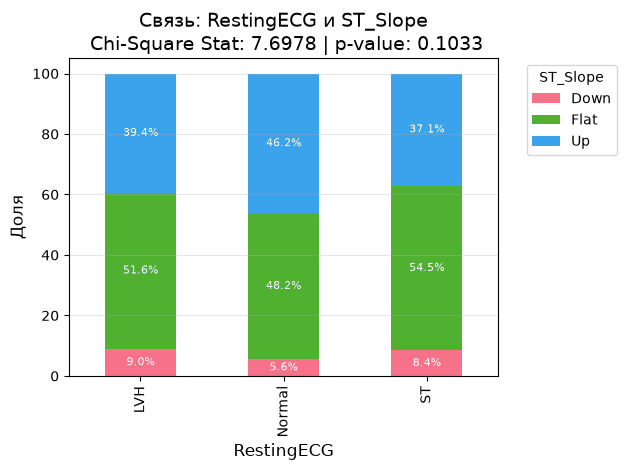

<Figure size 1000x600 with 0 Axes>

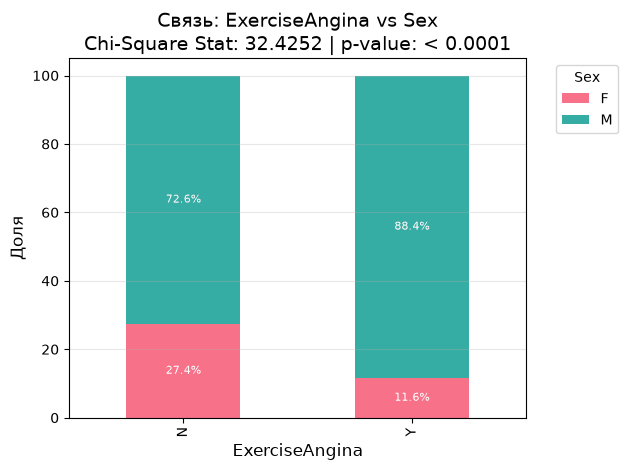

<Figure size 1000x600 with 0 Axes>

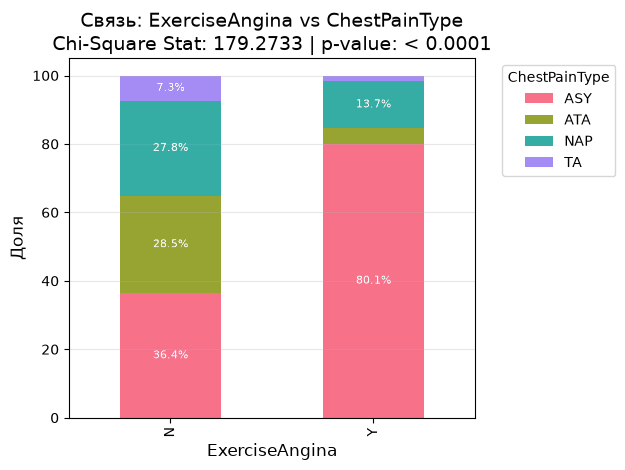

<Figure size 1000x600 with 0 Axes>

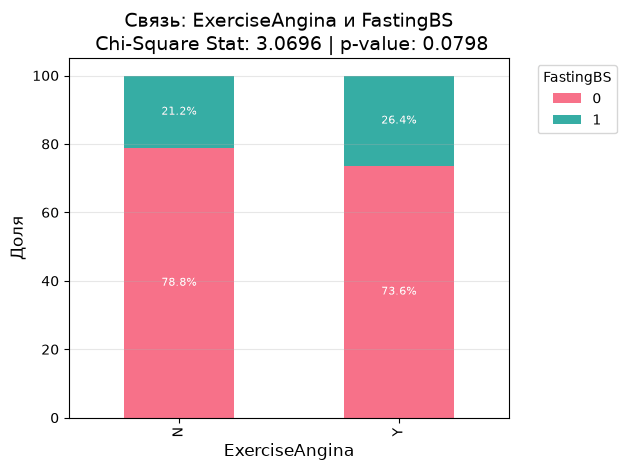

<Figure size 1000x600 with 0 Axes>

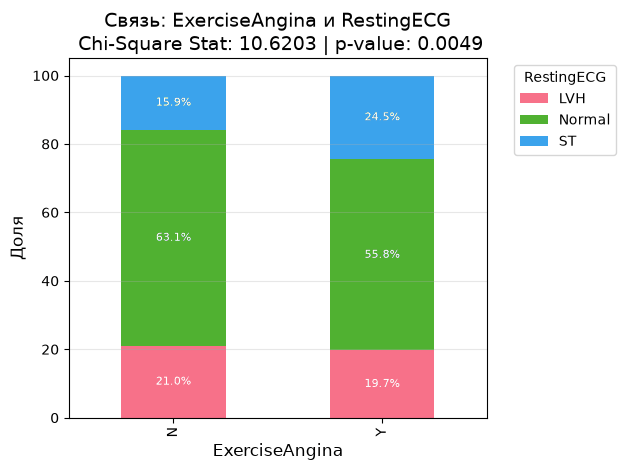

<Figure size 1000x600 with 0 Axes>

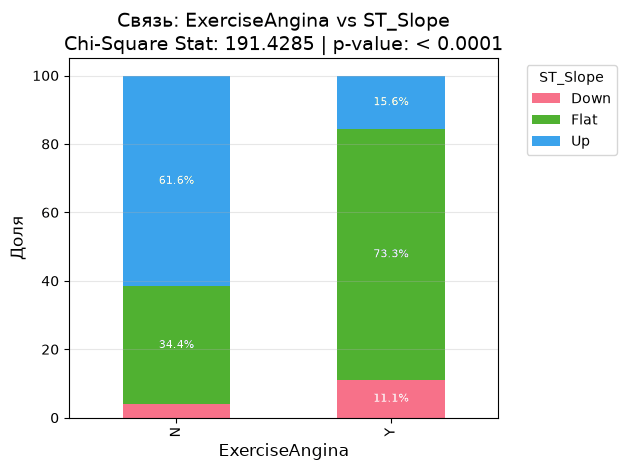

<Figure size 1000x600 with 0 Axes>

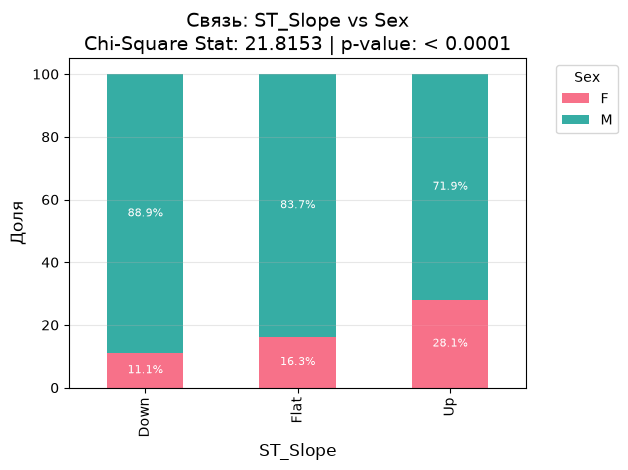

<Figure size 1000x600 with 0 Axes>

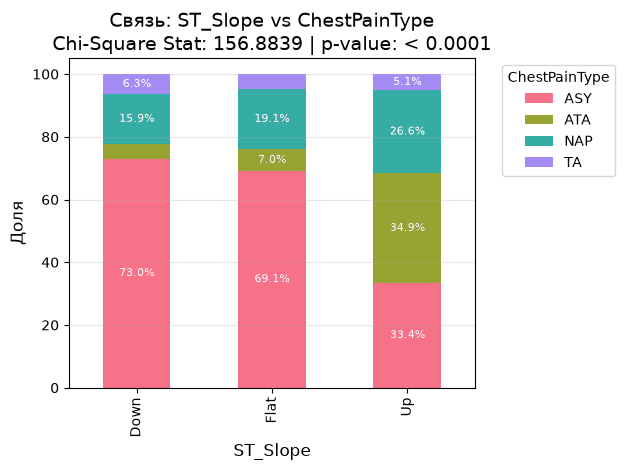

<Figure size 1000x600 with 0 Axes>

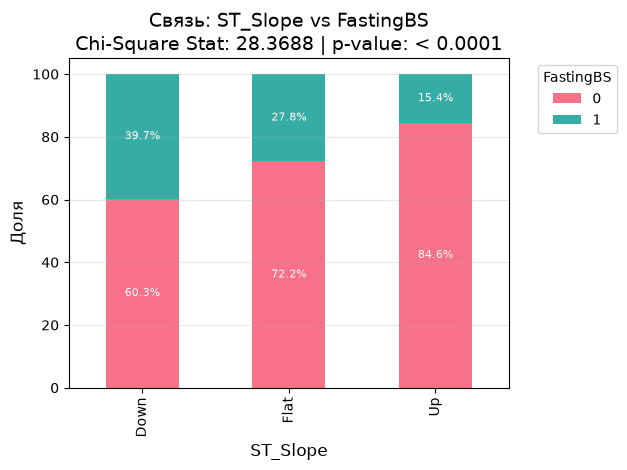

<Figure size 1000x600 with 0 Axes>

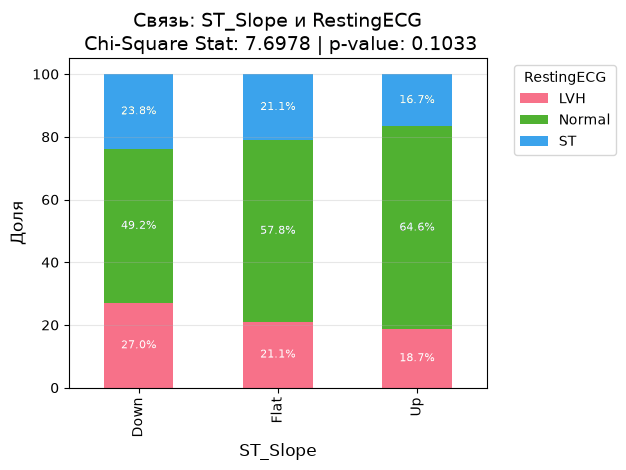

<Figure size 1000x600 with 0 Axes>

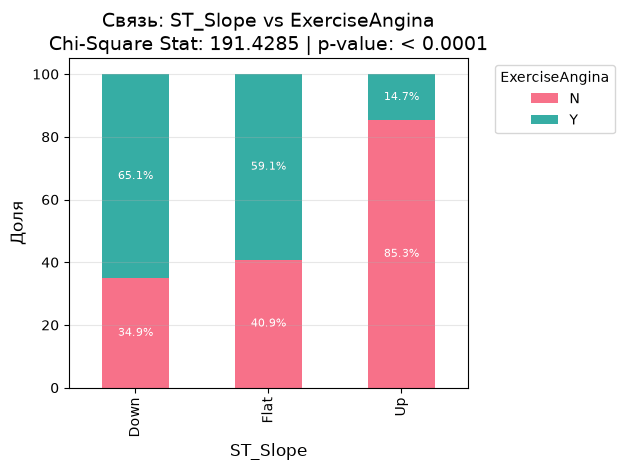

In [31]:
for col_1 in categorical_cols:
    for col_2 in categorical_cols:
        if col_1 != col_2:
            analyze_categorical_pair(df, col_1, col_2)

- `Sex` Существуют значимые взаимосвязи этого признака со всеми признаками кроме `RestingECG`.
- `ChestPainType` Взаимосвязи каждого из признаков с этим важны. Особенно `ExerciseAngina` и `ST_Slope`.
- `FastingBS` У признака есть связь с каждым признаком кроме `ExerciseAngina`.
- `RestingECG` У признака есть связь с каждым признаком кроме `ST_Slope` и `Sex`, на что мы уже указывали.
- `ExerciseAngina` У признака есть связь с каждым признаком кроме `FastingBS`, на что мы уже указывали. У признака сильная взаимосвязь с `ST_Slope`.
- `ST_Slope` У признака сильные связи со всеми признаками, кроме `RestingECG`, с которым, как мы уже указывали, связи нет.

#### Взаимосвязи между численными и категориальными признаками

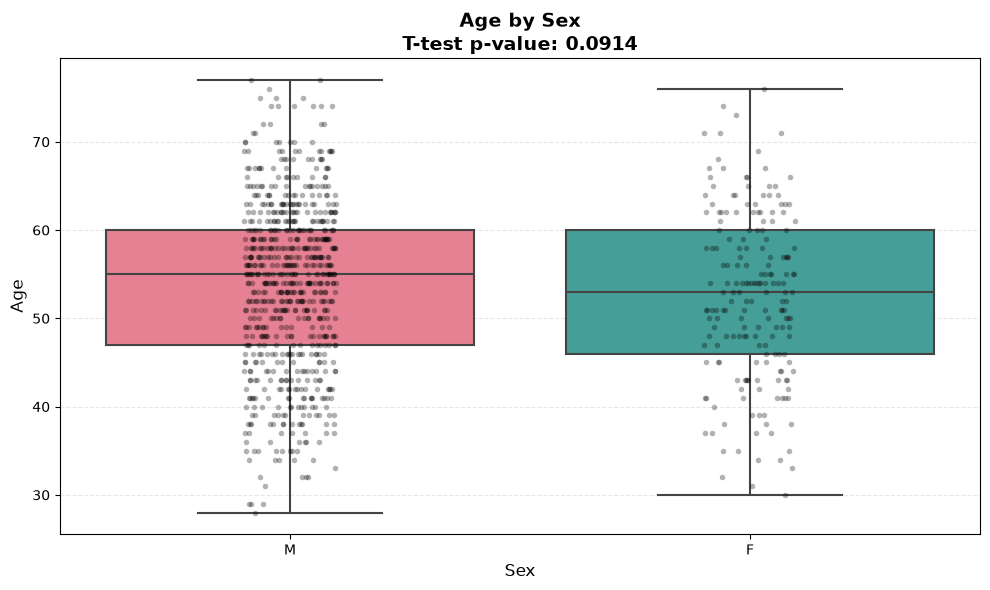

Анализ: Age vs Sex
• Тест: T-test
• P-value: 0.0914
Различий не обнаружено.


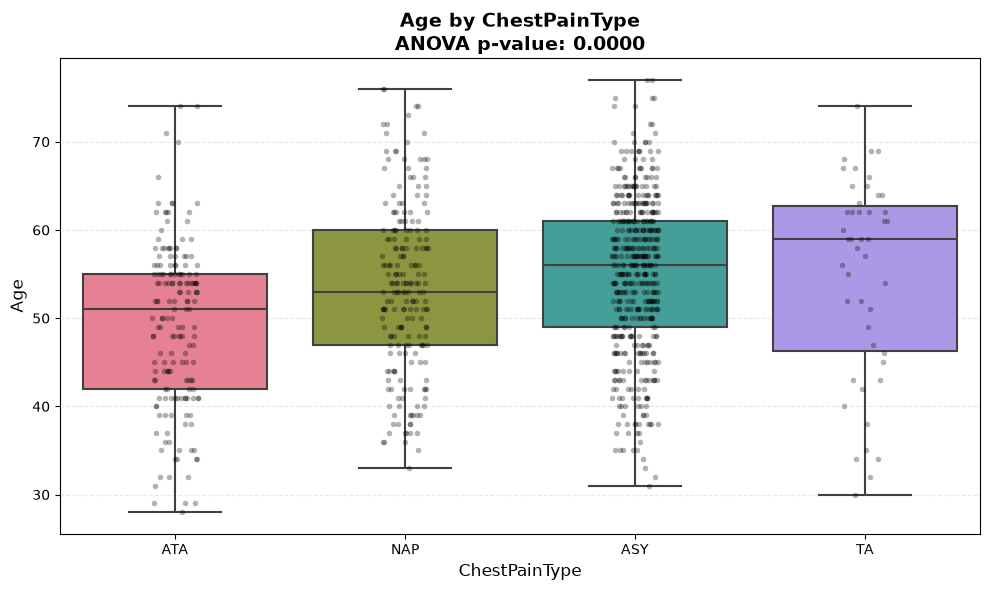

Анализ: Age vs ChestPainType
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


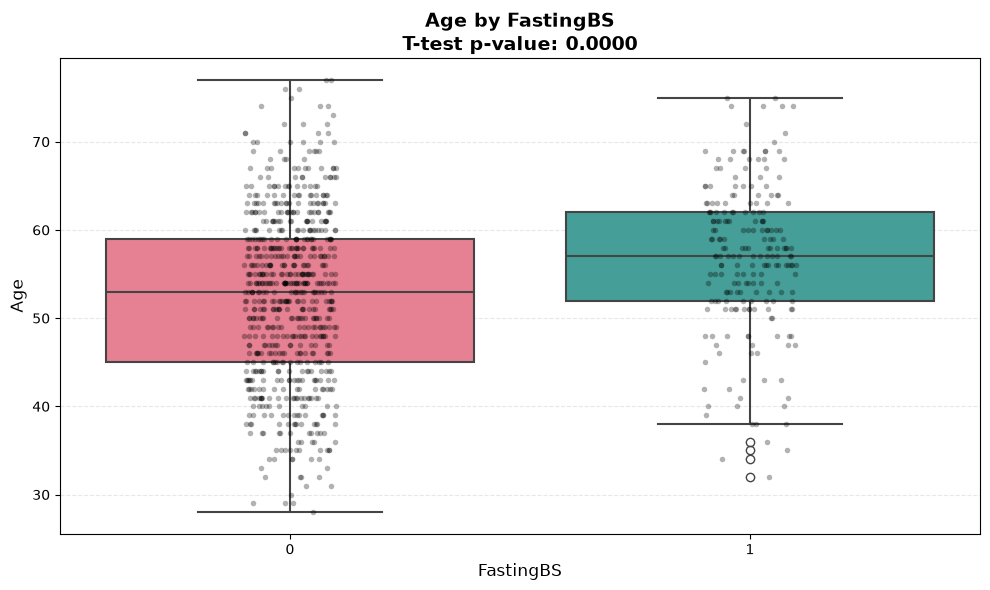

Анализ: Age vs FastingBS
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


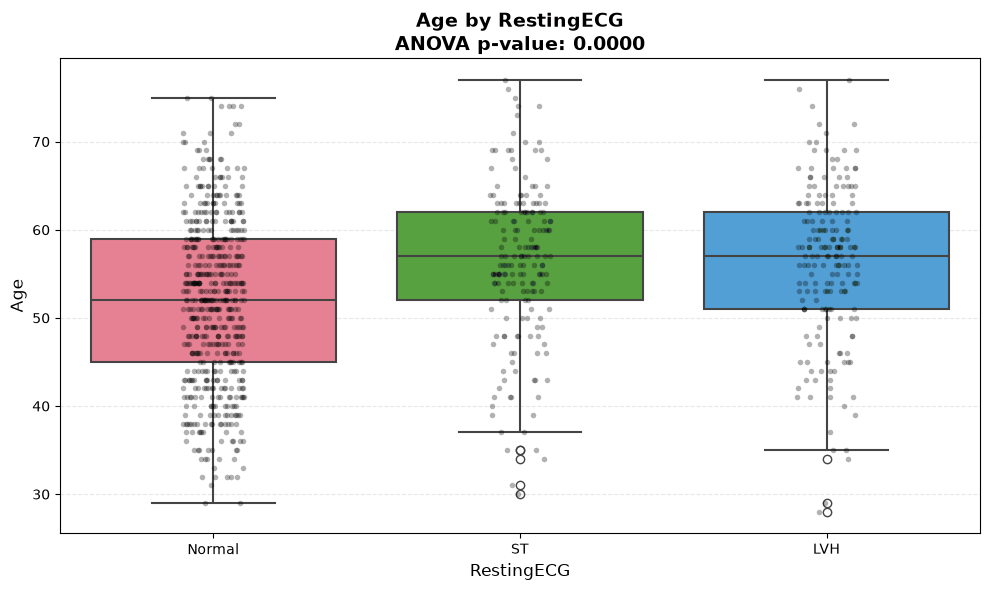

Анализ: Age vs RestingECG
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


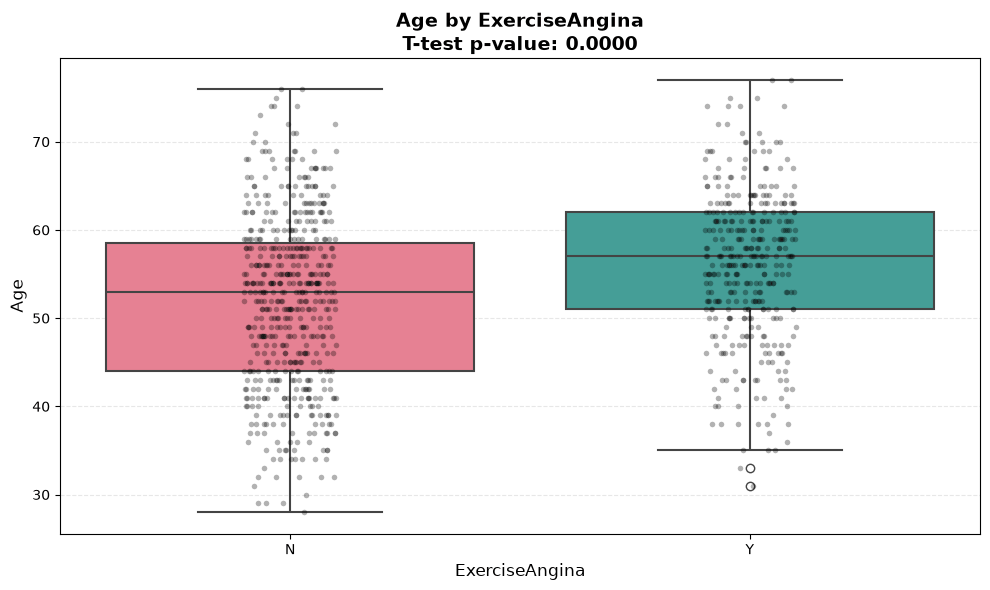

Анализ: Age vs ExerciseAngina
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


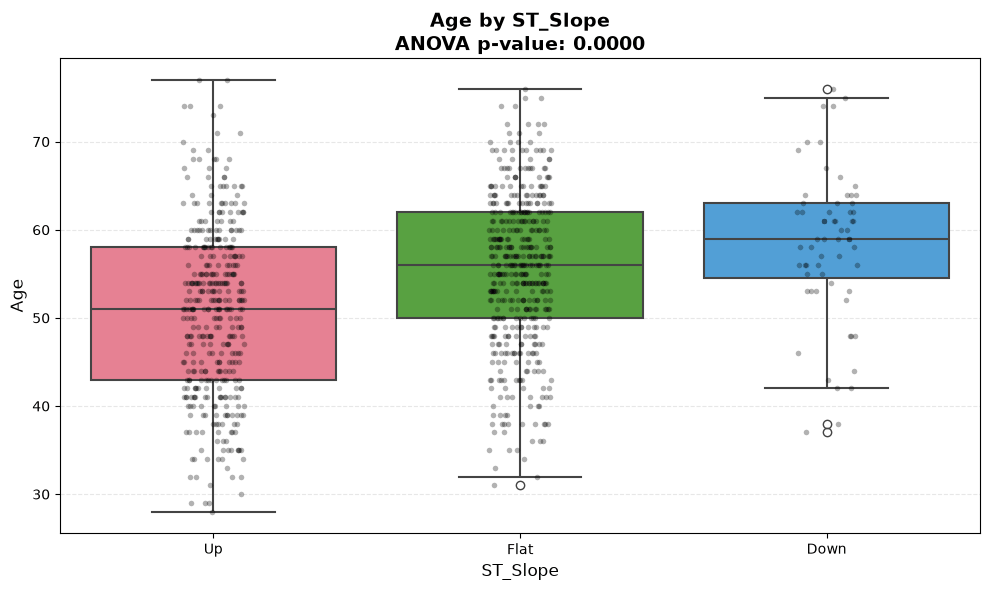

Анализ: Age vs ST_Slope
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


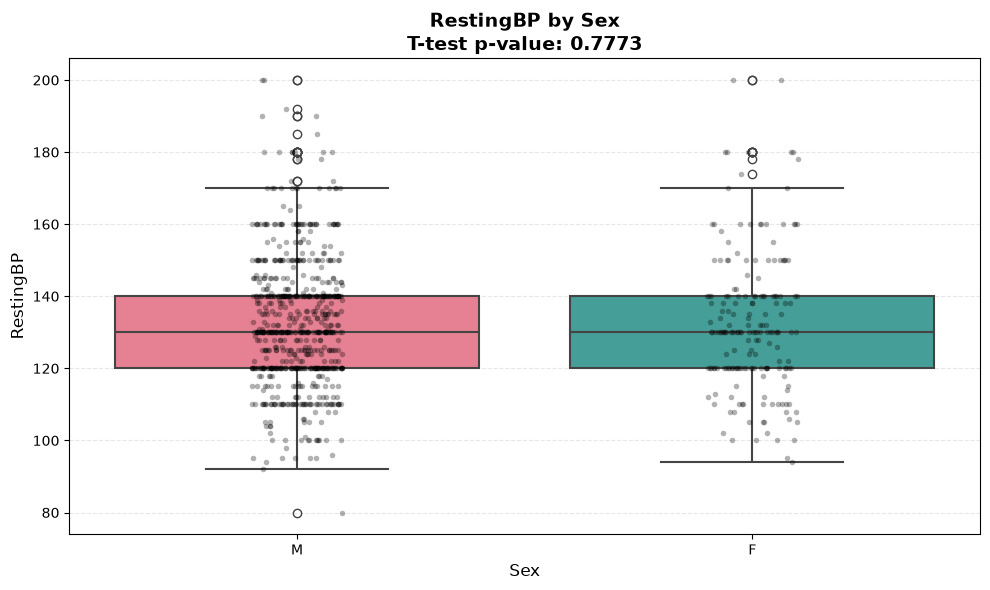

Анализ: RestingBP vs Sex
• Тест: T-test
• P-value: 0.7773
Различий не обнаружено.


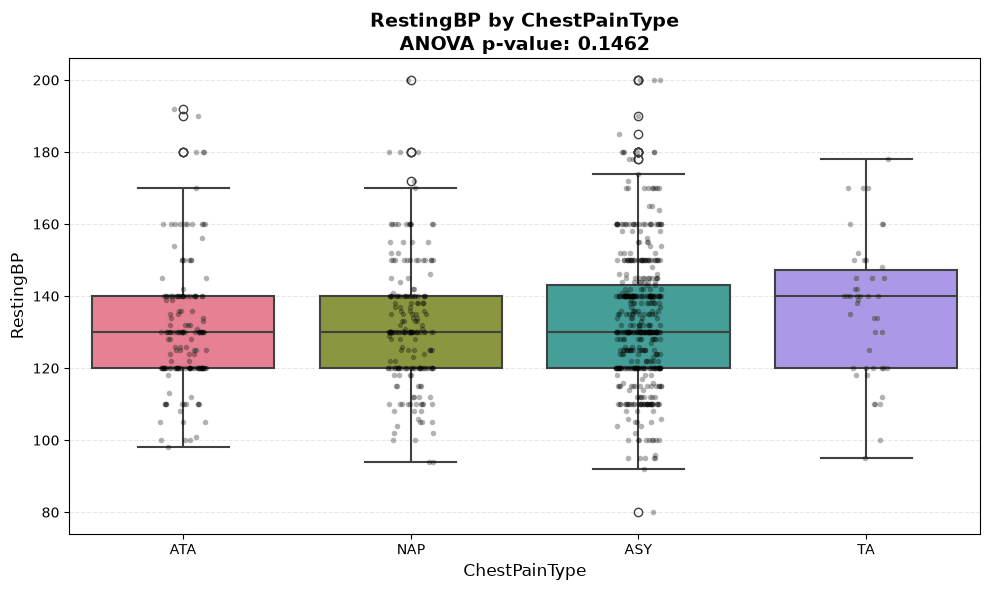

Анализ: RestingBP vs ChestPainType
• Тест: ANOVA
• P-value: 0.1462
Различий не обнаружено.


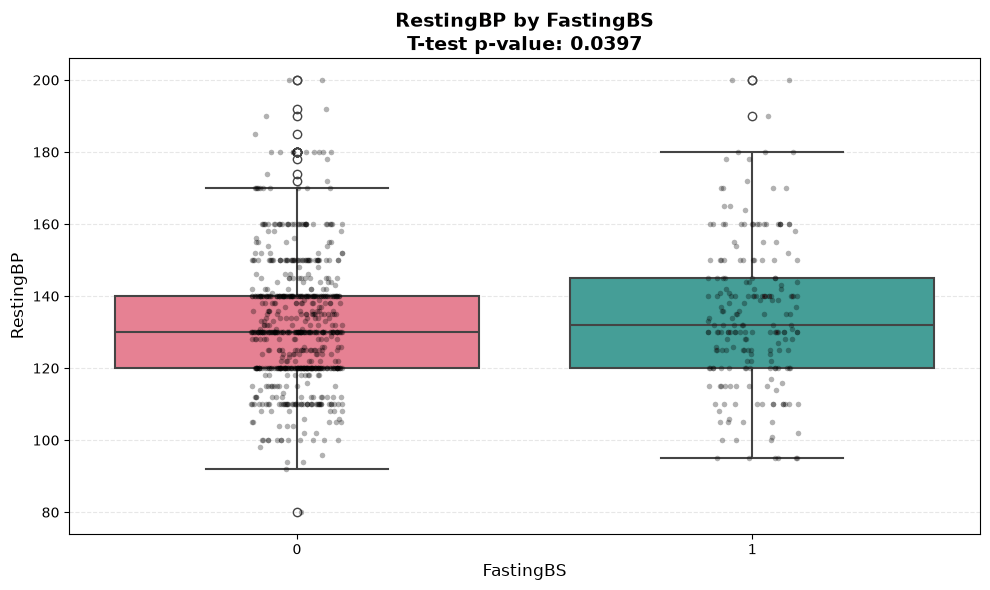

Анализ: RestingBP vs FastingBS
• Тест: T-test
• P-value: 0.0397
Значимые различия между группами!


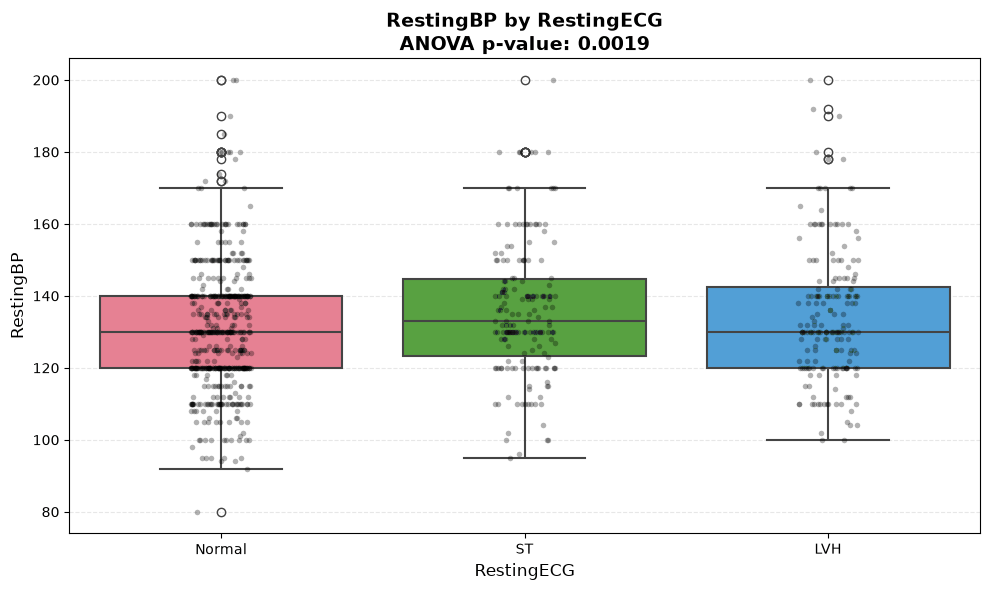

Анализ: RestingBP vs RestingECG
• Тест: ANOVA
• P-value: 0.0019
Значимые различия между группами!


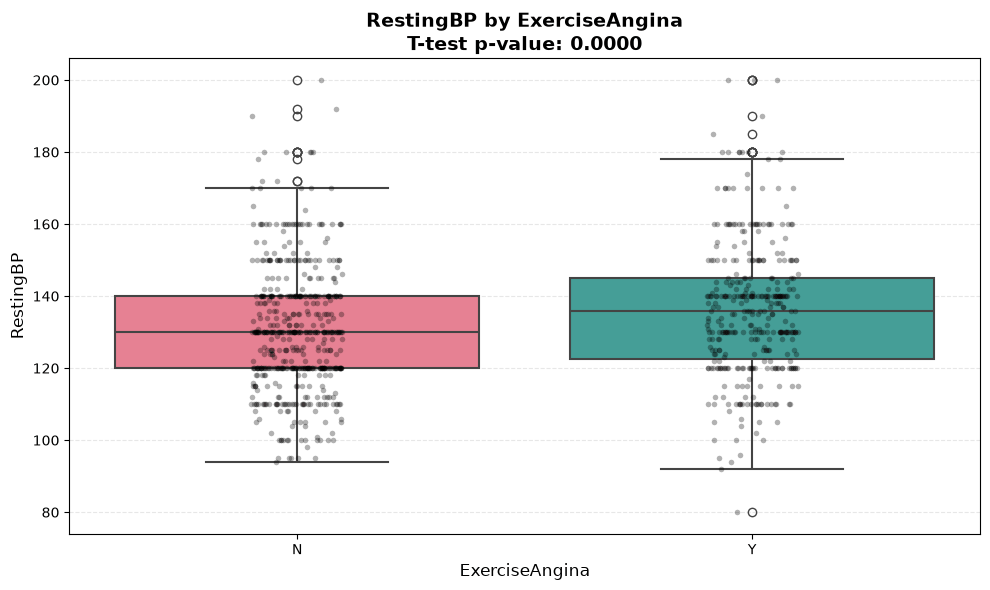

Анализ: RestingBP vs ExerciseAngina
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


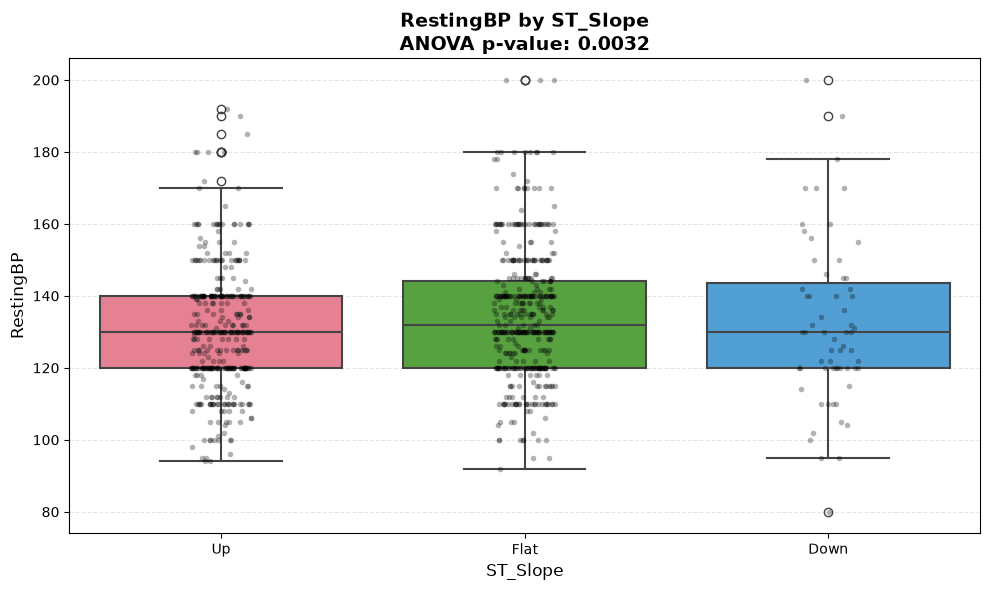

Анализ: RestingBP vs ST_Slope
• Тест: ANOVA
• P-value: 0.0032
Значимые различия между группами!


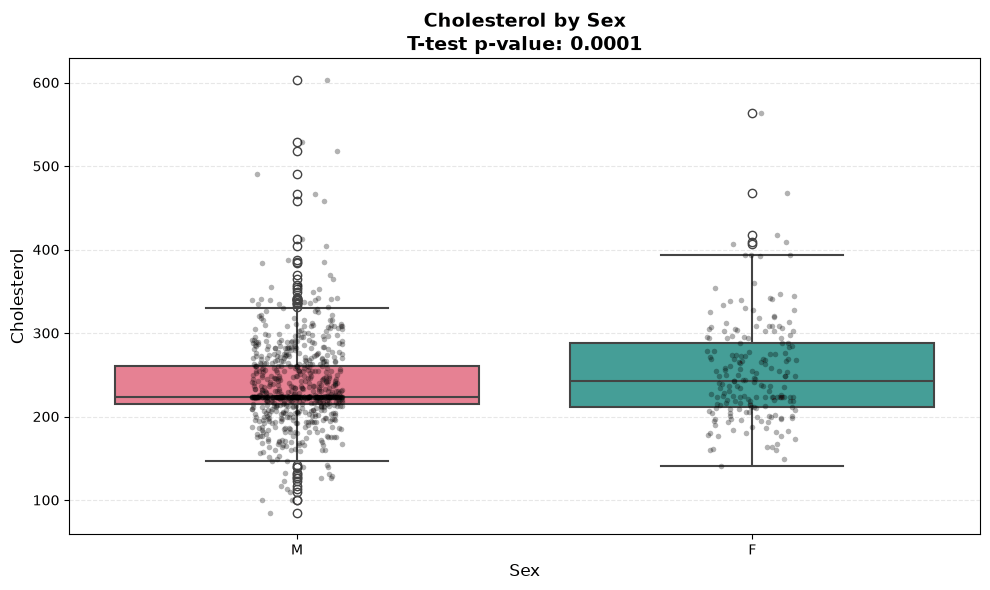

Анализ: Cholesterol vs Sex
• Тест: T-test
• P-value: 0.0001
Значимые различия между группами!


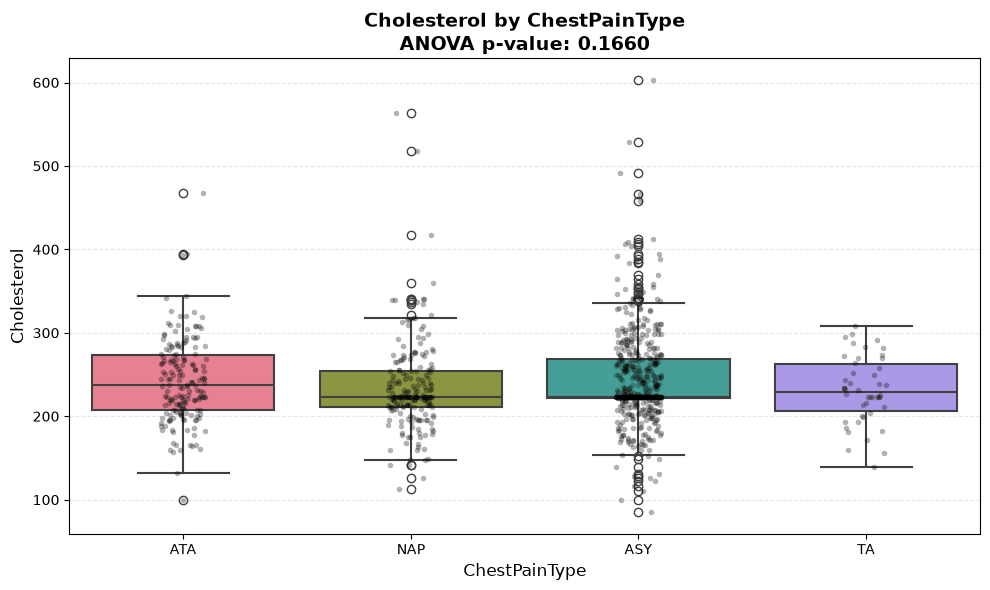

Анализ: Cholesterol vs ChestPainType
• Тест: ANOVA
• P-value: 0.1660
Различий не обнаружено.


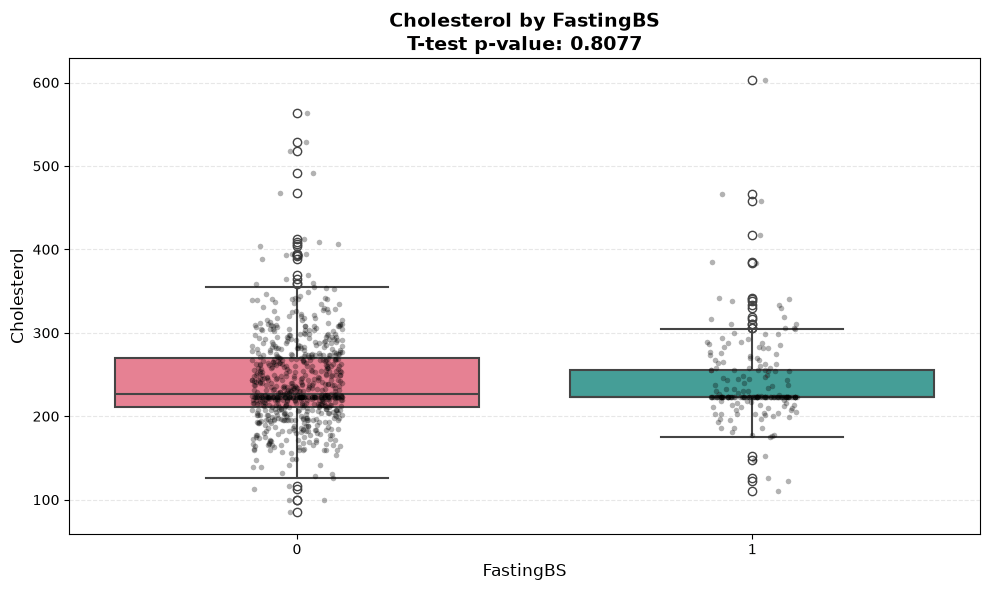

Анализ: Cholesterol vs FastingBS
• Тест: T-test
• P-value: 0.8077
Различий не обнаружено.


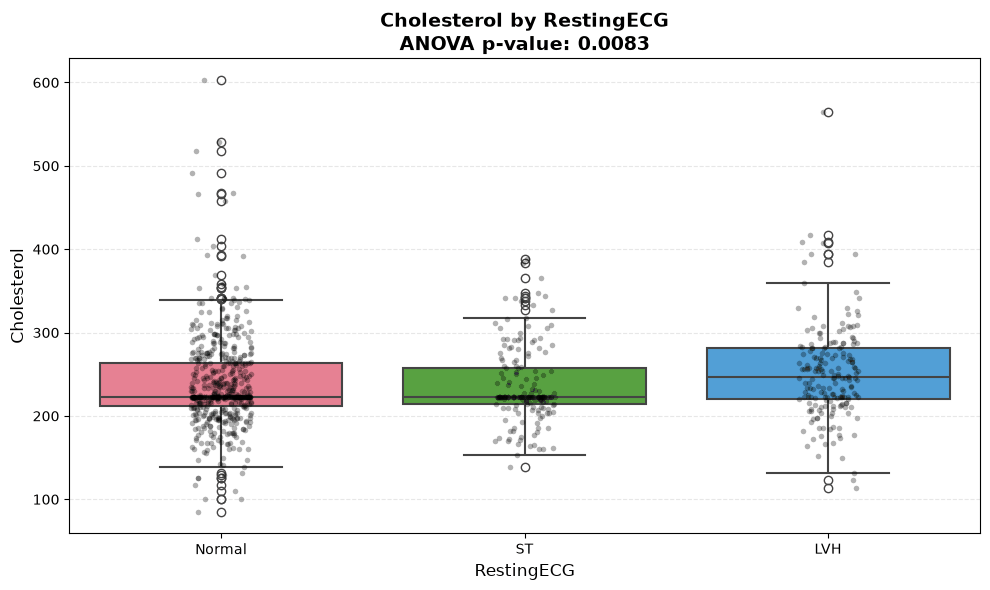

Анализ: Cholesterol vs RestingECG
• Тест: ANOVA
• P-value: 0.0083
Значимые различия между группами!


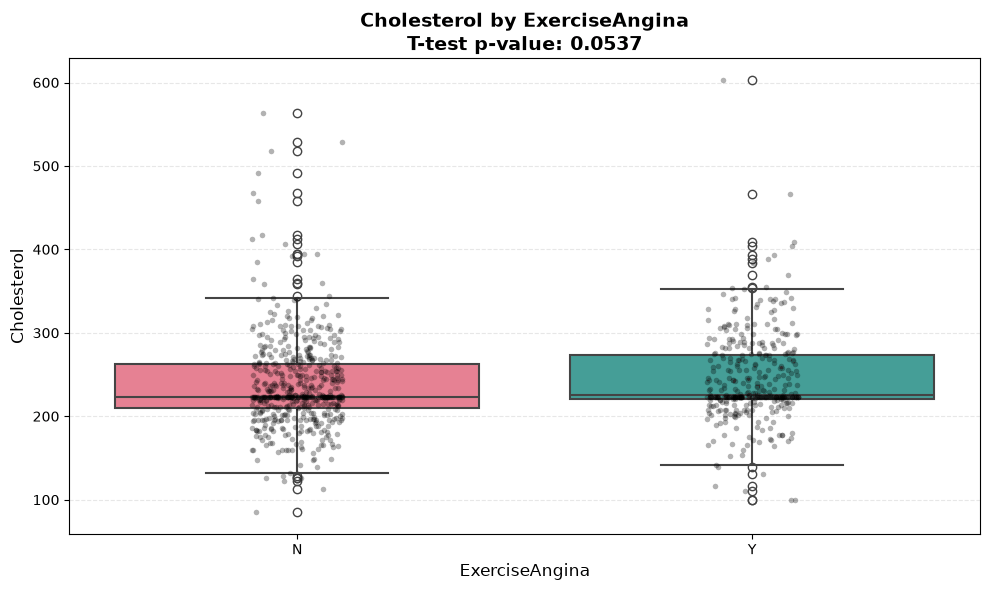

Анализ: Cholesterol vs ExerciseAngina
• Тест: T-test
• P-value: 0.0537
Различий не обнаружено.


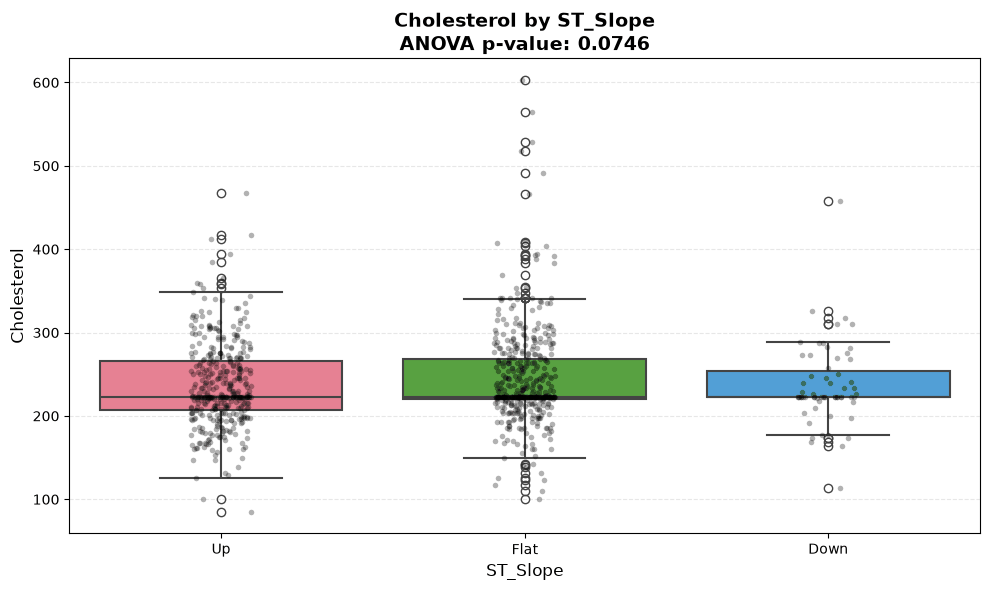

Анализ: Cholesterol vs ST_Slope
• Тест: ANOVA
• P-value: 0.0746
Различий не обнаружено.


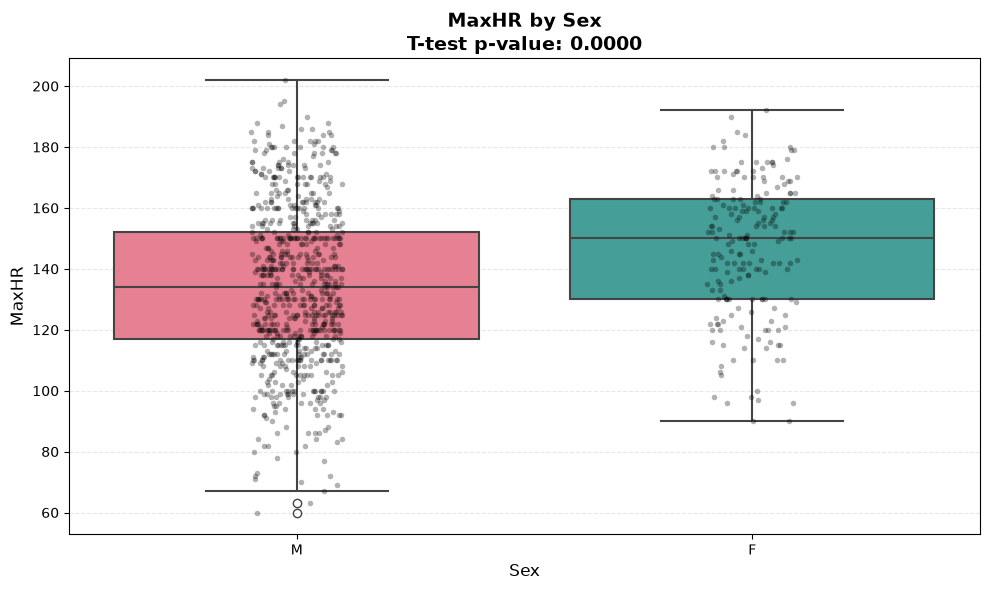

Анализ: MaxHR vs Sex
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


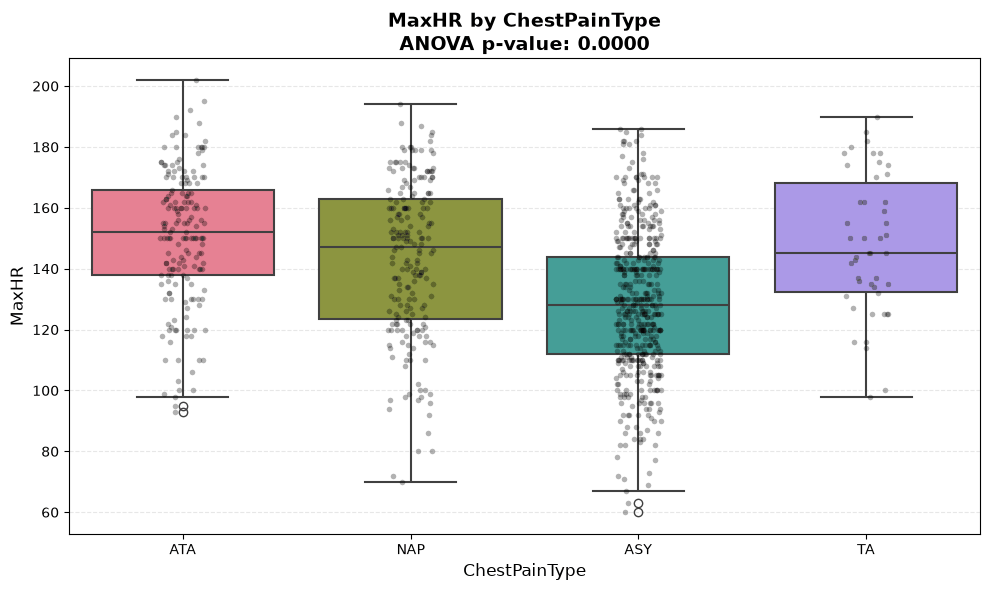

Анализ: MaxHR vs ChestPainType
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


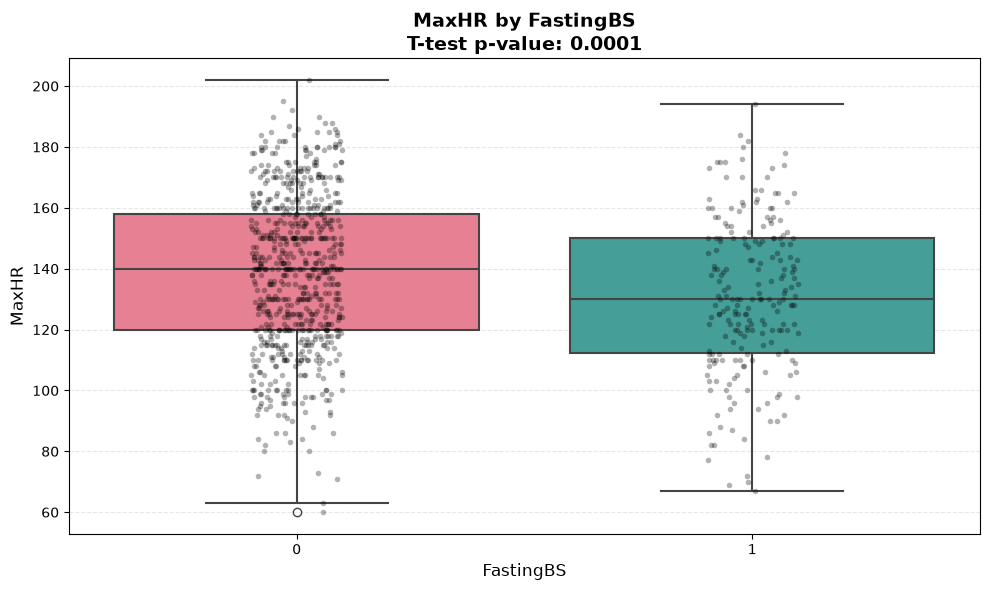

Анализ: MaxHR vs FastingBS
• Тест: T-test
• P-value: 0.0001
Значимые различия между группами!


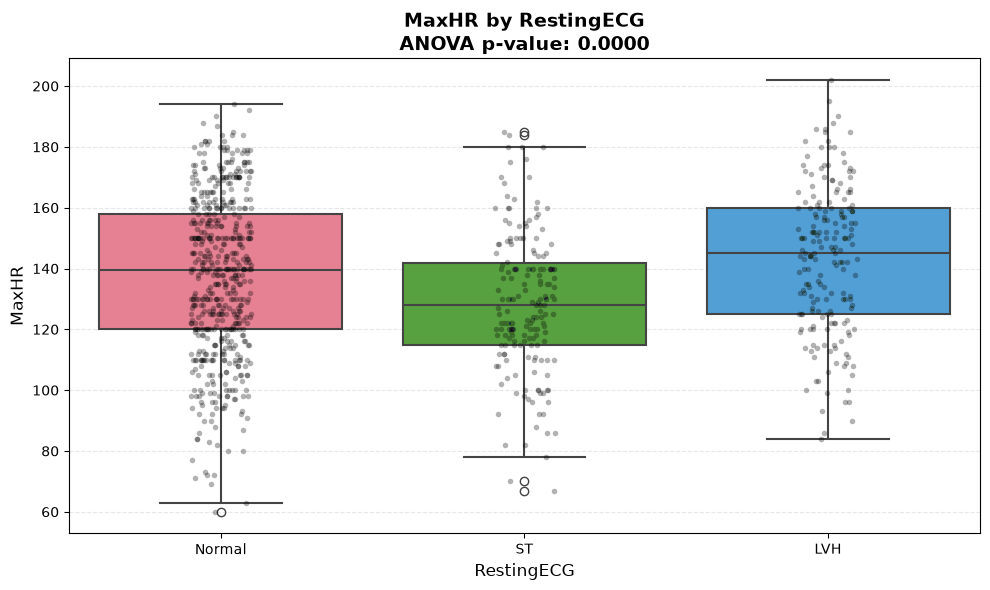

Анализ: MaxHR vs RestingECG
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


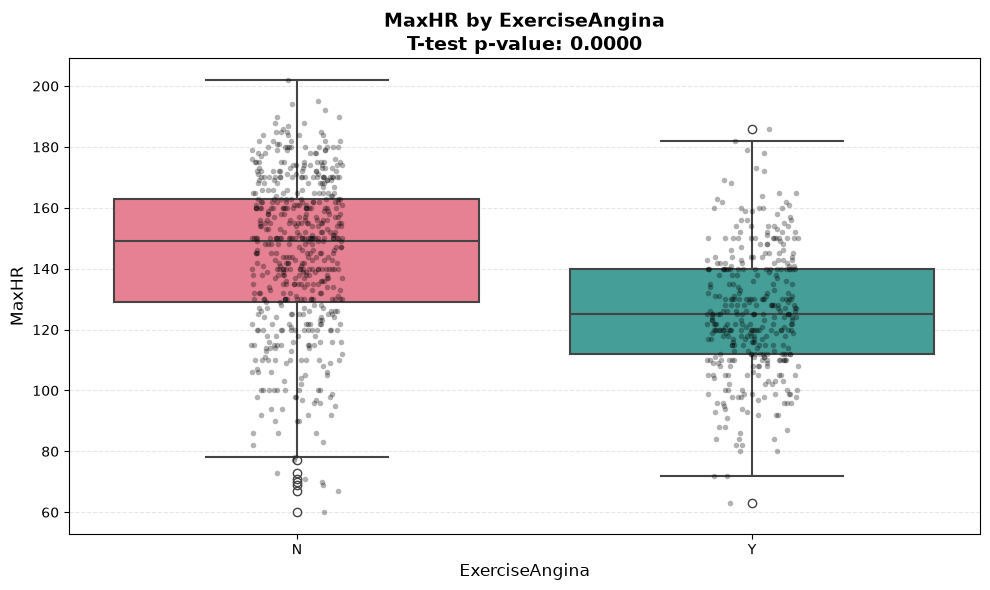

Анализ: MaxHR vs ExerciseAngina
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


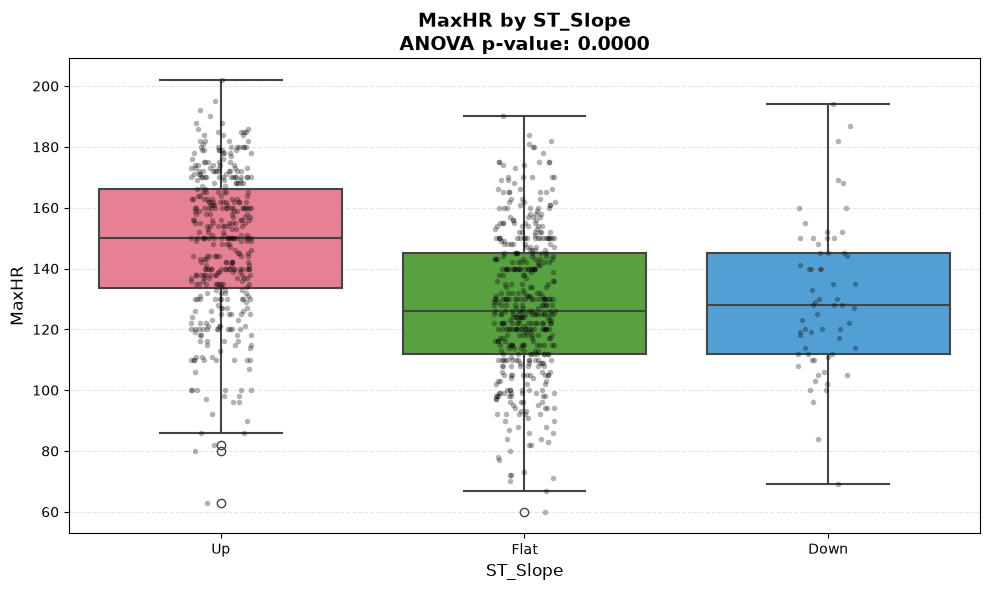

Анализ: MaxHR vs ST_Slope
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


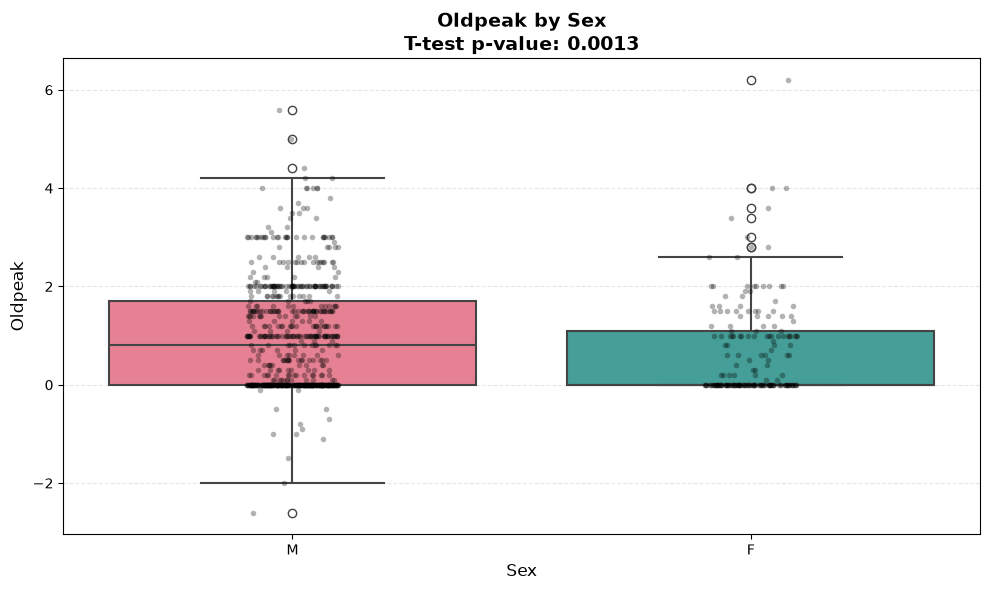

Анализ: Oldpeak vs Sex
• Тест: T-test
• P-value: 0.0013
Значимые различия между группами!


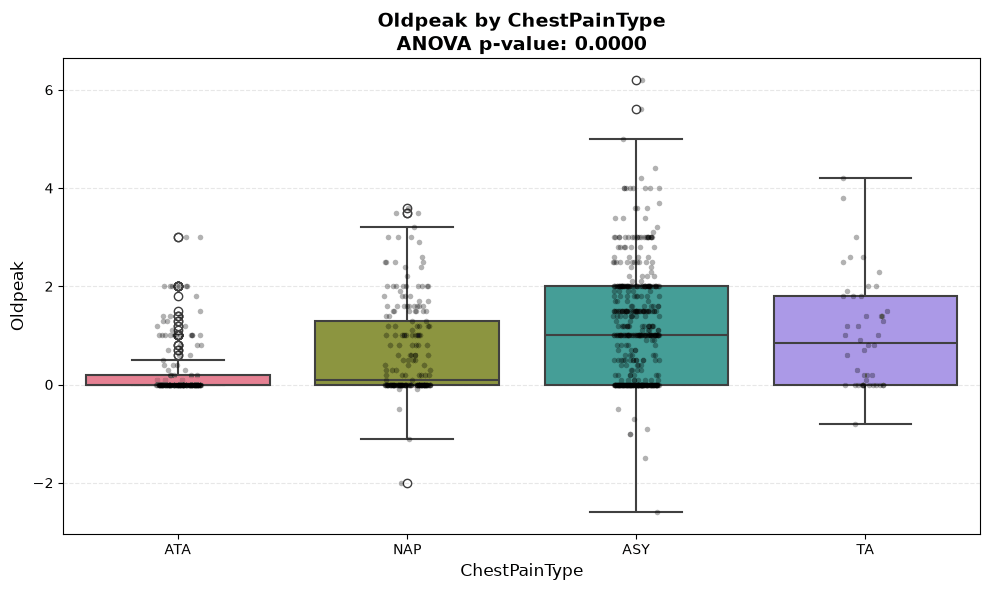

Анализ: Oldpeak vs ChestPainType
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


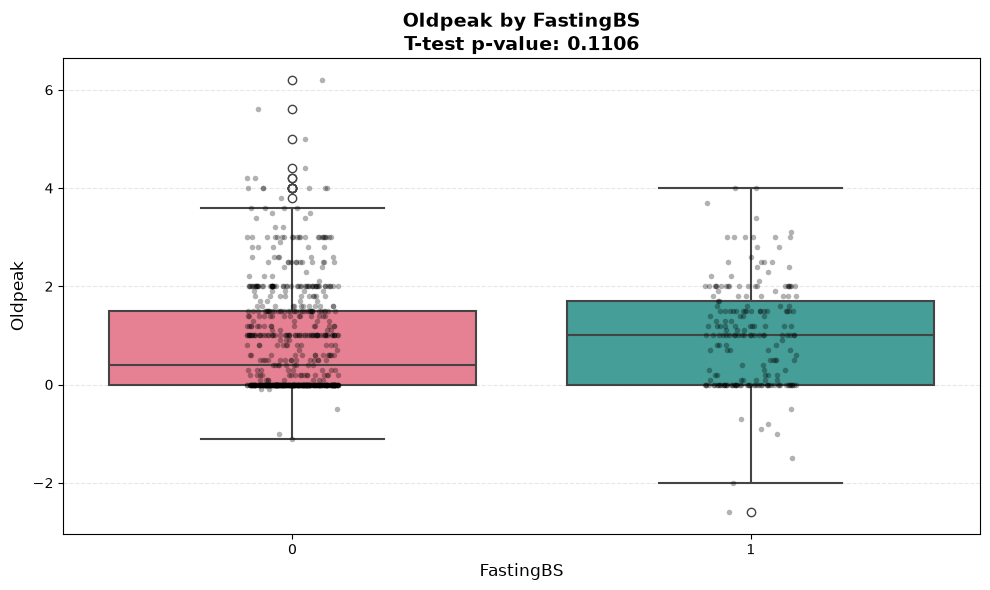

Анализ: Oldpeak vs FastingBS
• Тест: T-test
• P-value: 0.1106
Различий не обнаружено.


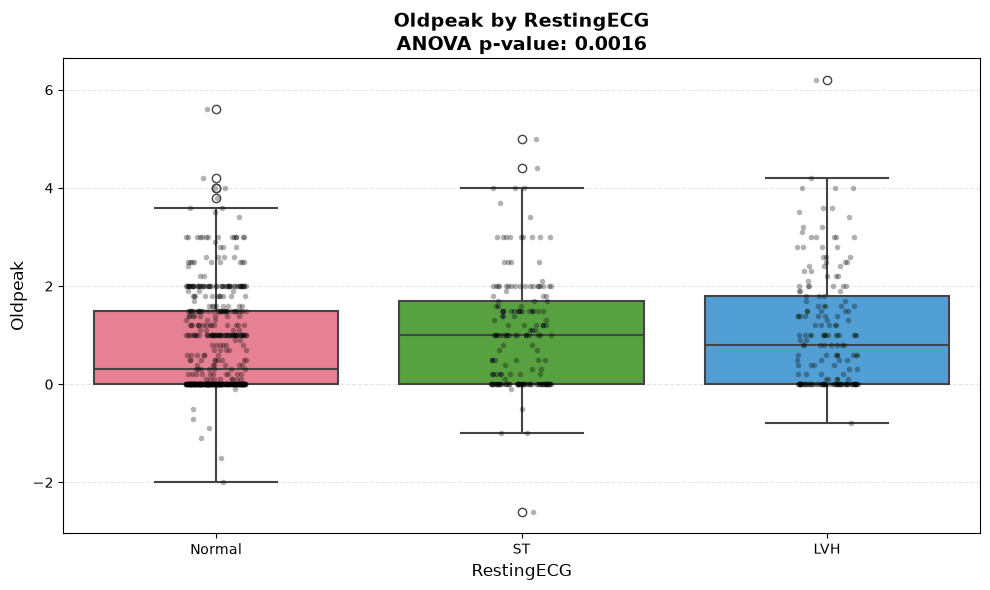

Анализ: Oldpeak vs RestingECG
• Тест: ANOVA
• P-value: 0.0016
Значимые различия между группами!


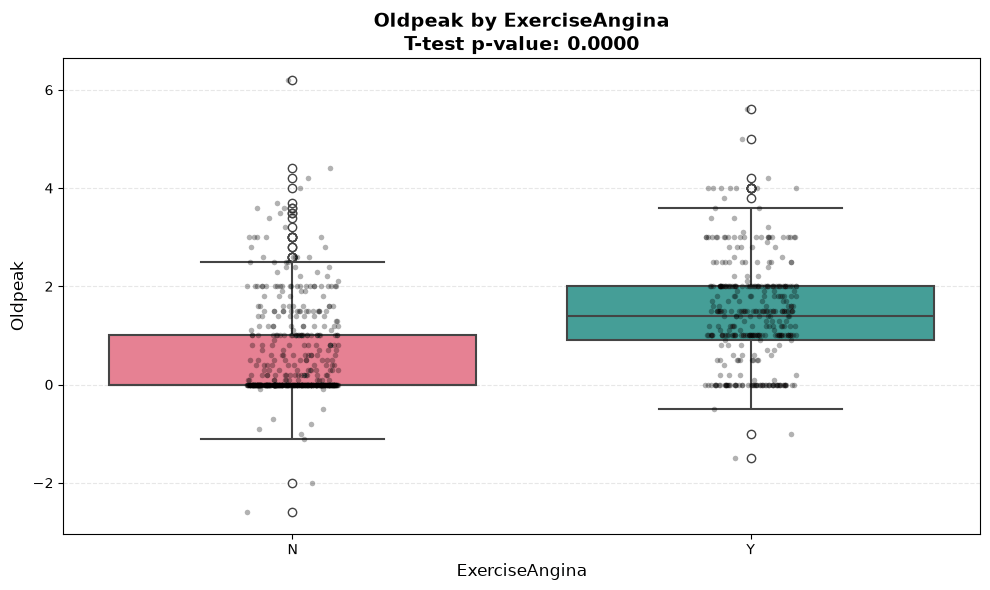

Анализ: Oldpeak vs ExerciseAngina
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


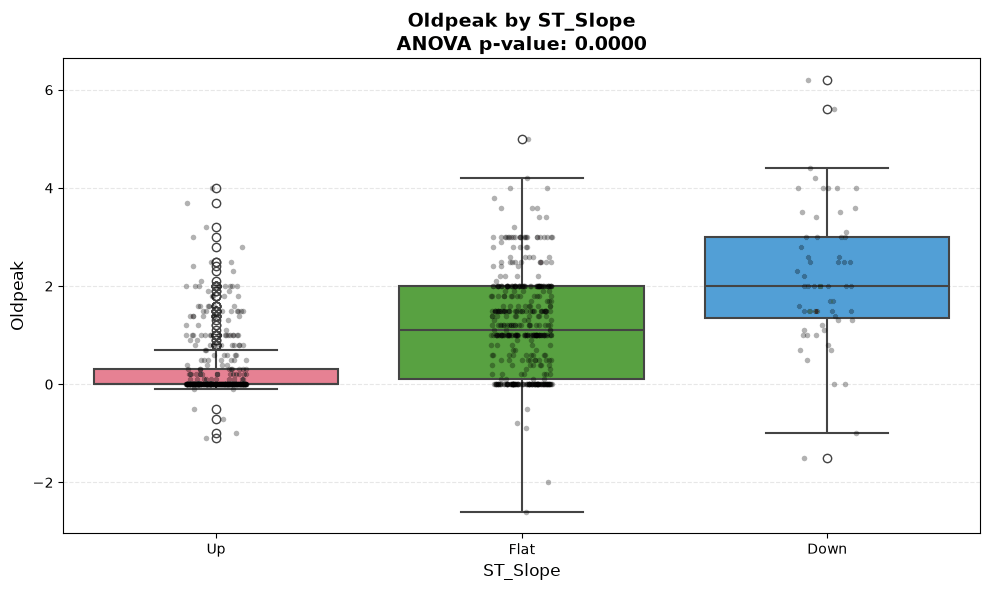

Анализ: Oldpeak vs ST_Slope
• Тест: ANOVA
• P-value: 0.0000
Значимые различия между группами!


In [32]:
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        analyze_num_cat(df, num_col, cat_col)

#### Взаимосвязи между двумя численными и категориальными признаками

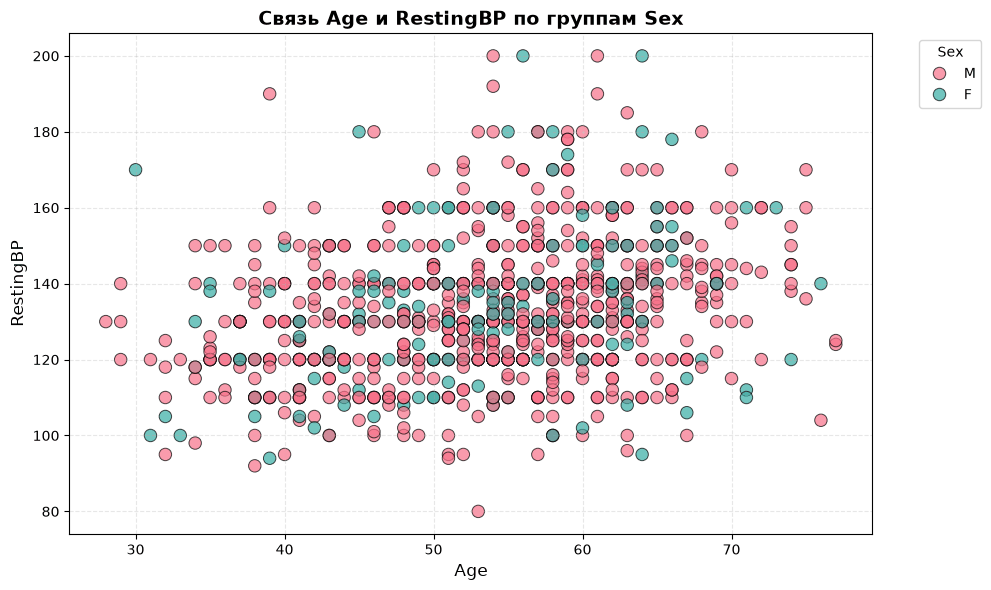

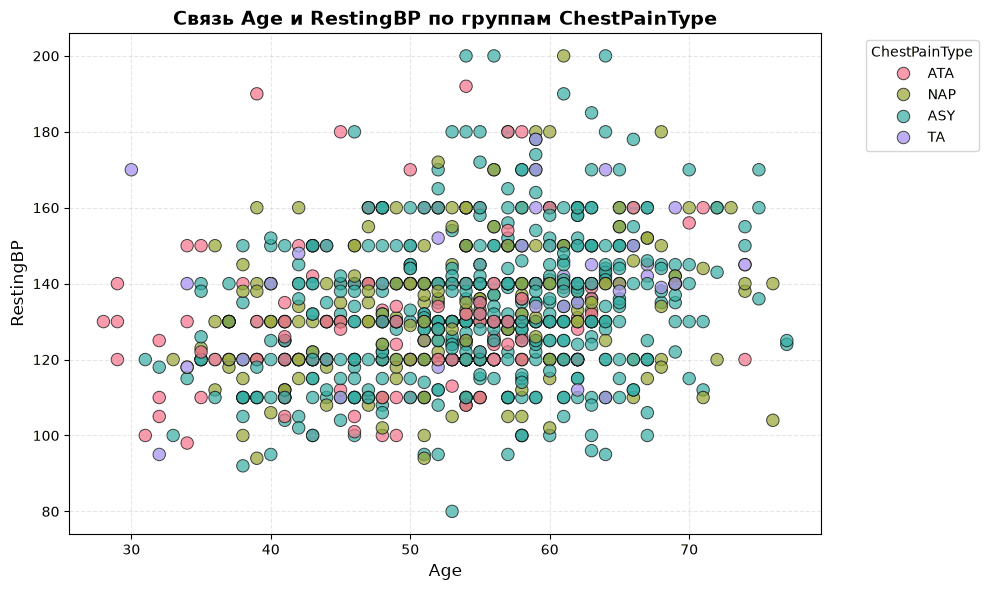

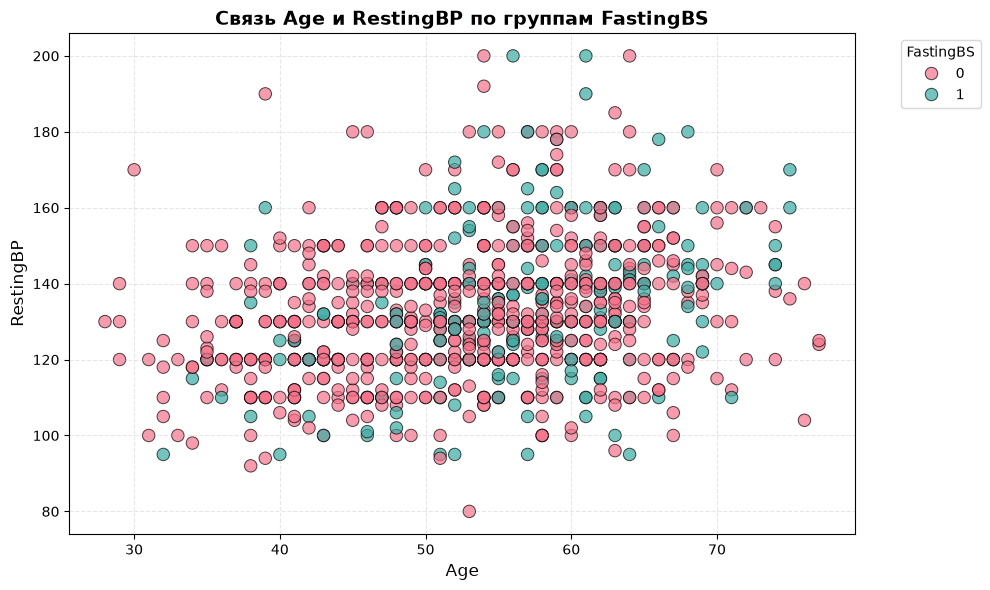

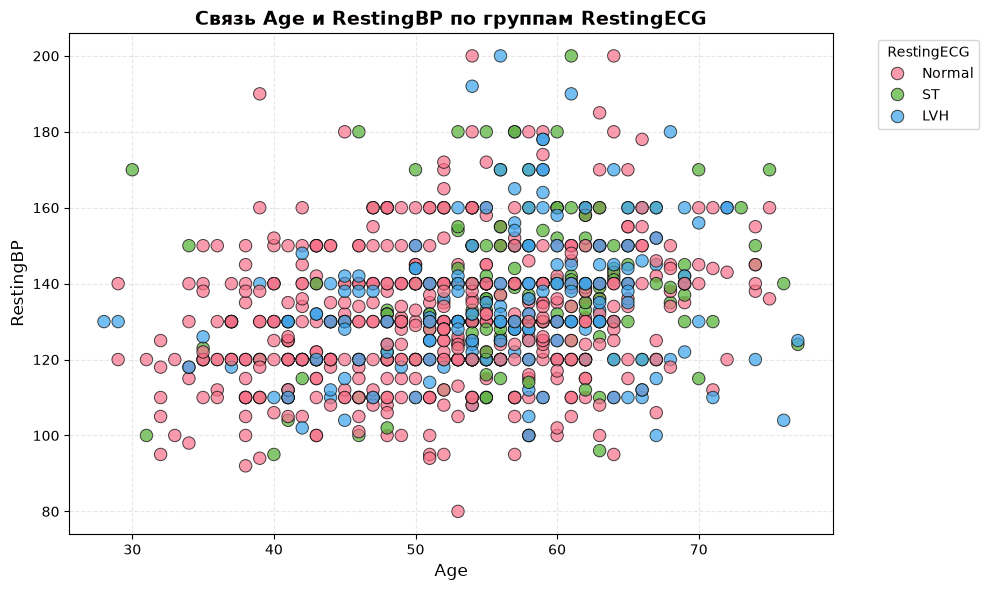

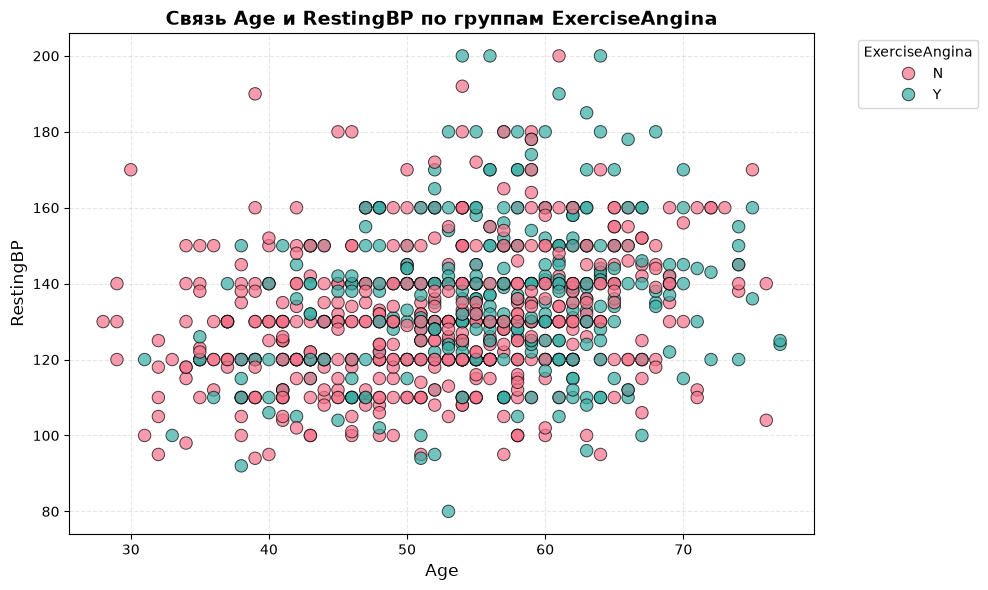

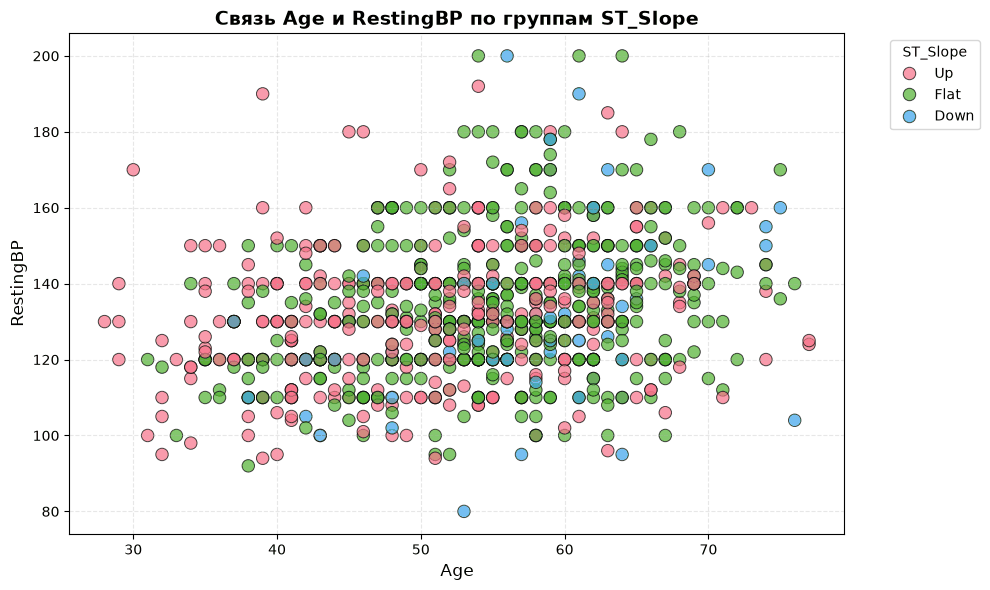

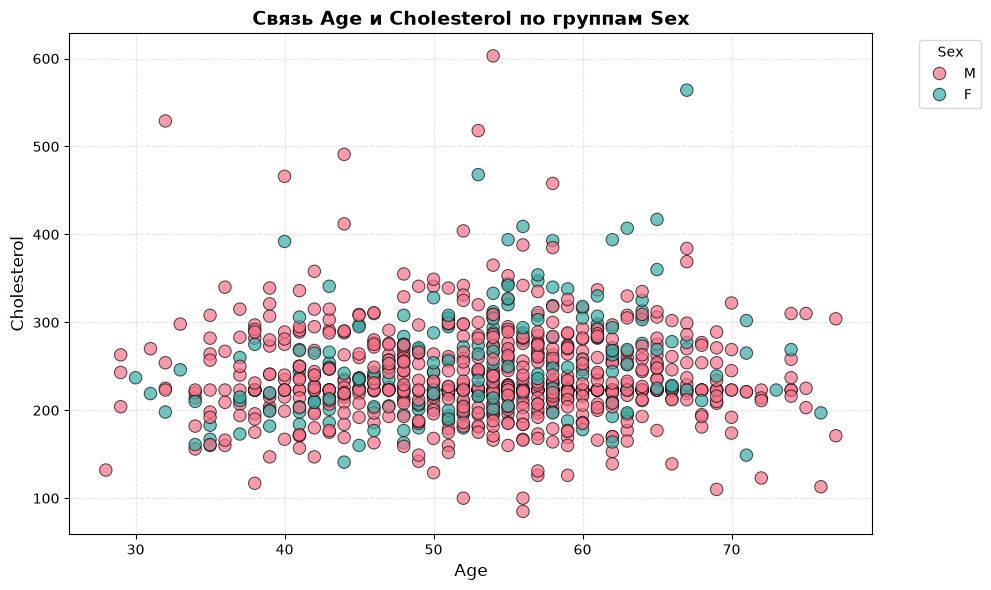

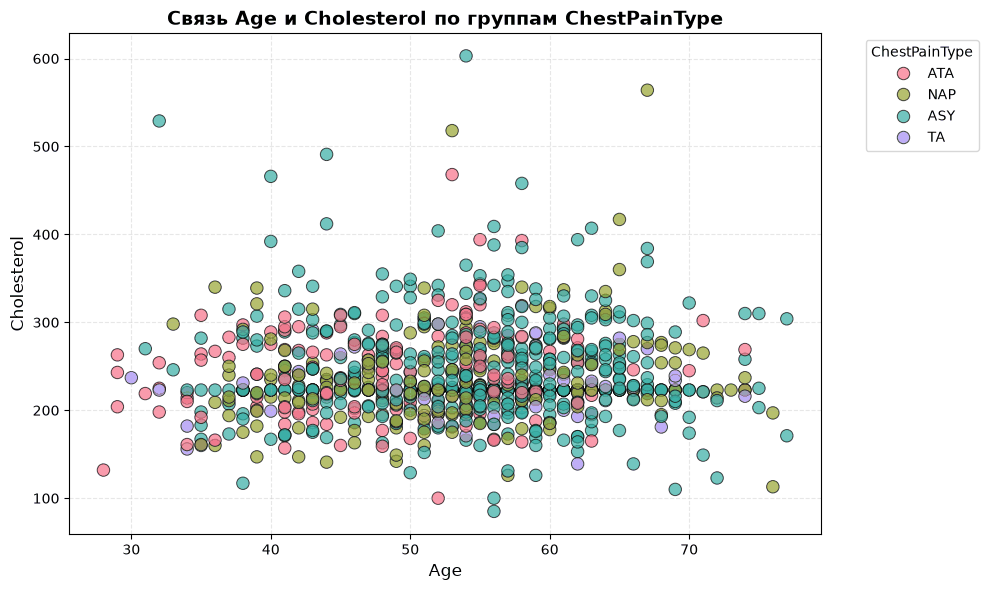

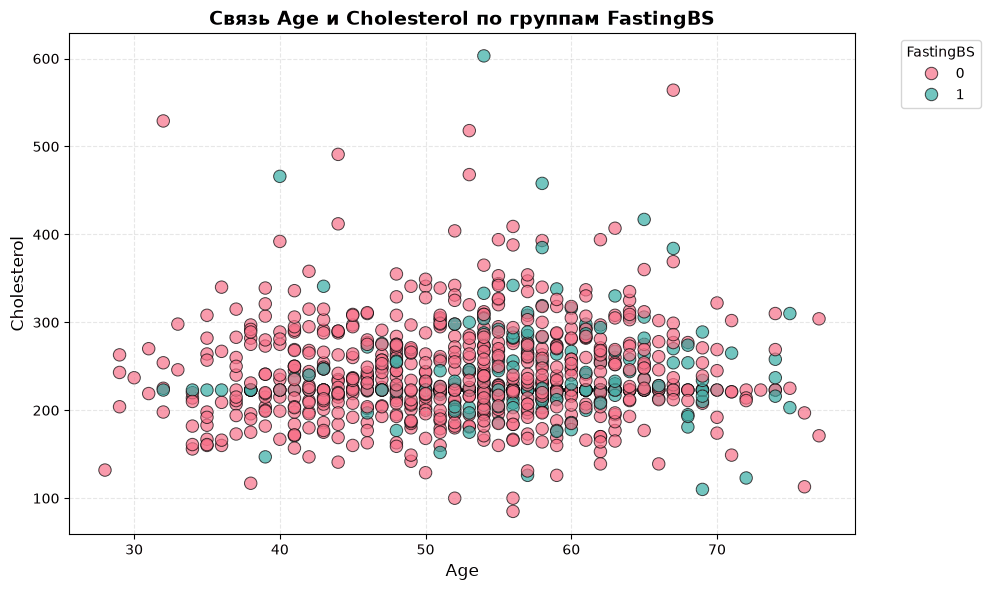

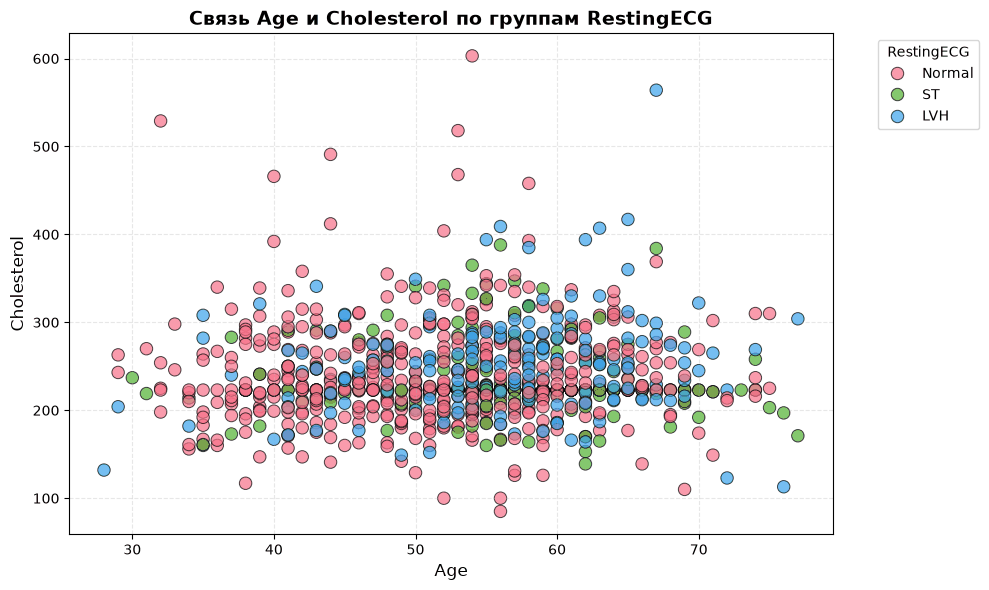

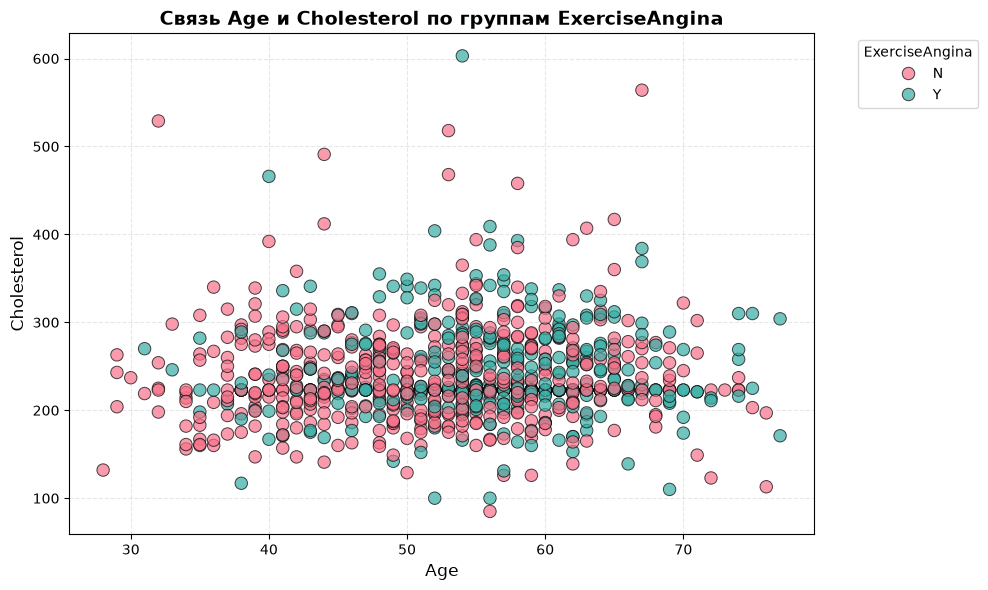

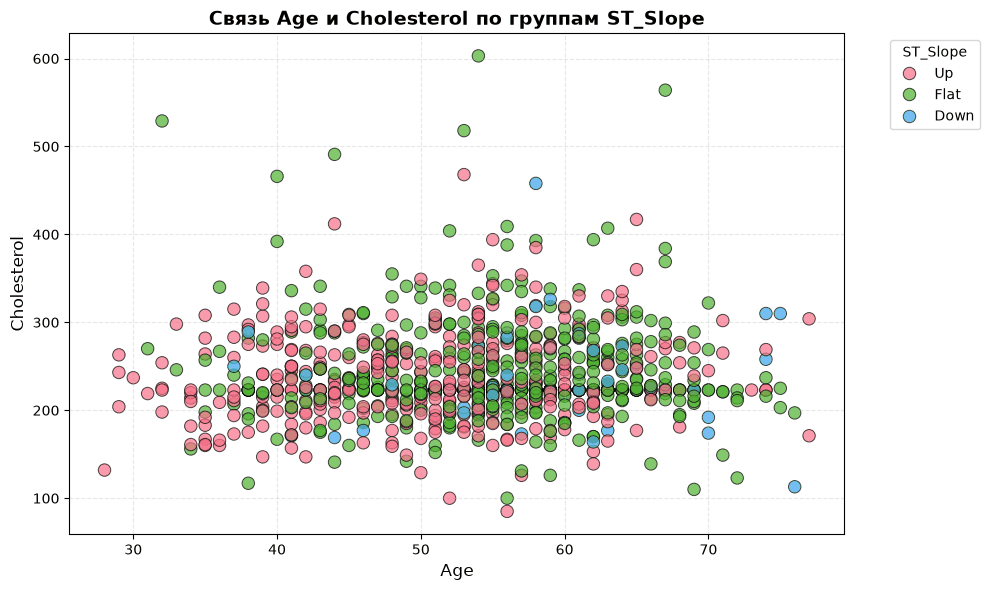

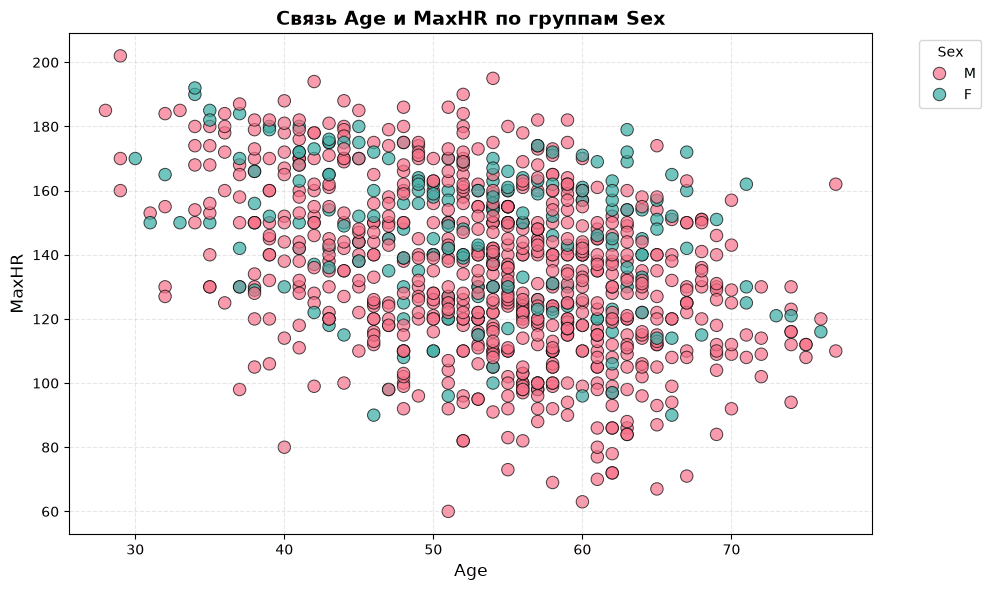

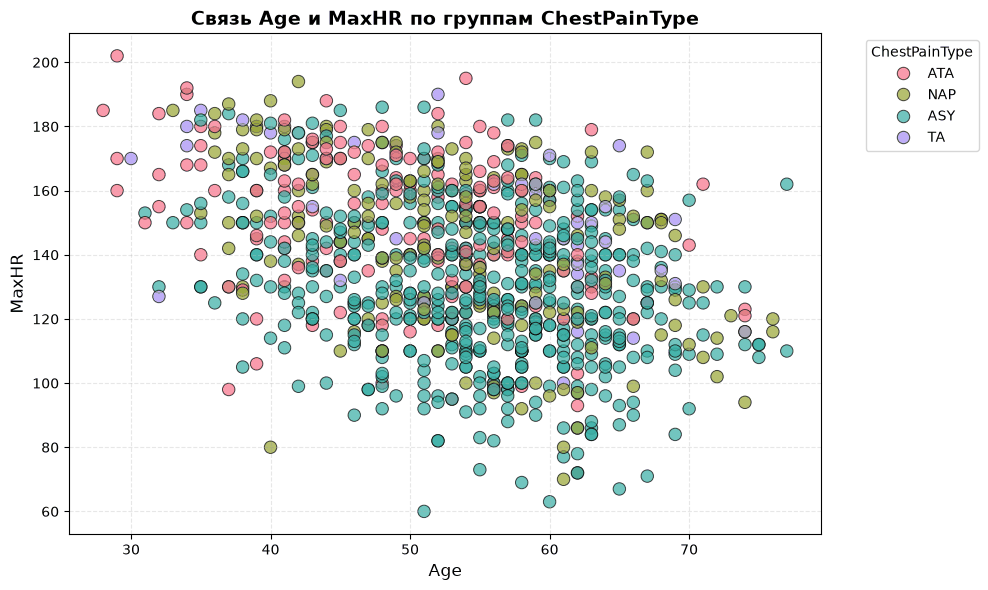

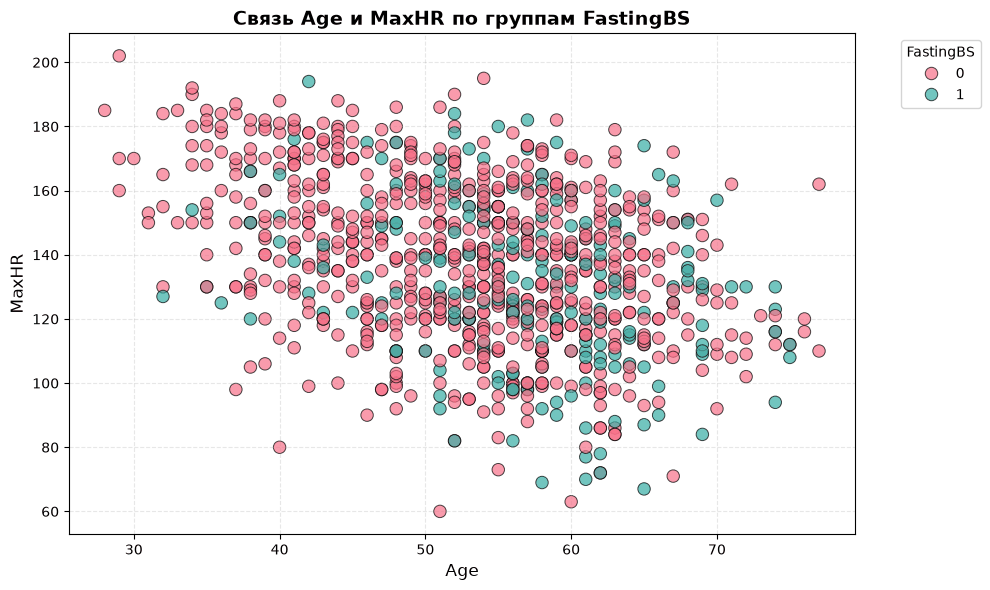

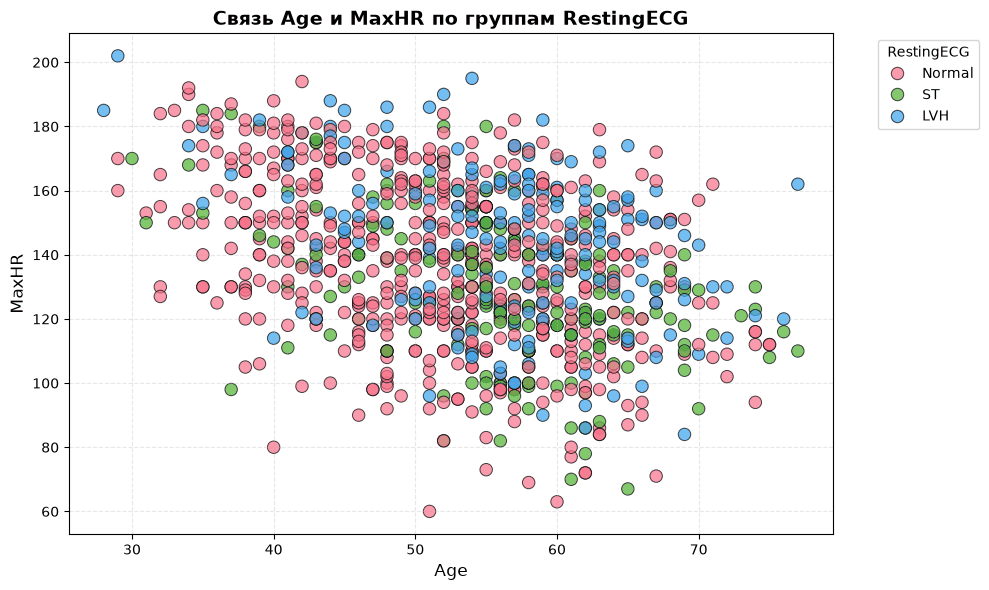

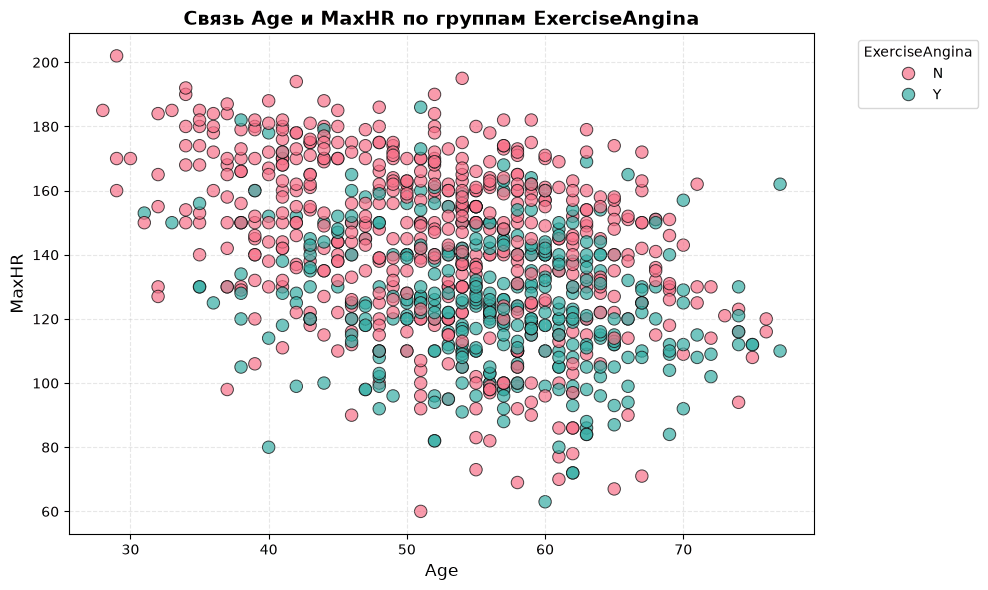

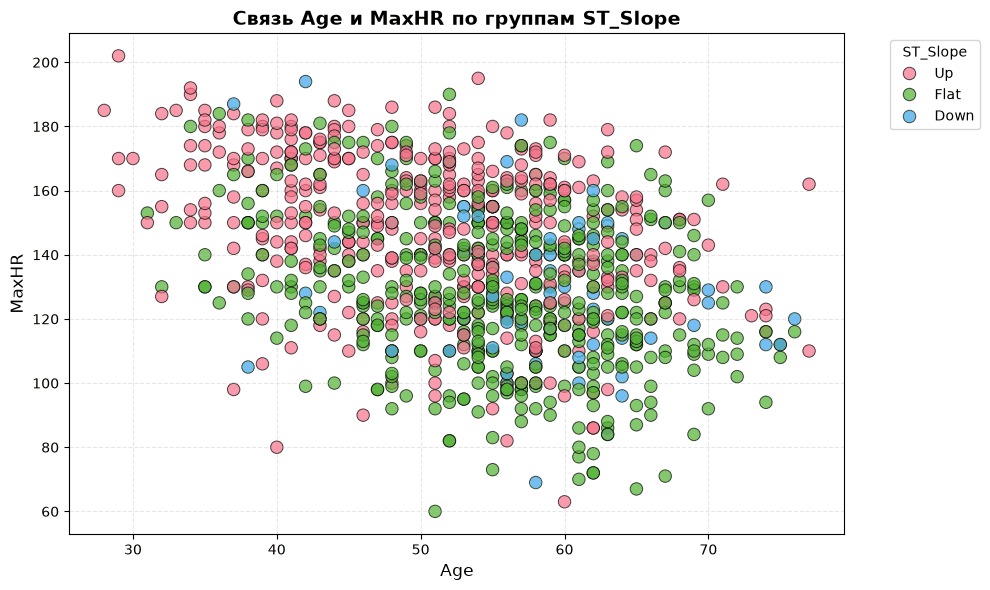

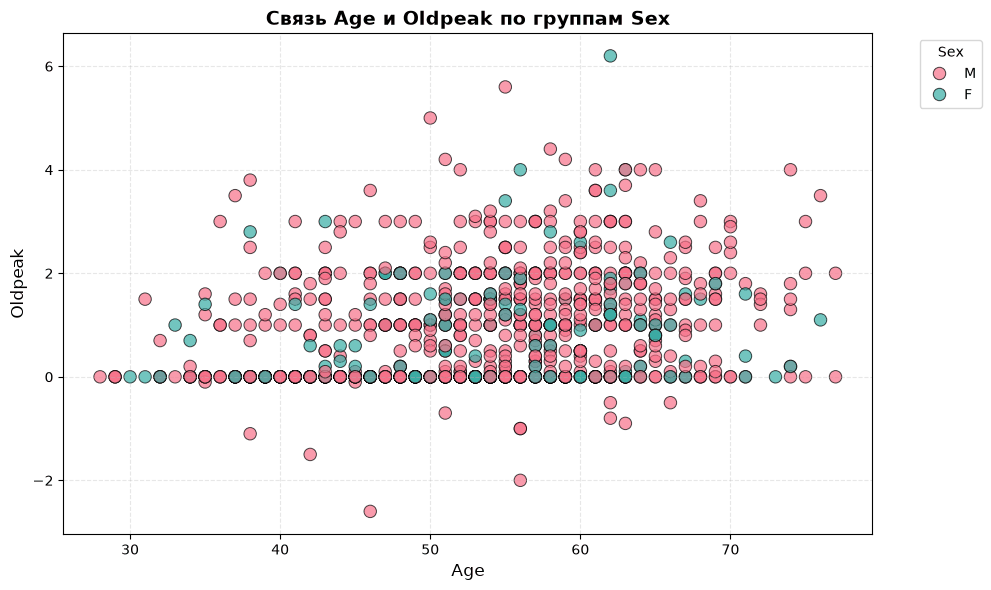

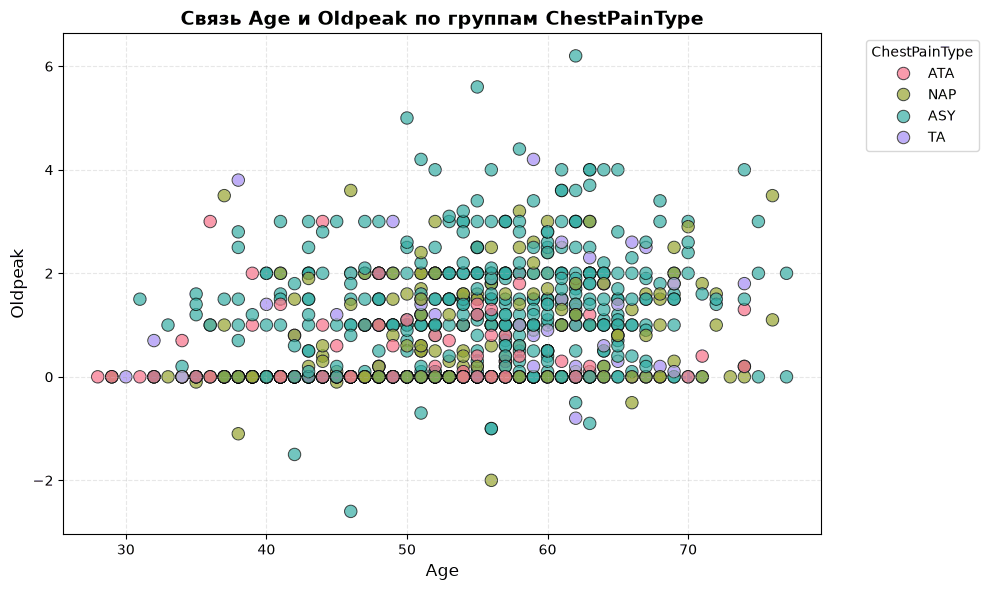

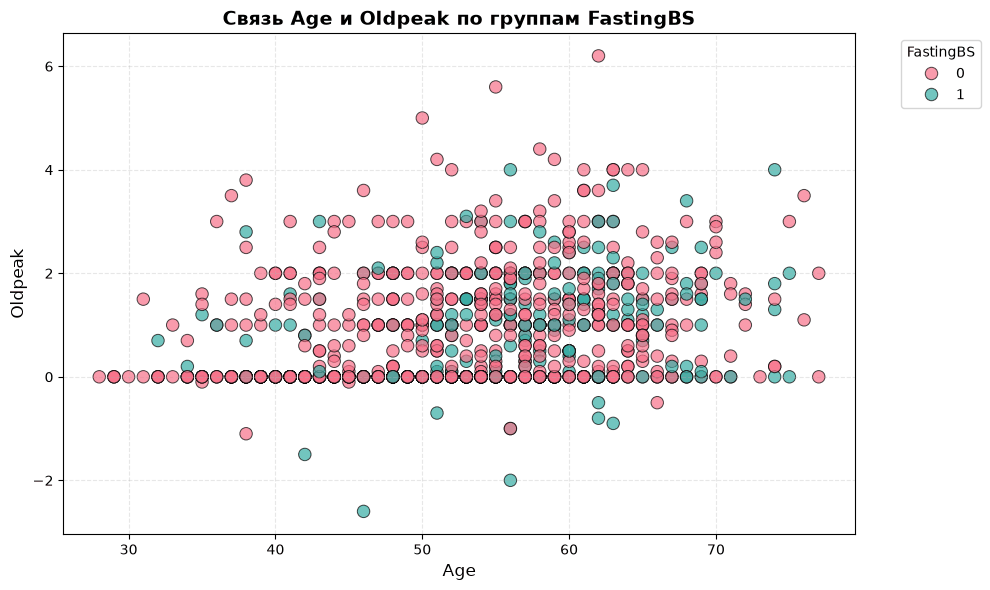

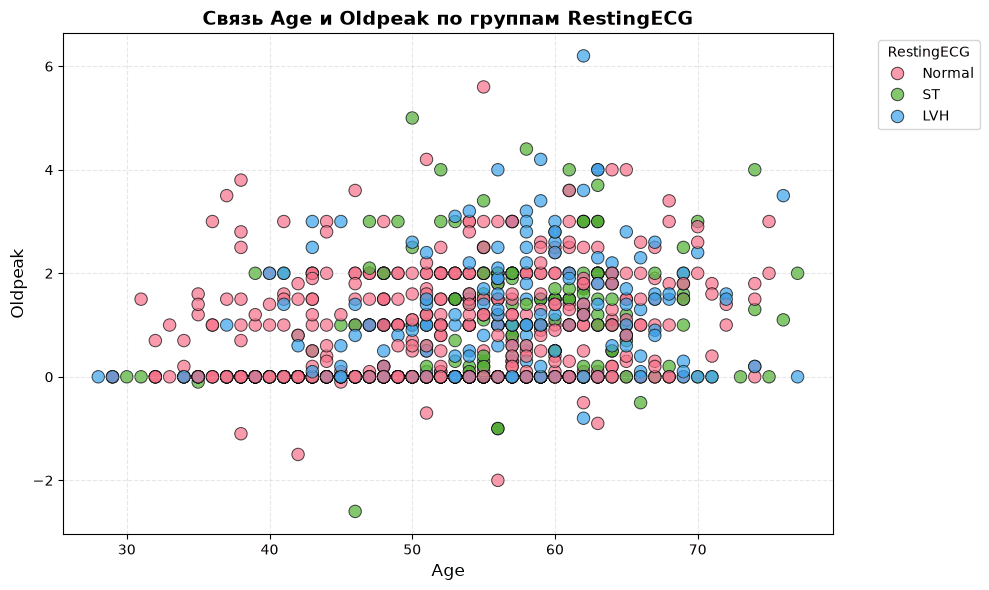

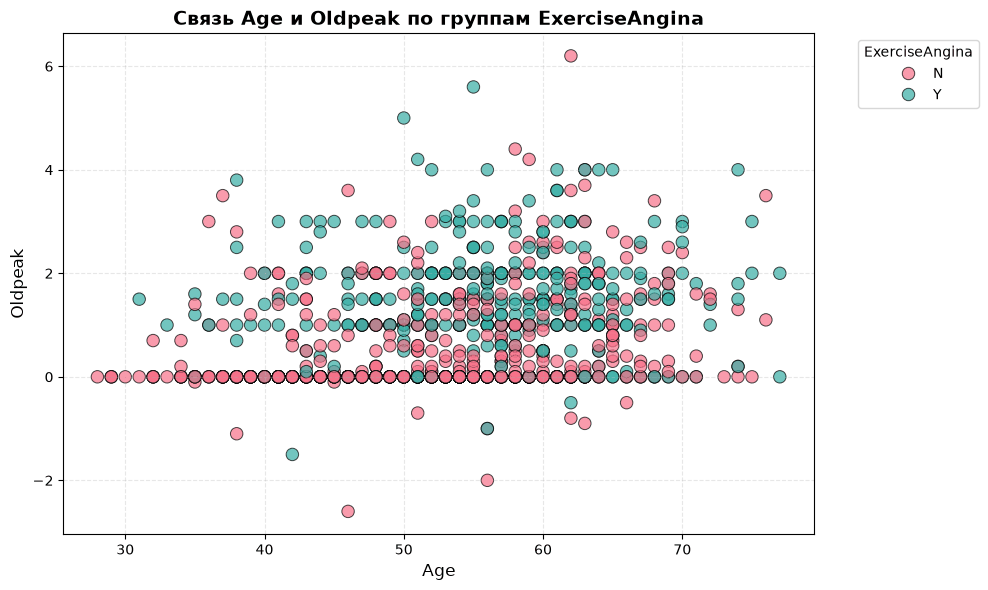

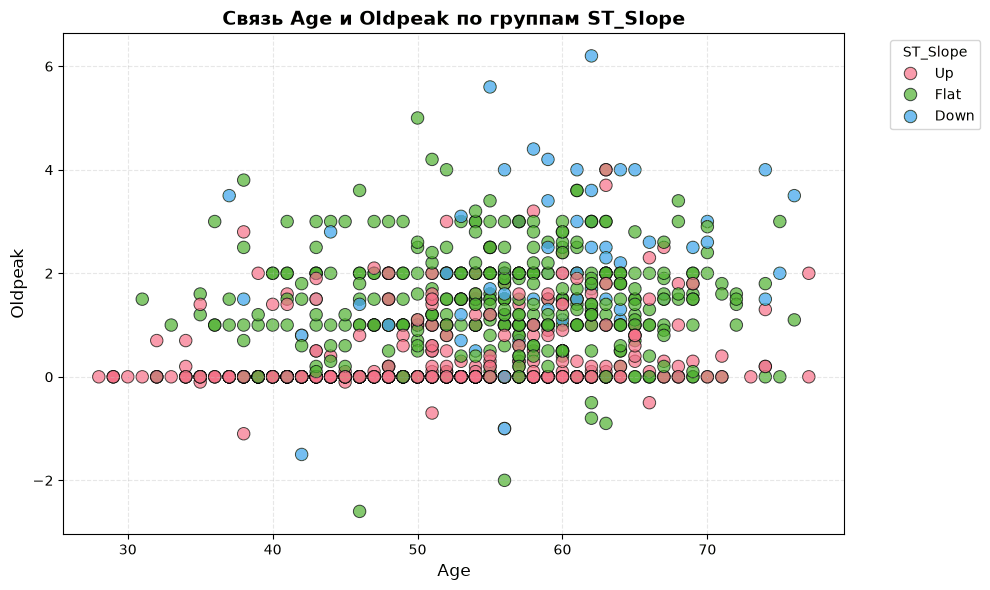

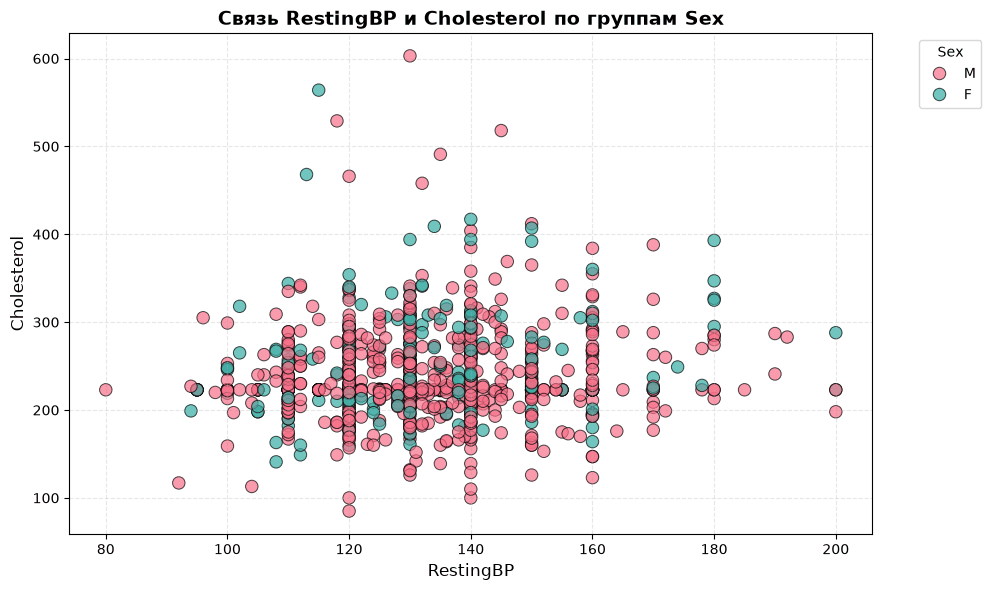

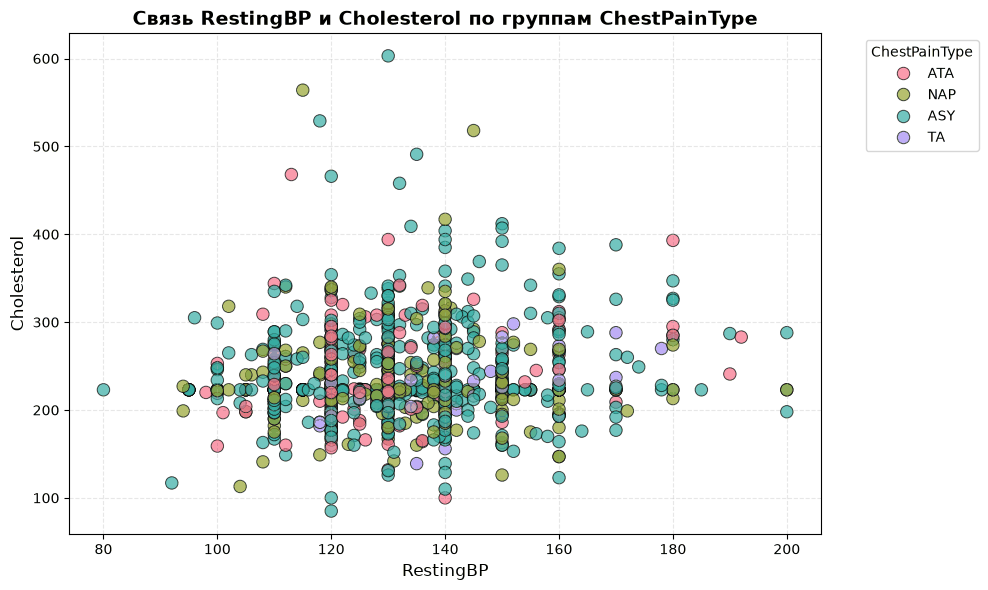

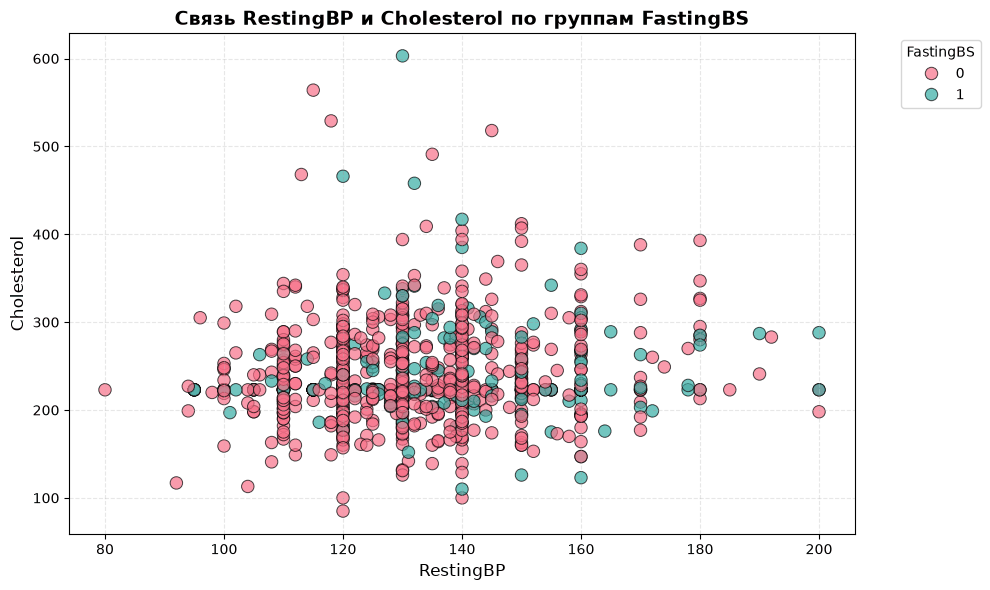

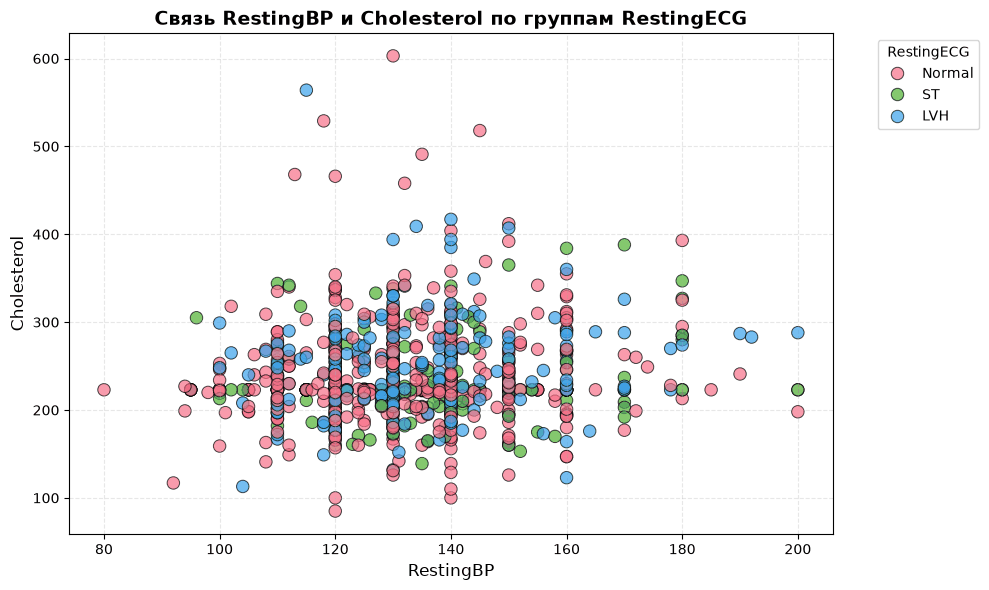

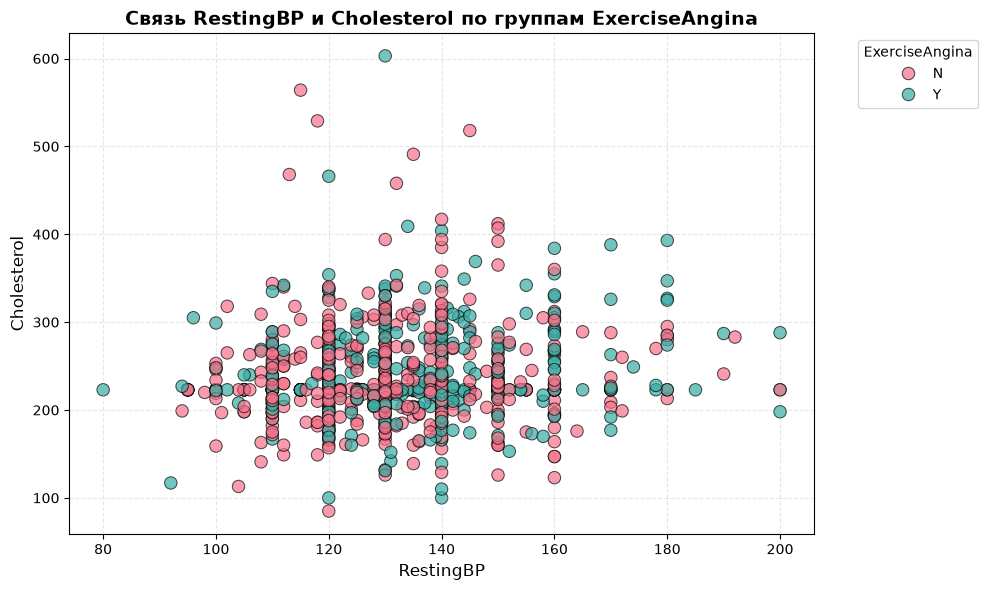

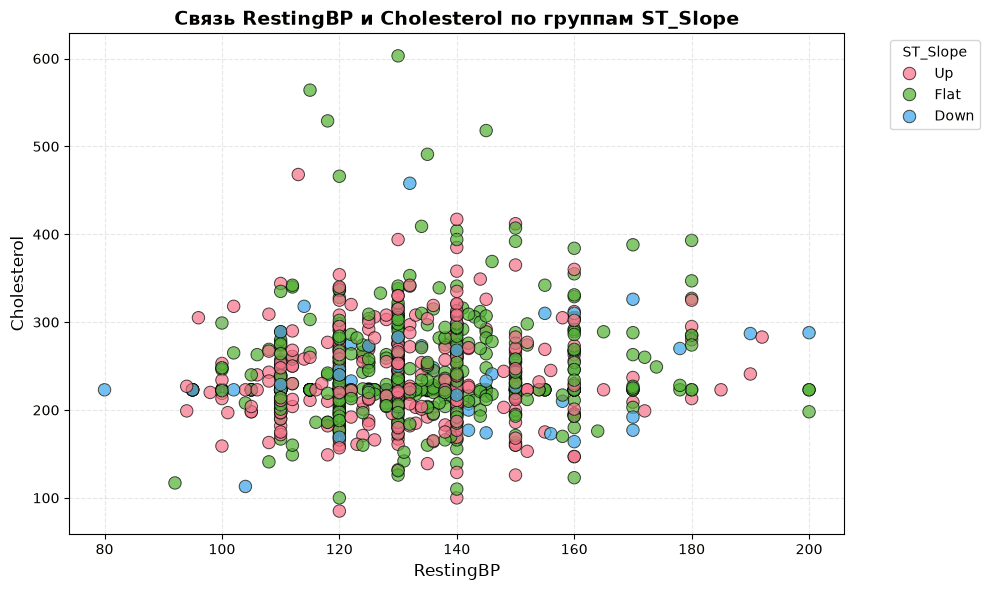

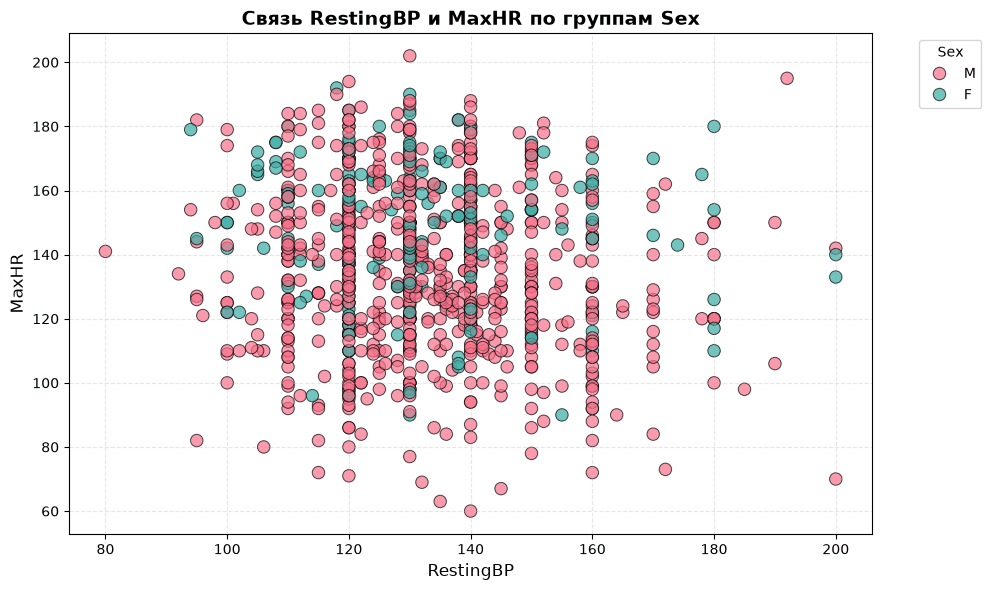

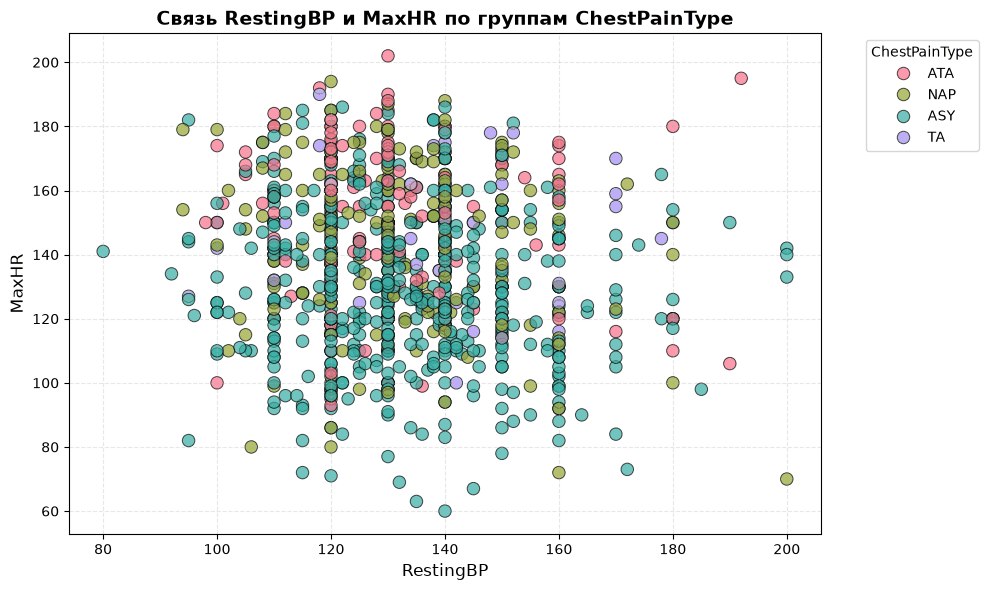

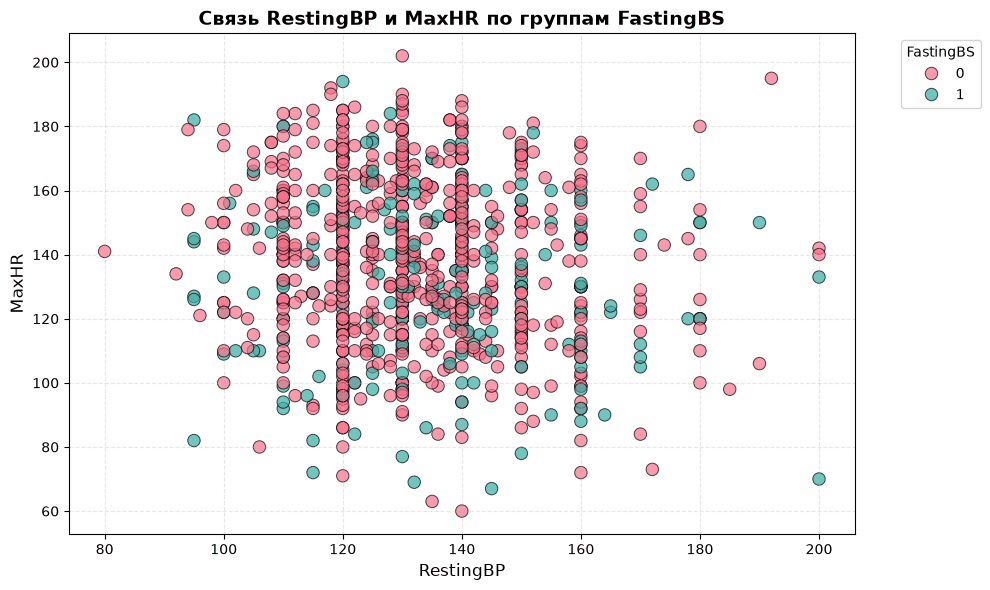

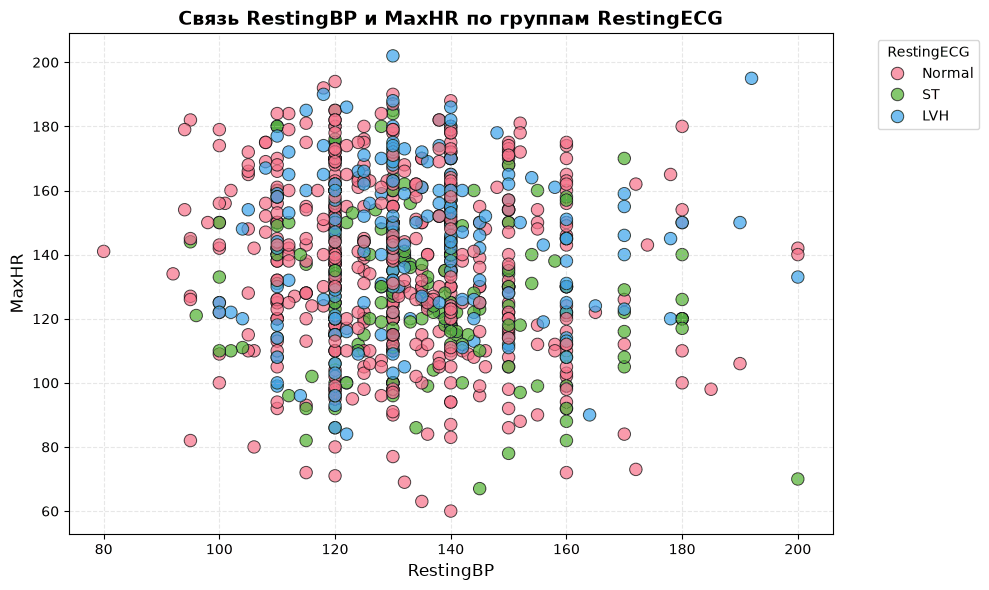

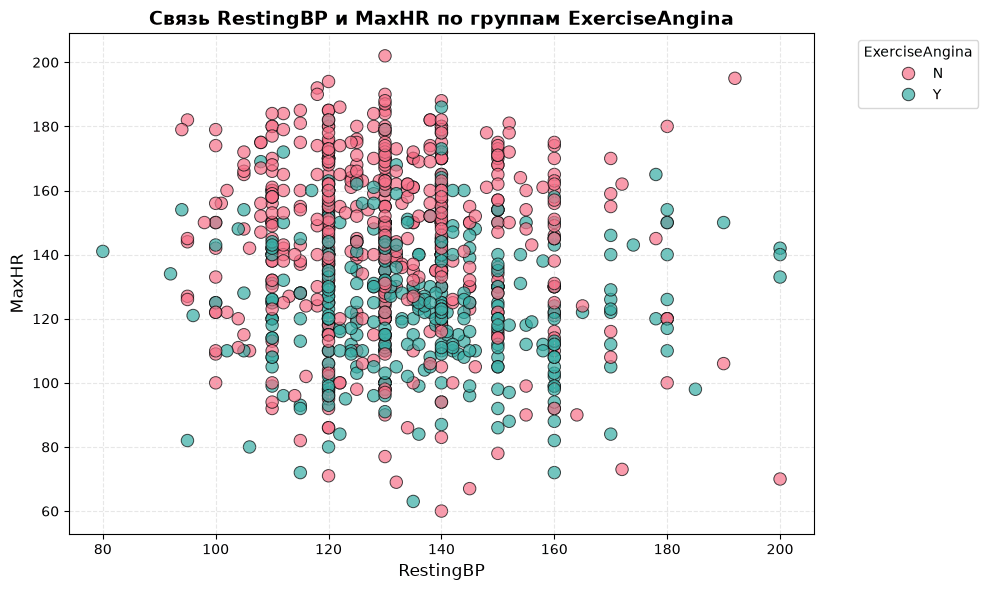

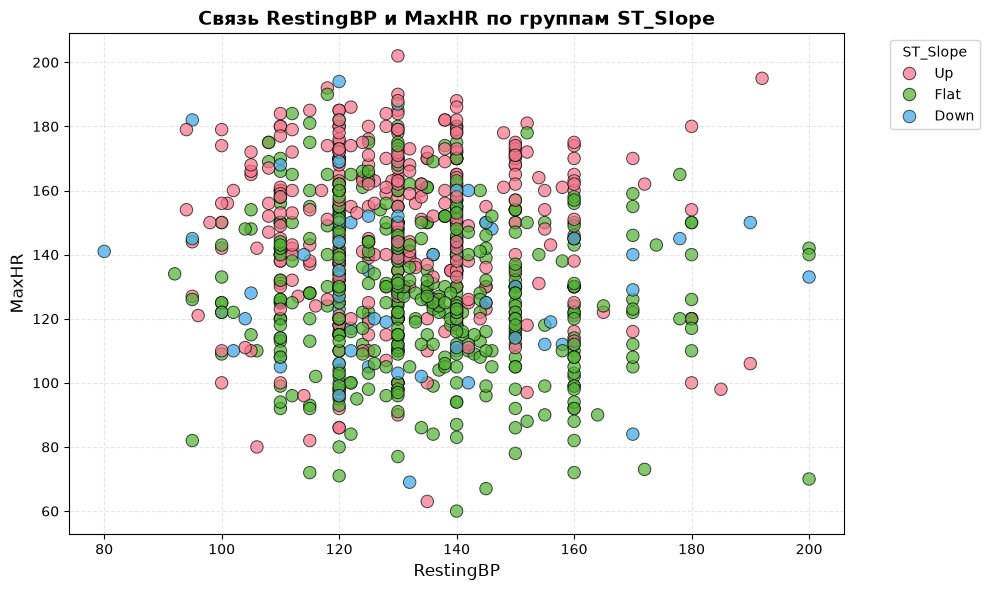

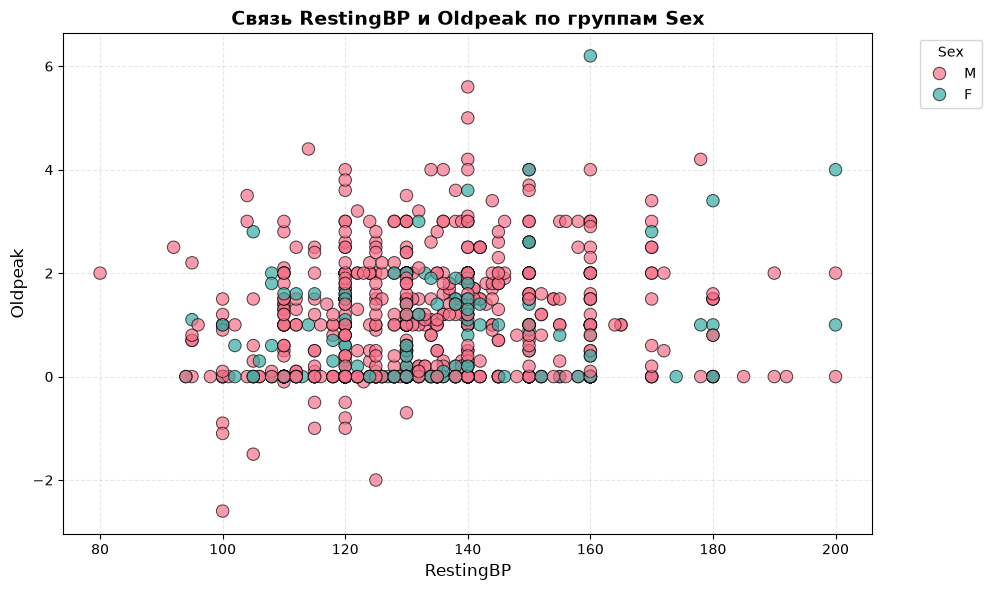

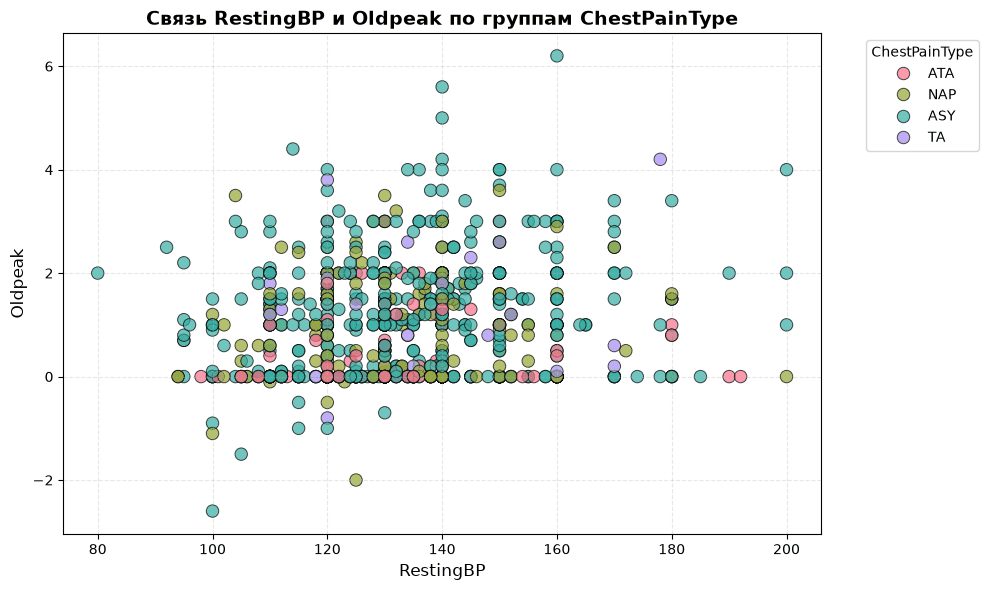

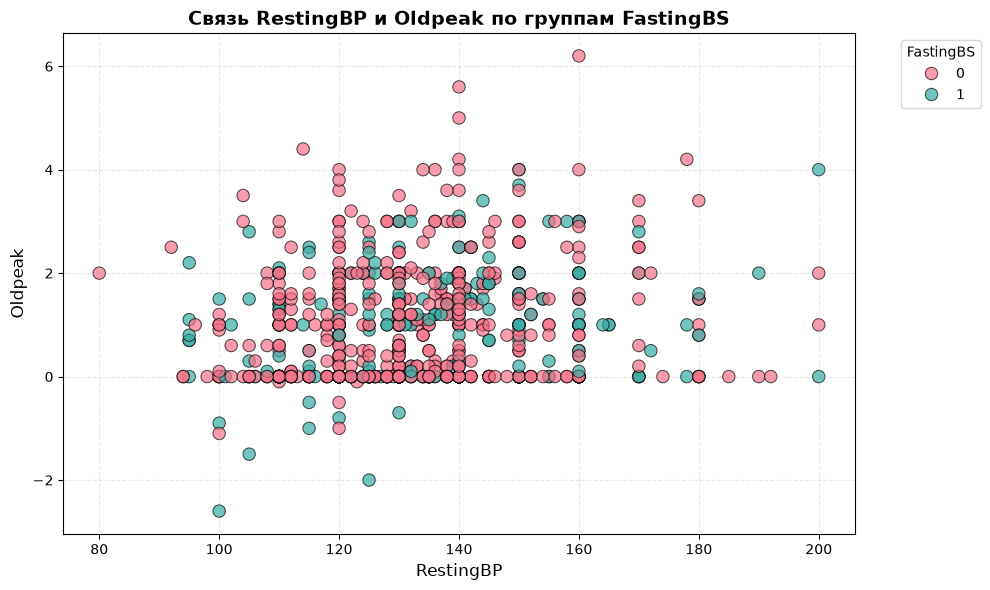

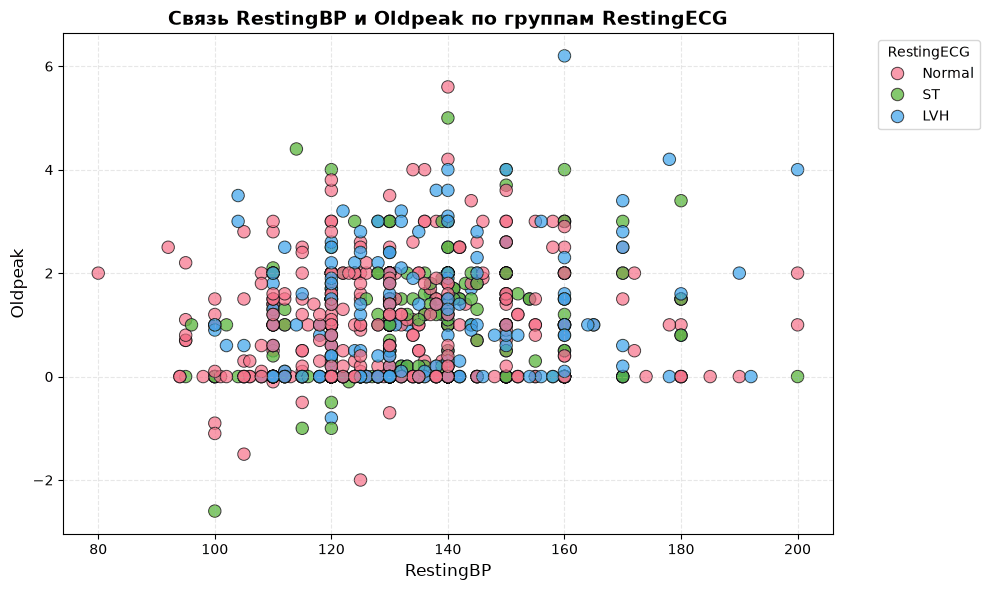

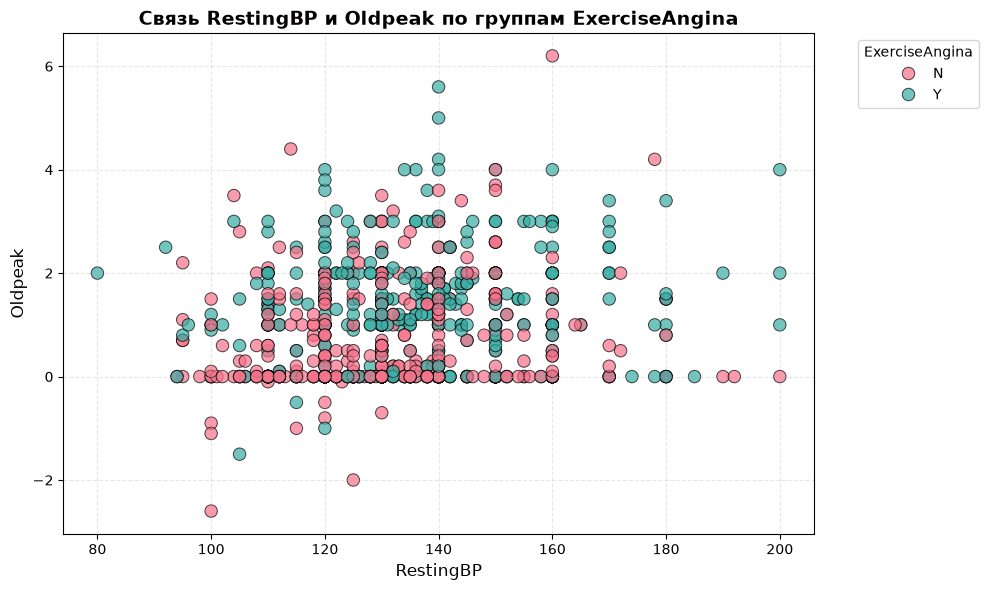

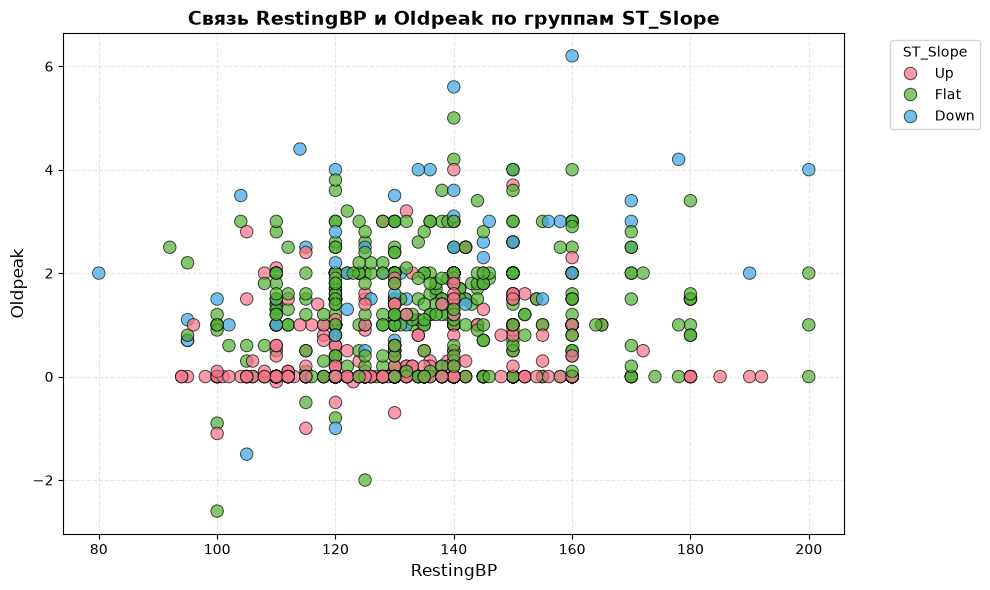

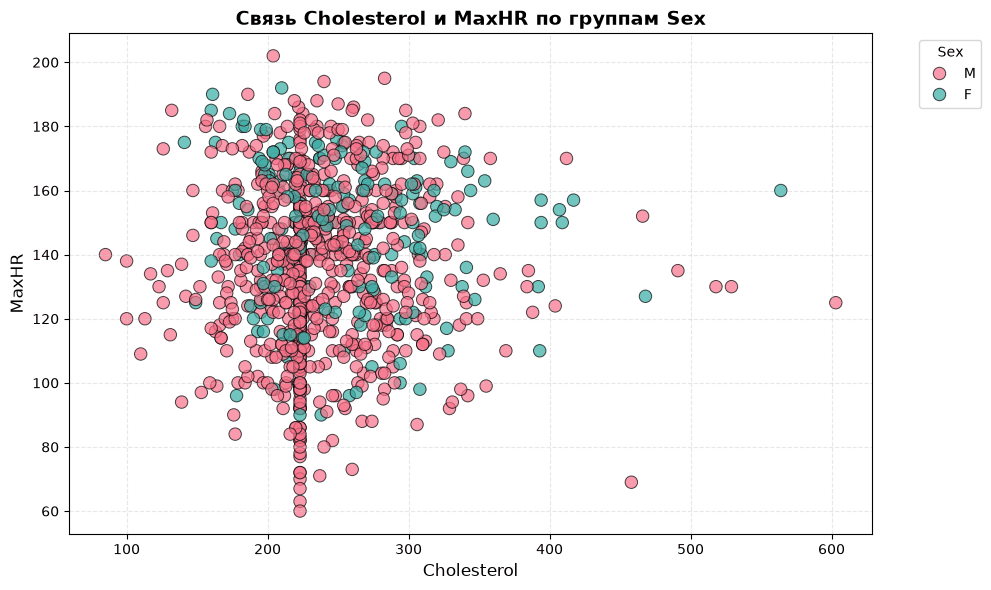

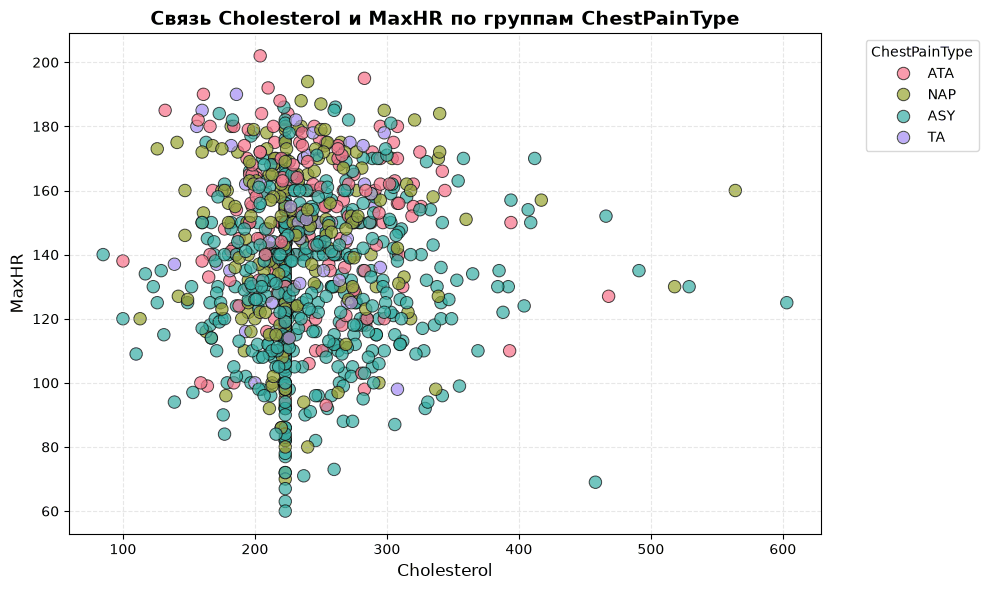

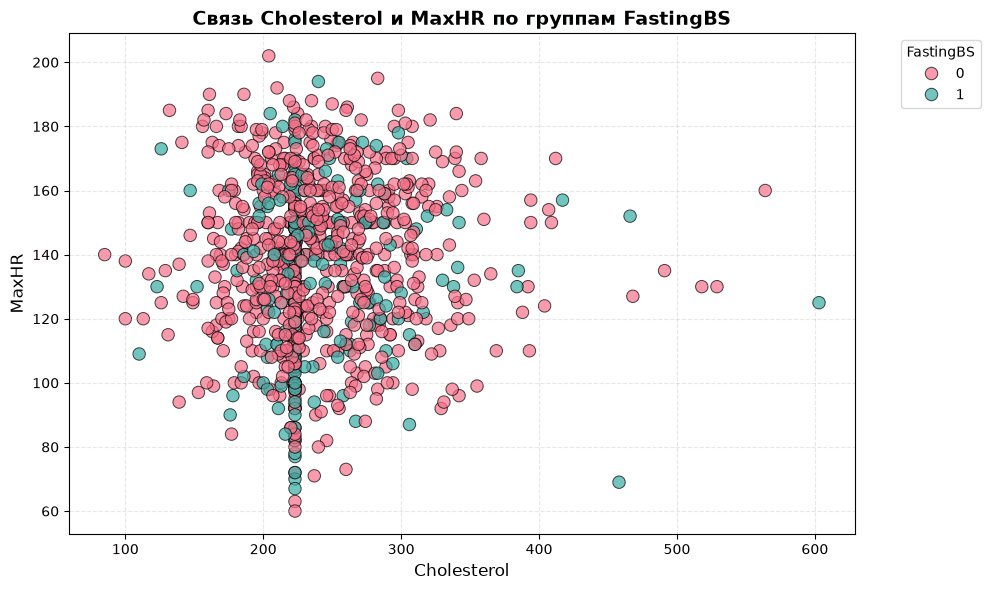

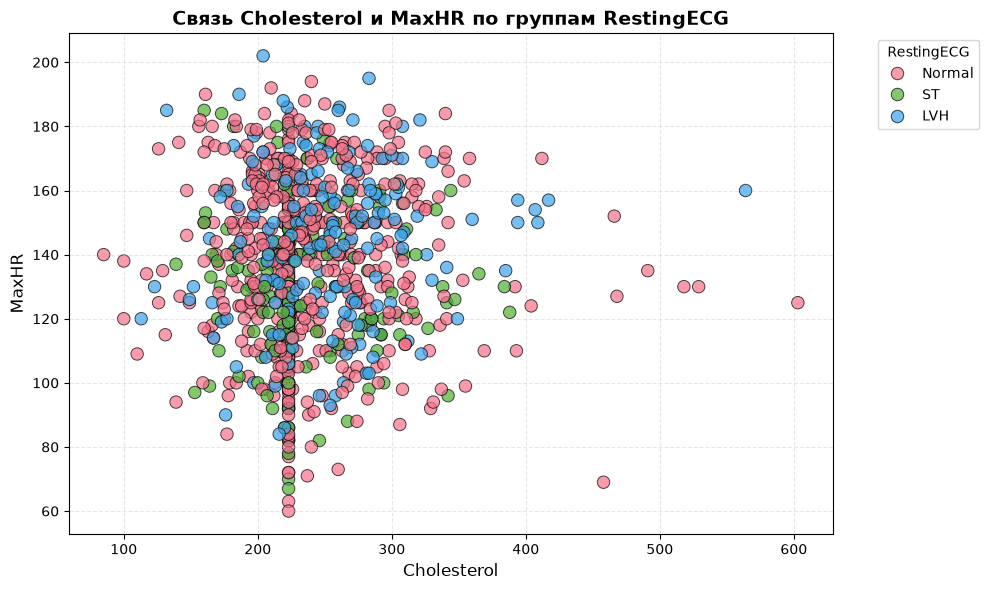

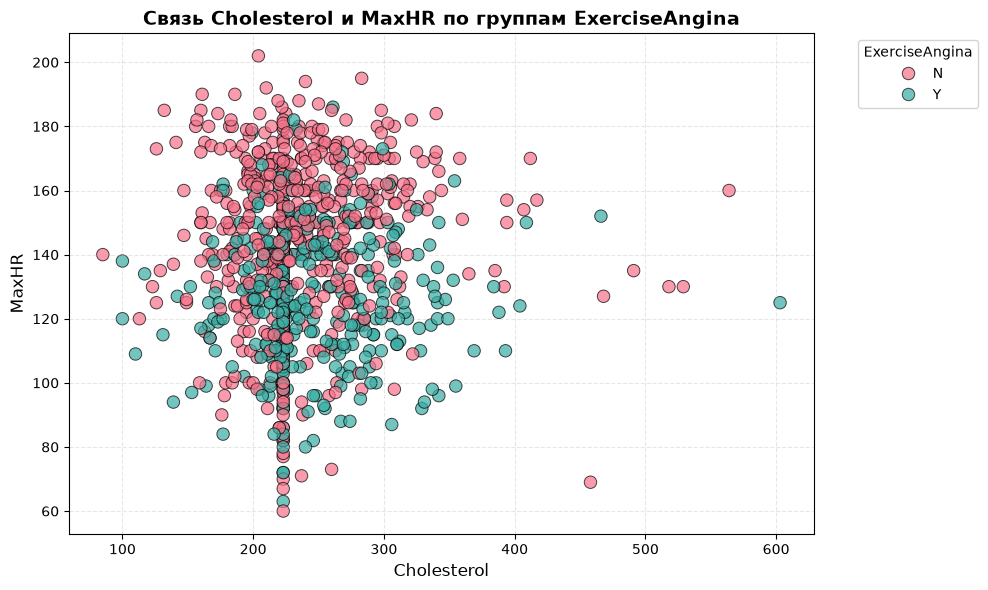

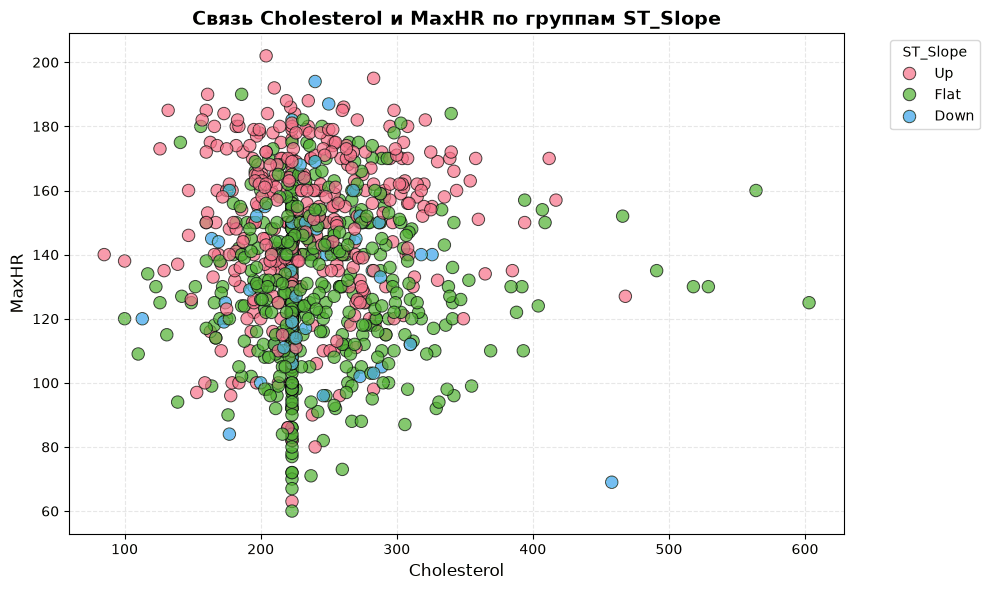

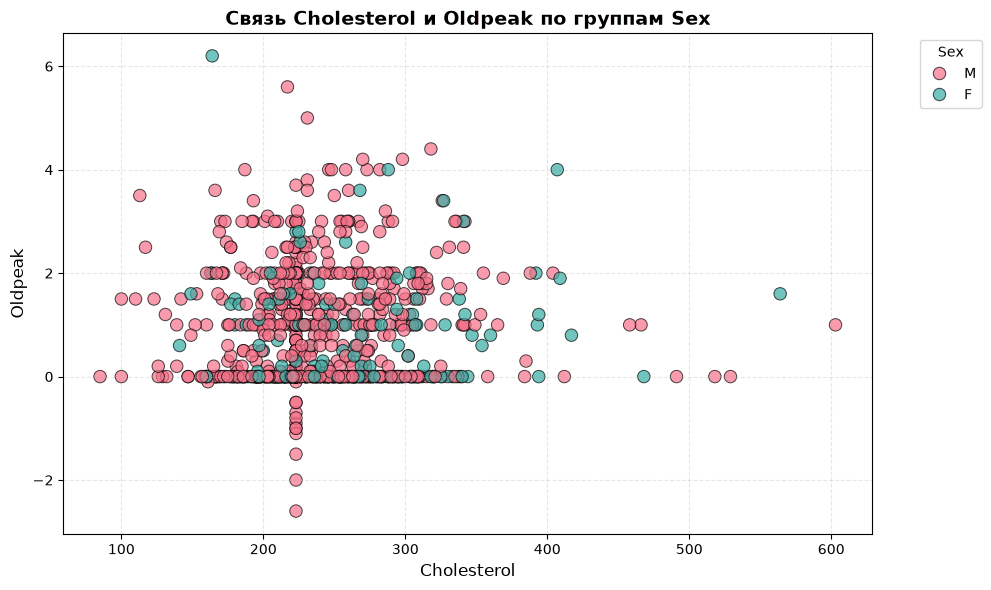

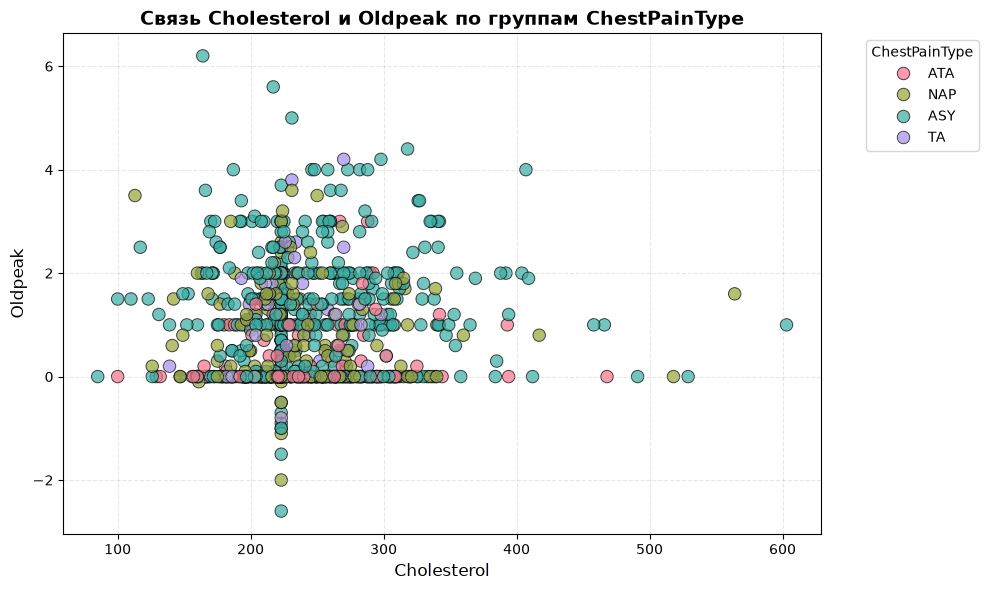

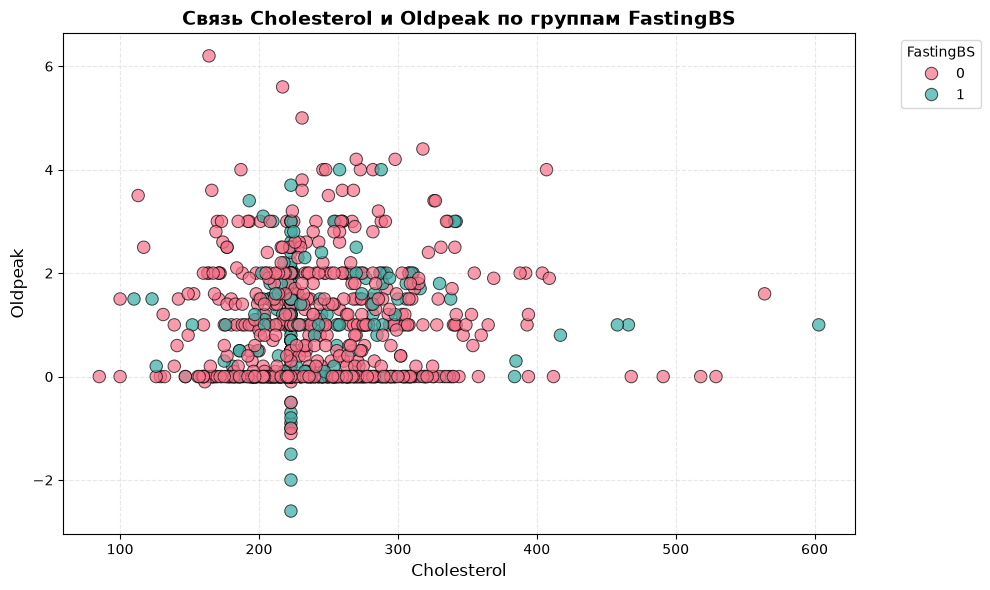

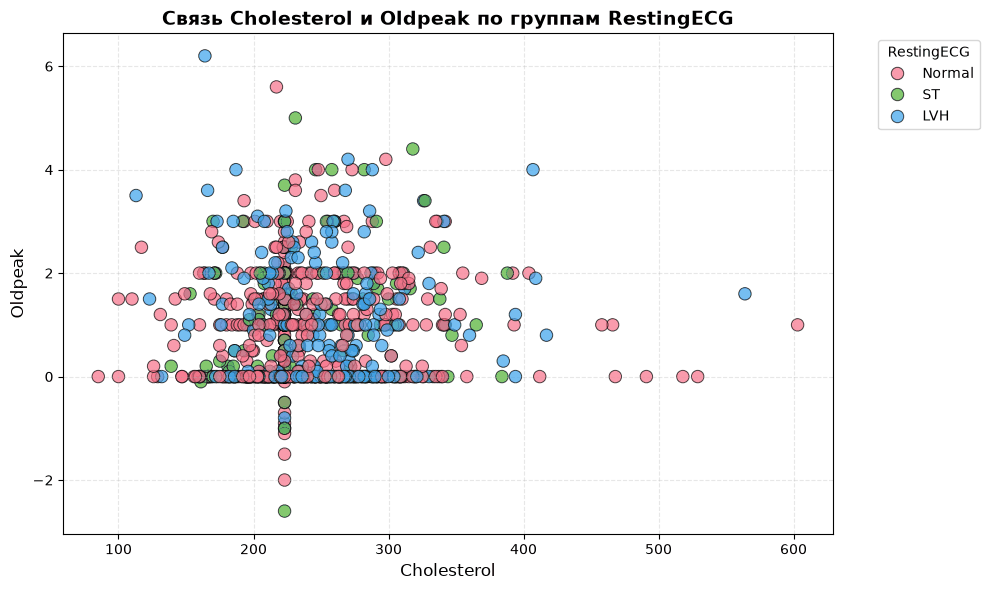

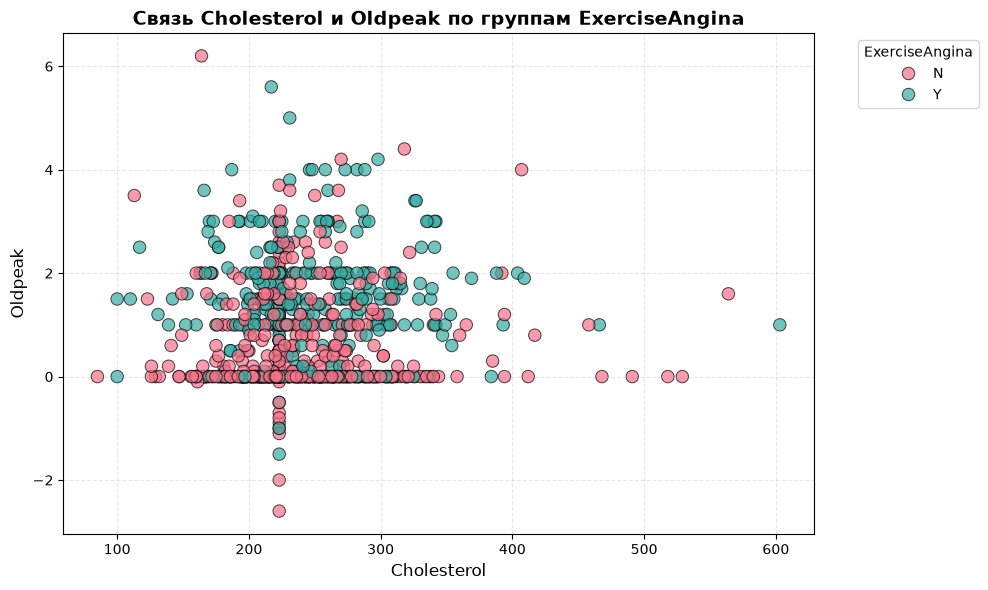

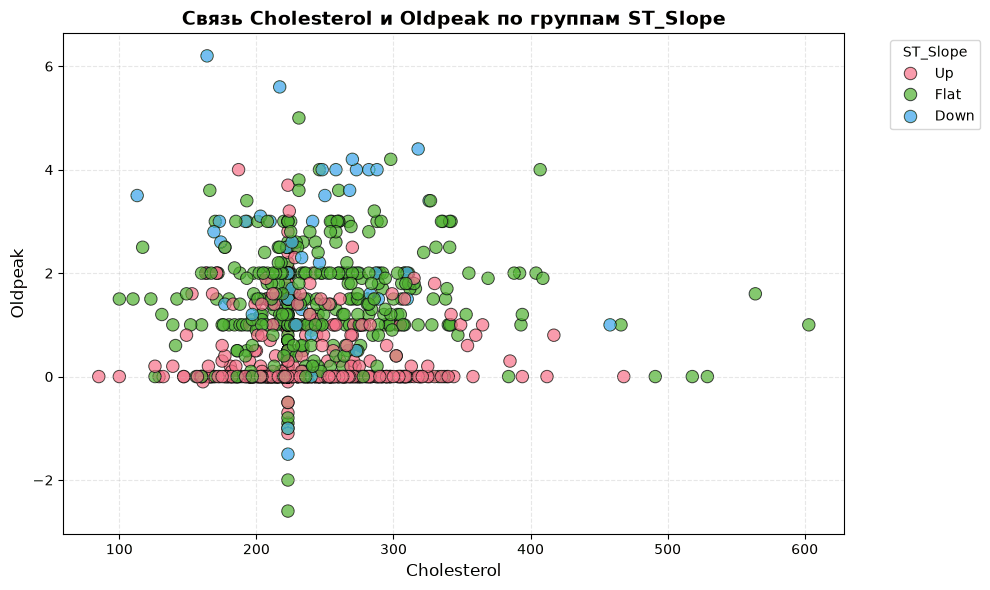

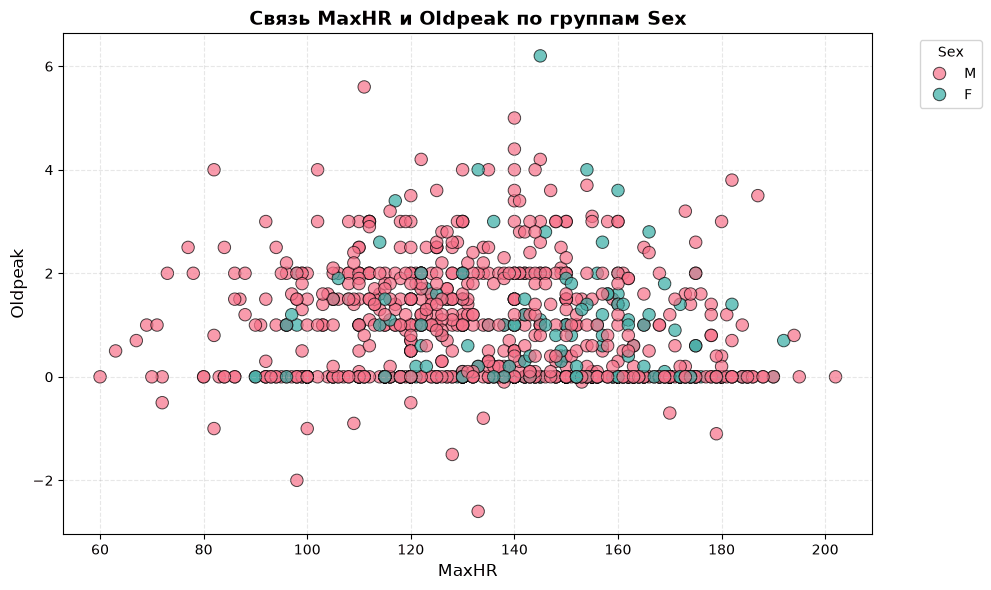

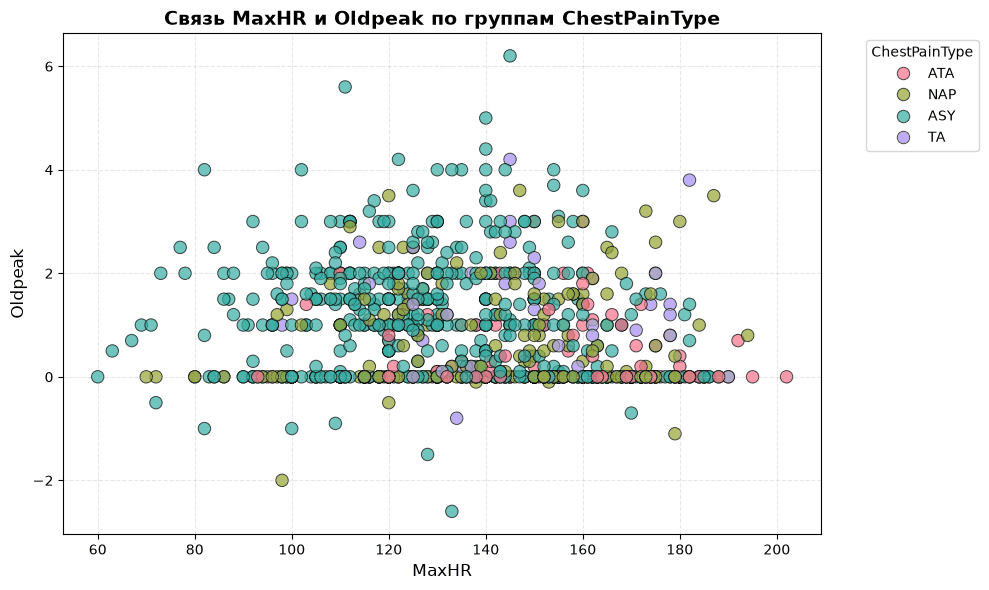

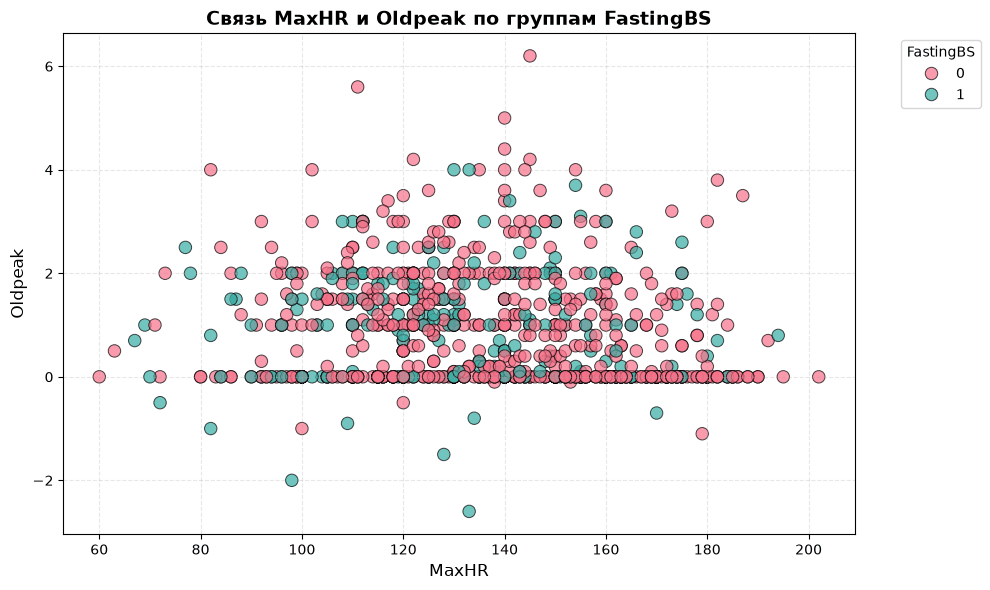

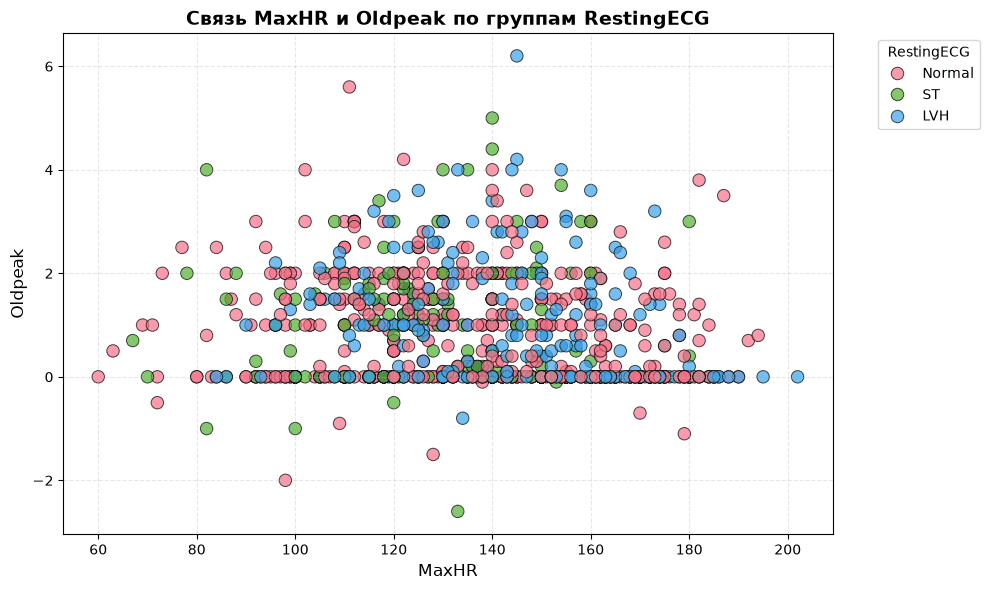

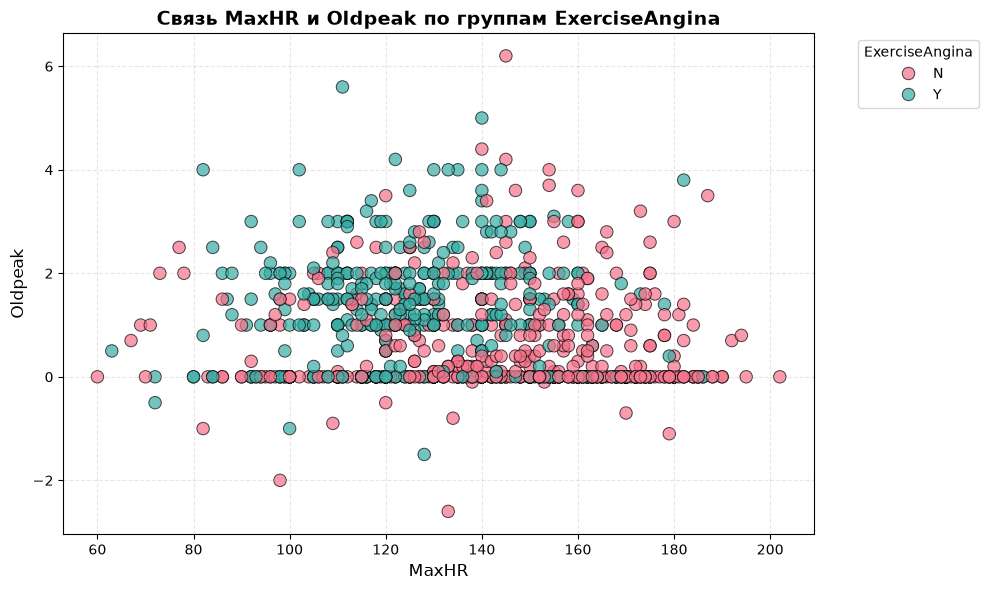

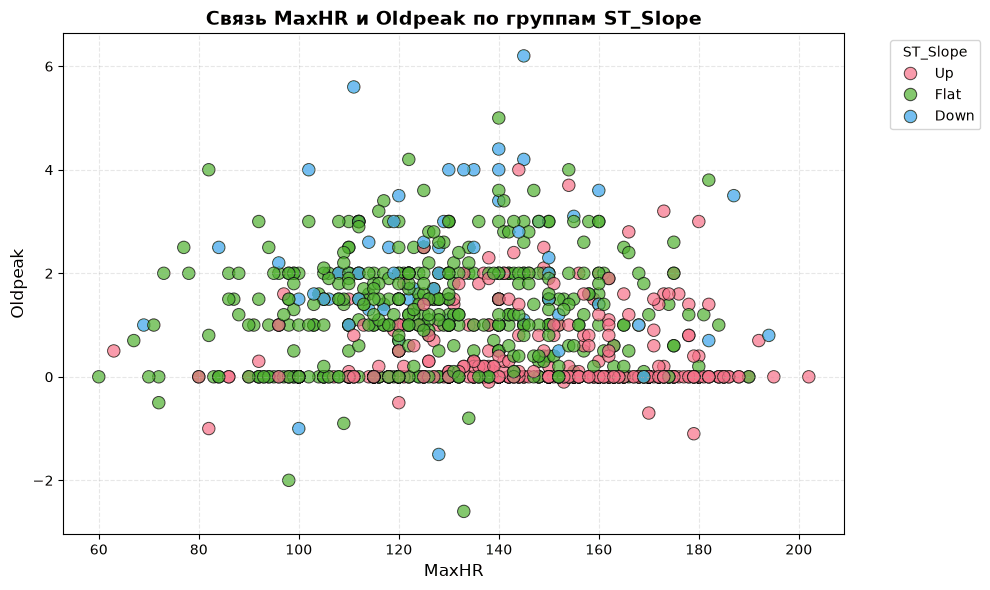

In [33]:
for i in range(len(numerical_cols)):
    num_x = numerical_cols[i]
    for j in range(i + 1, len(numerical_cols)):
        num_y = numerical_cols[j]
        for cat_col in categorical_cols:
            analyze_num_num_by_cat(df, num_x, num_y, cat_col)

Небольшие различия заметны в разных группировках, однако эти графики не дают нам каких-то новых значимых инсайтов.

#### Взаимосвязи признаков с целевой переменной

In [34]:
target_col = 'HeartDisease'

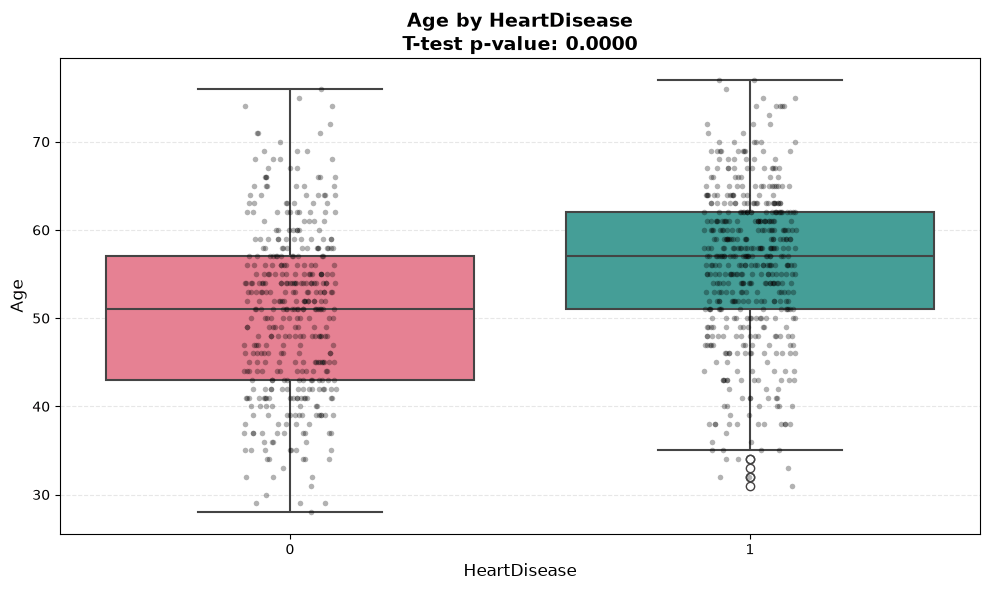

Анализ: Age vs HeartDisease
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


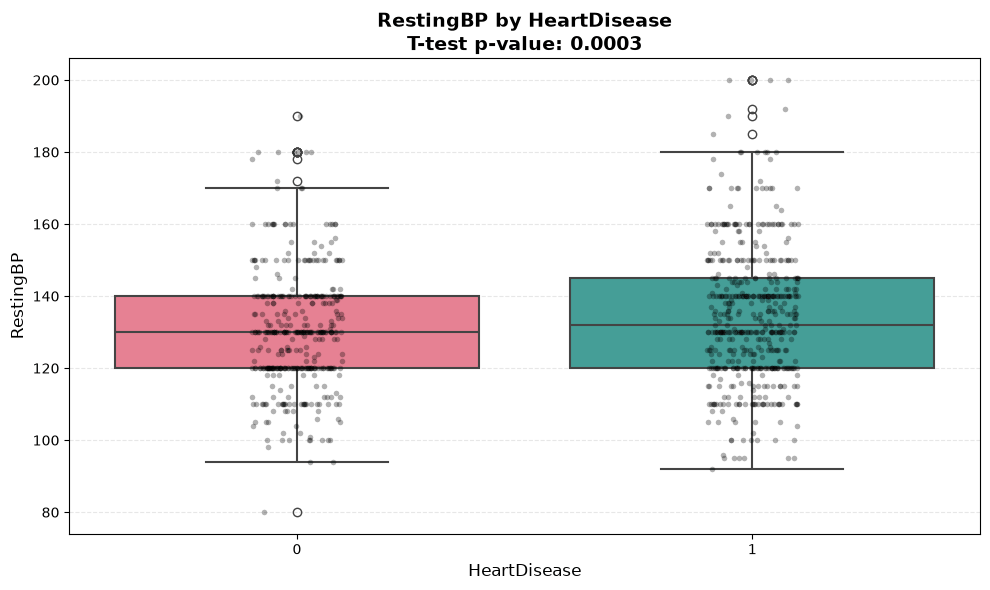

Анализ: RestingBP vs HeartDisease
• Тест: T-test
• P-value: 0.0003
Значимые различия между группами!


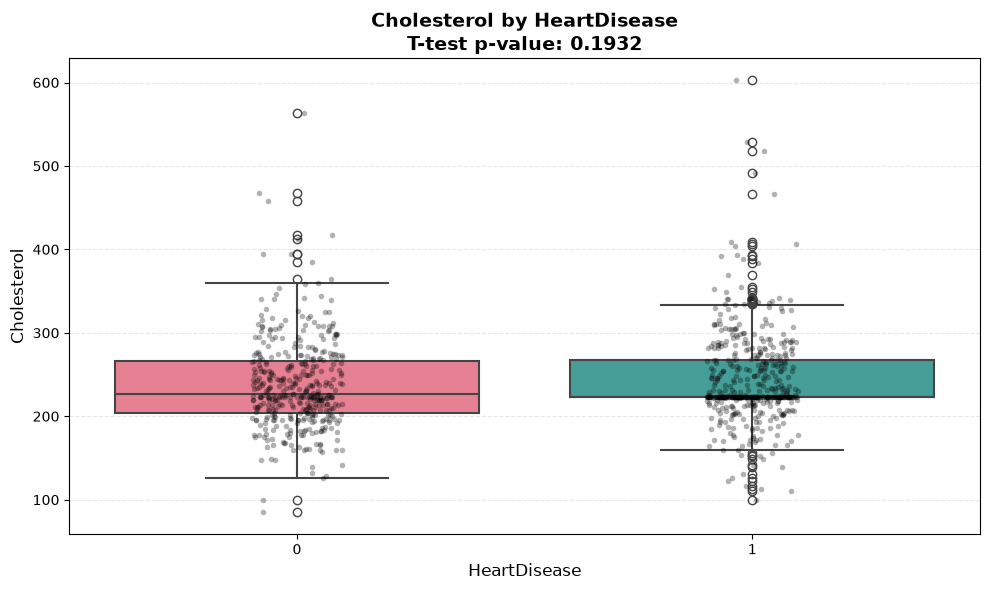

Анализ: Cholesterol vs HeartDisease
• Тест: T-test
• P-value: 0.1932
Различий не обнаружено.


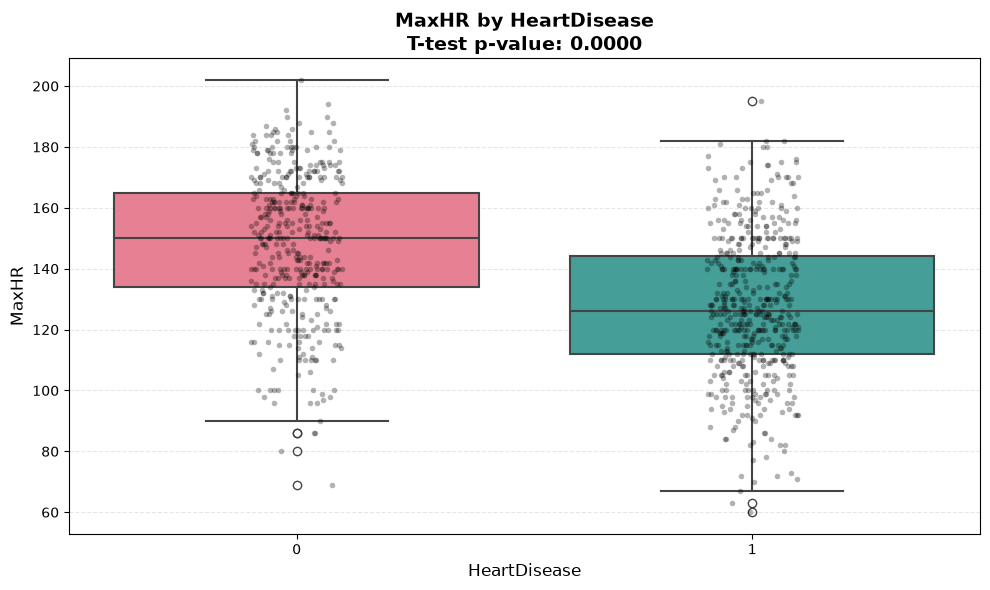

Анализ: MaxHR vs HeartDisease
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


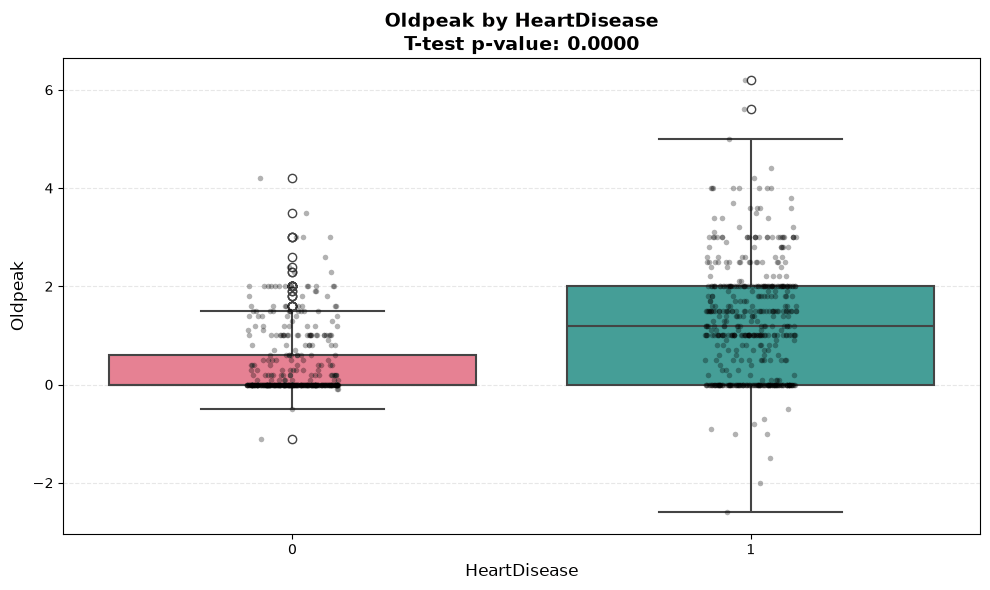

Анализ: Oldpeak vs HeartDisease
• Тест: T-test
• P-value: 0.0000
Значимые различия между группами!


In [35]:
for col in numerical_cols:
    analyze_num_cat(df=df, num_col=col, cat_col=target_col)

Все числовые признаки показали значимые различия между группами кроме `Cholesterol`.

<Figure size 1000x600 with 0 Axes>

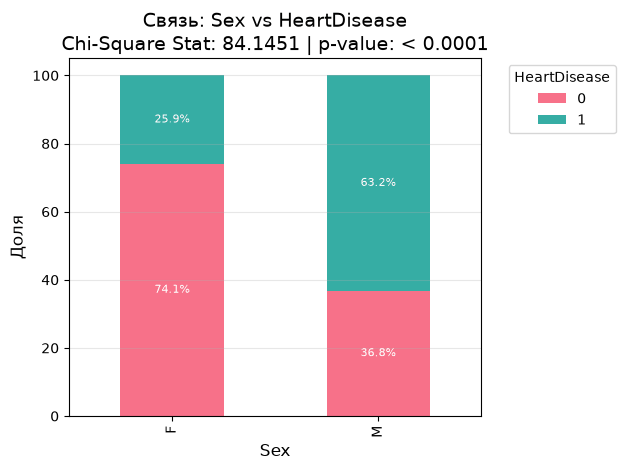

<Figure size 1000x600 with 0 Axes>

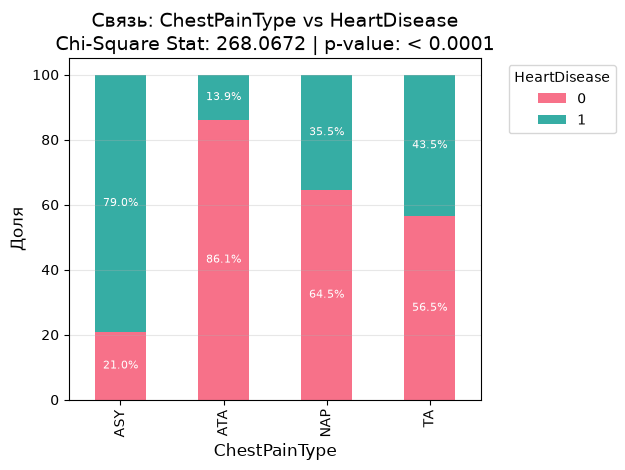

<Figure size 1000x600 with 0 Axes>

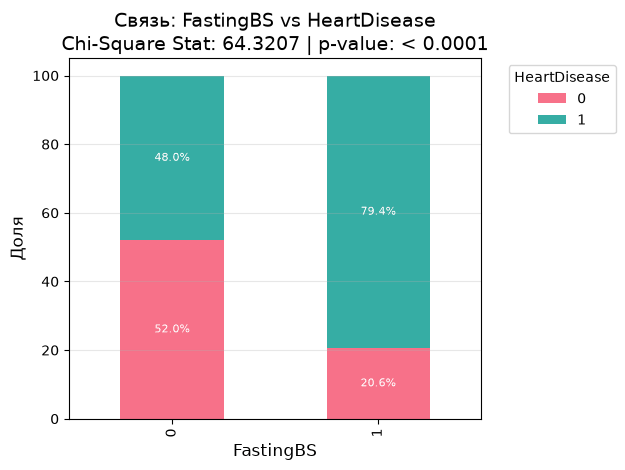

<Figure size 1000x600 with 0 Axes>

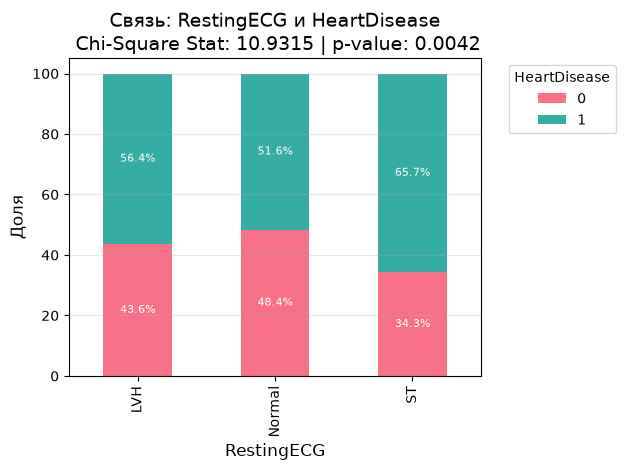

<Figure size 1000x600 with 0 Axes>

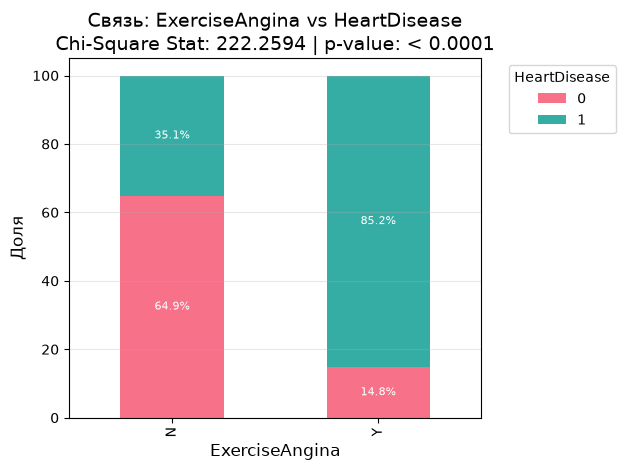

<Figure size 1000x600 with 0 Axes>

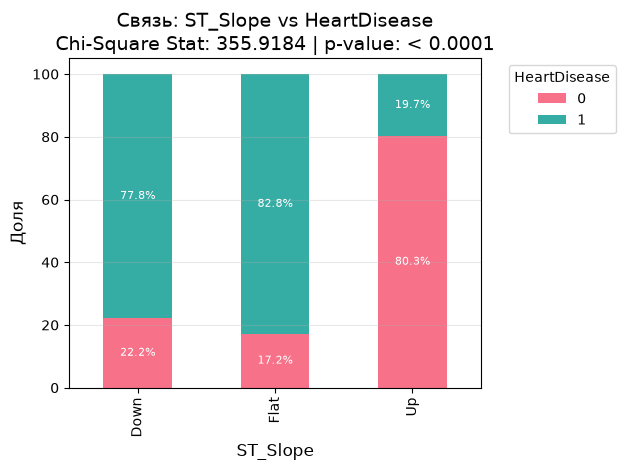

In [36]:
for col in categorical_cols:
    analyze_categorical_pair(df=df, col_1=col, col_2=target_col)

Все категориальные признаки демонстрируют значимую разницу между группами, но ЭКГ в покое показывает наименьшую значимость.

### Корреляции

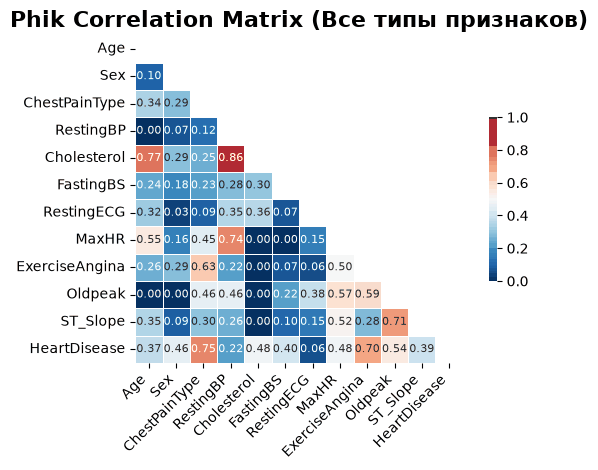

In [37]:
phik_matrix = df.phik_matrix(interval_cols=[])
significance_matrix = df.significance_matrix(interval_cols=[])

mask = np.triu(np.ones_like(phik_matrix, dtype=bool))

sns.heatmap(
    phik_matrix, 
    mask=mask, 
    annot=True,          
    fmt='.2f',           
    cmap='RdBu_r',      
    vmin=0, vmax=1,      
    center=0.5,
    square=True,         
    linewidths=.5,       
    cbar_kws={"shrink": .5}, 
    annot_kws={"size": 8}   
)

plt.title('Phik Correlation Matrix (Все типы признаков)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

- `ChestPainType` - 0.75  
- `Oldpeak`- 0.70
- `ST_Slope` - 0.54
- `ExerciseAngina` - 0.48  
- `Sex` - 0.46
- `MaxHR` - 0.40 
- `Age` - 0.37

С целевой переменной все признаки имеют значимые корреляции. А те, что перечислены выше, имеют особенно сильные.

Есть заметная мультиколлинеарность у холестерина, для моделей чувствительных к мультиколлинеарности возможно следует исключить этот признак.

## Подготовка к обучению

In [38]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 734, Test size: 184


In [40]:
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
cat_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [41]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [42]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

In [43]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [44]:
models = {
    'LogReg': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=1.0)) # C - регуляризация
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE, verbose=-1))
    ])
}

In [45]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [46]:
scoring_metrics = {
    'roc_auc': 'roc_auc_ovr_weighted',
    'recall': 'recall',
    'f1': 'f1'
}

## Обучение моделей

In [47]:
results_cv = {}

print("🚀 Запуск кросс-валидации для 5 моделей...")
print("-" * 80)

for name, pipeline in models.items():
    print(f"\n Модель: {name}")
    model_scores = {}
    
    for metric_name, scorer in scoring_metrics.items():
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv_strategy, scoring=scorer)
        
        mean_score = scores.mean()
        std_score = scores.std()
        
        model_scores[metric_name] = mean_score
        print(f"   {metric_name.upper():<10}: {mean_score:.4f} (+/- {std_score:.4f})")
        
    results_cv[name] = model_scores

🚀 Запуск кросс-валидации для 5 моделей...
--------------------------------------------------------------------------------

 Модель: LogReg
   ROC_AUC   : 0.9187 (+/- 0.0147)
   RECALL    : 0.8918 (+/- 0.0481)


   F1        : 0.8772 (+/- 0.0230)



 Модель: RandomForest


   ROC_AUC   : 0.9279 (+/- 0.0132)


   RECALL    : 0.9188 (+/- 0.0226)


   F1        : 0.8892 (+/- 0.0104)

 Модель: XGBoost


   ROC_AUC   : 0.9217 (+/- 0.0140)
   RECALL    : 0.9016 (+/- 0.0252)


   F1        : 0.8852 (+/- 0.0107)

 Модель: LightGBM
   ROC_AUC   : 0.9218 (+/- 0.0109)


   RECALL    : 0.8819 (+/- 0.0387)
   F1        : 0.8741 (+/- 0.0174)


## Выбор лучшей модели


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (Сортировка по ROC AUC)
              roc_auc  recall   f1
RandomForest     0.93    0.92 0.89
LightGBM         0.92    0.88 0.87
XGBoost          0.92    0.90 0.89
LogReg           0.92    0.89 0.88


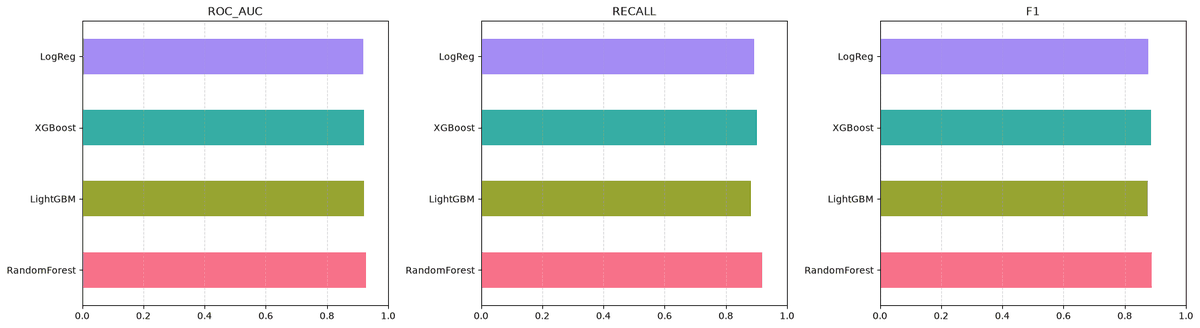

In [48]:
df_results = pd.DataFrame(results_cv).T
df_results = df_results.sort_values(by='roc_auc', ascending=False)

print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (Сортировка по ROC AUC)")
print("=" * 80)
print(df_results.round(4))
print("=" * 80)

# Визуализация результатов (опционально, но очень полезно)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['roc_auc', 'recall', 'f1']
colors = sns.color_palette("husl", len(df_results))

for i, metric in enumerate(metrics_to_plot):
    df_results[metric].plot(kind='barh', ax=ax[i], color=colors, title=f'{metric.upper()}')
    ax[i].set_xlim(0, 1)
    ax[i].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C небольшим отрывом лучшей моделью становится RandomForest

### Выгрузка модели

In [49]:
best_model_name = df_results.index[0]
print(f"Лучшая модель: {best_model_name}")

best_pipeline = models[best_model_name]

Лучшая модель: RandomForest


In [50]:
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``,

In [51]:
os.makedirs("models", exist_ok=True)

In [52]:
model_path = f"models/{best_model_name}_pipeline.pkl"
joblib.dump(best_pipeline, model_path)

print(f"Модель сохранена: {model_path}")

Модель сохранена: models/RandomForest_pipeline.pkl


## Проверка на тесте

Кросс-валидация выше проводилась только на `X_train`. Проверим выбранную модель на отложенной тестовой выборке `X_test`/`y_test`, которую модель не видела ни на одном этапе обучения или подбора.

In [53]:
y_pred_test = best_pipeline.predict(X_test)
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]

test_roc_auc = roc_auc_score(y_test, y_proba_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"ROC-AUC (тест): {test_roc_auc:.4f}")
print(f"Recall (тест):  {test_recall:.4f}")
print(f"F1 (тест):      {test_f1:.4f}")
print()
print(classification_report(y_test, y_pred_test))

ROC-AUC (тест): 0.9240
Recall (тест):  0.9118
F1 (тест):      0.8774

              precision    recall  f1-score   support

           0       0.88      0.79      0.83        82
           1       0.85      0.91      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



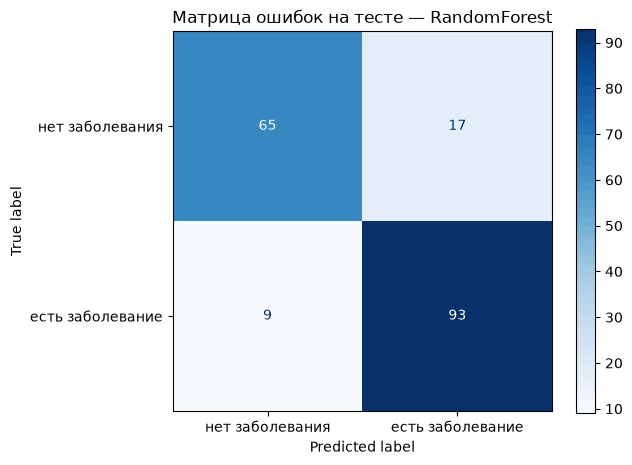

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['нет заболевания', 'есть заболевание'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Матрица ошибок на тесте — {best_model_name}')
plt.tight_layout()
plt.show()

## Результаты

Сравнивались четыре модели пятифолдовой кросс-валидацией на обучающей выборке (`X_train`, 734 наблюдения):

| Модель | ROC-AUC (CV) | Recall (CV) | F1 (CV) |
|---|---|---|---|
| **RandomForest** | **0.928** | **0.919** | **0.889** |
| XGBoost | 0.922 | 0.902 | 0.885 |
| LightGBM | 0.922 | 0.882 | 0.874 |
| LogReg | 0.919 | 0.892 | 0.877 |

Лучшая модель — **RandomForest**, с небольшим отрывом от градиентных бустингов. Recall для этой задачи важен отдельно: пропустить пациента с реальным заболеванием (ложноотрицательный результат) обходится дороже, чем направить здорового человека на дополнительную проверку.

**Проверка на отложенном тесте** (184 наблюдения, модель их не видела ни на обучении, ни при выборе модели):

| Метрика | CV (train) | Тест |
|---|---|---|
| ROC-AUC | 0.928 | **0.924** |
| Recall | 0.919 | **0.912** |
| F1 | 0.889 | **0.877** |

Тестовые метрики почти не отличаются от кросс-валидационных — модель не переобучилась под train, а качество, полученное на кросс-валидации, воспроизводится на новых данных. По матрице ошибок: из 102 пациентов с заболеванием модель находит 93 (recall 0.91), из 82 здоровых — верно распознаёт 65 (specificity ≈0.79). Модель заметно консервативнее в сторону «лучше перепроверить», чем «лучше пропустить» — что и требуется для задачи скрининга.

Корреляционный анализ (Phik) показал, что сильнее всего с целевым признаком связаны `ChestPainType` (0.75), `Oldpeak` (0.70), `ST_Slope` (0.54), `ExerciseAngina` (0.48) и `Sex` (0.46) — это совпадает с клинической интуицией: тип боли в груди, реакция ST-сегмента на нагрузку и переносимость физической нагрузки — как раз то, на что ориентируются при первичной оценке риска.

Обученный пайплайн (`preprocessing + RandomForestClassifier`) сохранён в `models/RandomForest_pipeline.pkl` и используется API-сервисом (`api/app.py`) — то есть результат этого ноутбука не отчёт сам по себе, а рабочий артефакт для следующего слоя демо-модуля.

**Что стоит доработать дальше:**
- `Cholesterol` содержал 172 неявных пропуска (записаны как 0) и был заполнен медианой — это создало заметный искусственный пик в распределении признака (виден на графике распределения выше) и, по корреляционному анализу, признак оказался единственным числовым без значимой связи с целевой переменной. Более аккуратная стратегия импутации (например, по группам `Sex`/`ChestPainType`) — кандидат на доработку.
- Единицы измерения (`Cholesterol`, глюкоза) в датасете — mg/dl, тогда как в РФ приняты ммоль/л; конвертация нужна на стороне API при реальном вводе данных врачом, в модели это пока не учтено.